In [1]:
# Cell 1: Audit subgroup labels across all grad rate raw files

import pandas as pd
from pathlib import Path
import re

RAW_DIR = Path('../data/raw')

# Find all grad rate files (cohort files, distinct from assessment files)
grad_files = sorted([
    f for f in RAW_DIR.glob('*.xlsx')
    if 'cohort' in f.name.lower() or 'graduation' in f.name.lower()
])

print(f"Found {len(grad_files)} grad rate files:\n")
for f in grad_files:
    print(f"  {f.name}")

Found 6 grad rate files:

  4Y-GradRate-Cohort2024.xlsx
  4Y-GradRate-Cohort2025.xlsx
  4Year_Grad_Rate_Cohort2023_publish[1] (1).xlsx
  4Ygraduation_rate_cohort_2022_redacted.xlsx
  Cohort 2020 4 Year Graduation Rate Final.xlsx
  Cohort 2021 4 Year Graduation Rate.xlsx


In [2]:
# Search more broadly for grad rate files — different naming conventions across eras
all_xlsx = sorted([f for f in RAW_DIR.glob('*.xlsx')])

print(f"Total .xlsx files in data/raw/: {len(all_xlsx)}\n")
for f in all_xlsx:
    name_lower = f.name.lower()
    # Skip assessment files we already know about
    if 'assess' in name_lower:
        continue
    # Skip non-data files (NCES, alt schools)
    if 'nces' in name_lower or 'fy26' in name_lower:
        continue
    print(f"  {f.name}")

Total .xlsx files in data/raw/: 15

  4Y-GradRate-Cohort2024.xlsx
  4Y-GradRate-Cohort2025.xlsx
  4Year_Grad_Rate_Cohort2023_publish[1] (1).xlsx
  4Ygraduation_rate_cohort_2022_redacted.xlsx
  Cohort 2020 4 Year Graduation Rate Final.xlsx
  Cohort 2021 4 Year Graduation Rate.xlsx


In [3]:
# Search the entire repo for grad rate files
import subprocess
result = subprocess.run(
    ['find', '..', '-iname', '*cohort*', '-type', 'f'],
    capture_output=True, text=True
)
print("All cohort-related files anywhere in the repo:")
print(result.stdout)

result2 = subprocess.run(
    ['find', '..', '-iname', '*grad*', '-type', 'f'],
    capture_output=True, text=True
)
print("\nAll grad-related files anywhere in the repo:")
print(result2.stdout)

All cohort-related files anywhere in the repo:
../data/raw/Cohort 2010_4 Year Graduation Rate.xls
../data/raw/Cohort 2017_4 Year Graduation Rate.xls
../data/raw/Cohort 2016_4 Year Graduation Rate.xls
../data/raw/Cohort 2011_4 Year Graduation Rate.xls
../data/raw/4Ygraduation_rate_cohort_2022_redacted.xlsx
../data/raw/4Year_Grad_Rate_Cohort2023_publish[1] (1).xlsx
../data/raw/4Y-GradRate-Cohort2025.xlsx
../data/raw/Cohort 2014_4 Year Graduation Rate.xls
../data/raw/Cohort 2013_4 Year Graduation Rate.xls
../data/raw/4Y-GradRate-Cohort2024.xlsx
../data/raw/Cohort 2018 Four Year_Redacted.xls
../data/raw/Cohort 2021 4 Year Graduation Rate.xlsx
../data/raw/Cohort 2012_4 Year Graduation Rate.xls
../data/raw/Cohort 2020 4 Year Graduation Rate Final.xlsx
../data/raw/Cohort 2015_4 Year Graduation Rate.xls


All grad-related files anywhere in the repo:
../venv/lib/python3.11/site-packages/tzdata/zoneinfo/Europe/Belgrade
../venv/lib/python3.11/site-packages/tzdata/zoneinfo/Europe/Kaliningrad
../ve

In [4]:
# Updated search — catches both .xls and .xlsx, plus the unusual filename patterns
all_files = sorted([
    f for f in RAW_DIR.glob('*.xls*')
    if any(pat in f.name.lower() for pat in ['cohort', 'gradrate', 'graduation_rate', 'gradrate'])
])

print(f"Found {len(all_files)} grad rate files:\n")
for f in all_files:
    print(f"  {f.name}")

Found 16 grad rate files:

  20194YearGradRateFinal.xls
  4Y-GradRate-Cohort2024.xlsx
  4Y-GradRate-Cohort2025.xlsx
  4Year_Grad_Rate_Cohort2023_publish[1] (1).xlsx
  4Ygraduation_rate_cohort_2022_redacted.xlsx
  Cohort 2010_4 Year Graduation Rate.xls
  Cohort 2011_4 Year Graduation Rate.xls
  Cohort 2012_4 Year Graduation Rate.xls
  Cohort 2013_4 Year Graduation Rate.xls
  Cohort 2014_4 Year Graduation Rate.xls
  Cohort 2015_4 Year Graduation Rate.xls
  Cohort 2016_4 Year Graduation Rate.xls
  Cohort 2017_4 Year Graduation Rate.xls
  Cohort 2018 Four Year_Redacted.xls
  Cohort 2020 4 Year Graduation Rate Final.xlsx
  Cohort 2021 4 Year Graduation Rate.xlsx


In [6]:
def extract_cohort_year(filepath):
    """Pull cohort year from filename."""
    name = filepath.name
    # Match "Cohort 2010", "Cohort2010", "cohort2010"
    m = re.search(r'cohort\s*(\d{4})', name, re.IGNORECASE)
    if m: return int(m.group(1))
    # Match "20194YearGradRate" — 4-digit year at start
    m = re.search(r'^(\d{4})', name)
    if m: 
        year = int(m.group(1))
        if 2010 <= year <= 2030: return year
    # Match any 4-digit year in 2010-2025 range anywhere in filename
    for m in re.finditer(r'(\d{4})', name):
        year = int(m.group(1))
        if 2010 <= year <= 2025: return year
    return None

# Test the year extraction
print("Year extraction test:")
for f in all_files:
    year = extract_cohort_year(f)
    print(f"  {year}  <- {f.name}")

Year extraction test:
  2019  <- 20194YearGradRateFinal.xls
  2024  <- 4Y-GradRate-Cohort2024.xlsx
  2025  <- 4Y-GradRate-Cohort2025.xlsx
  2023  <- 4Year_Grad_Rate_Cohort2023_publish[1] (1).xlsx
  2022  <- 4Ygraduation_rate_cohort_2022_redacted.xlsx
  2010  <- Cohort 2010_4 Year Graduation Rate.xls
  2011  <- Cohort 2011_4 Year Graduation Rate.xls
  2012  <- Cohort 2012_4 Year Graduation Rate.xls
  2013  <- Cohort 2013_4 Year Graduation Rate.xls
  2014  <- Cohort 2014_4 Year Graduation Rate.xls
  2015  <- Cohort 2015_4 Year Graduation Rate.xls
  2016  <- Cohort 2016_4 Year Graduation Rate.xls
  2017  <- Cohort 2017_4 Year Graduation Rate.xls
  2018  <- Cohort 2018 Four Year_Redacted.xls
  2020  <- Cohort 2020 4 Year Graduation Rate Final.xlsx
  2021  <- Cohort 2021 4 Year Graduation Rate.xlsx


In [7]:
def find_subgroup_sheet(xl):
    sheets = xl.sheet_names
    for s in sheets:
        if 'subgroup' in s.lower():
            return s
    for fallback in ['LEA', 'District', 'School', 'State']:
        for s in sheets:
            if s.strip().lower() == fallback.lower():
                return s
    return None

print(f"{'Year':>6} | {'File':<60} | Subgroups Found")
print('-' * 130)

subgroups_by_year = {}

for f in all_files:
    year = extract_cohort_year(f)
    year_str = str(year) if year is not None else '????'
    
    try:
        xl = pd.ExcelFile(f)
        sheet = find_subgroup_sheet(xl)
        if not sheet:
            print(f"{year_str:>6} | {f.name[:60]:<60} | NO SUITABLE SHEET — sheets: {xl.sheet_names}")
            continue
        df = pd.read_excel(f, sheet_name=sheet, nrows=5000)
        sg_col = None
        for col in df.columns:
            if 'subgroup' in str(col).lower():
                sg_col = col
                break
        if sg_col:
            uniques = sorted(df[sg_col].dropna().unique().tolist())
            subgroups_by_year[year] = uniques
            print(f"{year_str:>6} | {f.name[:60]:<60} | {len(uniques)} subgroups in '{sheet}'")
        else:
            subgroups_by_year[year] = ['(no subgroup column)']
            print(f"{year_str:>6} | {f.name[:60]:<60} | NO SUBGROUP COLUMN in '{sheet}' — cols: {list(df.columns)[:6]}")
    except Exception as e:
        print(f"{year_str:>6} | {f.name[:60]:<60} | ERROR: {e}")

  Year | File                                                         | Subgroups Found
----------------------------------------------------------------------------------------------------------------------------------
  2019 | 20194YearGradRateFinal.xls                                   | 17 subgroups in 'School by Subgroup'
  2024 | 4Y-GradRate-Cohort2024.xlsx                                  | 18 subgroups in 'School by Subgroup'
  2025 | 4Y-GradRate-Cohort2025.xlsx                                  | 18 subgroups in 'School by Subgroup'
  2023 | 4Year_Grad_Rate_Cohort2023_publish[1] (1).xlsx               | 18 subgroups in 'School by Subgroup'
  2022 | 4Ygraduation_rate_cohort_2022_redacted.xlsx                  | 17 subgroups in 'School by Subgroup'
  2010 | Cohort 2010_4 Year Graduation Rate.xls                       | 13 subgroups in 'LEA'
  2011 | Cohort 2011_4 Year Graduation Rate.xls                       | 14 subgroups in 'LEA'
  2012 | Cohort 2012_4 Year Graduation Rate.xls 

In [9]:
SUBGROUP_MAP = {
    # Universal subgroups (all 16 years)
    'All': 'All',
    'White': 'White',
    'Female': 'Female',
    'Male': 'Male',
    'Asian': 'Asian',
    'Hispanic or Latino': 'Hispanic or Latino',
    'Multiple Races': 'Two or more Races',
    
    # Black / African American — all variants collapse
    'Black/African American': 'Black or African American',
    'African American': 'Black or African American',
    'African American ': 'Black or African American',
    
    # Native American → American Indian or Alaska Native
    'Native American': 'American Indian or Alaska Native',
    'American Indian or Alaska Native': 'American Indian or Alaska Native',
    
    # Pacific Islander
    'Native Hawaiian or Pacific Islander': 'Native Hawaiian or Pacific Islander',
    
    # Migrant
    'Migrant': 'Migrant',
    'Migrant Cohort': 'Migrant',
    
    # Students with Disabilities
    'Students With Disabilities': 'Students with Disabilities',
    'Students with Disabilities': 'Students with Disabilities',
    'Special Education': 'Students with Disabilities',
    
    # Income / Economic status — MERGED (definitional change footnoted in article)
    'Economically Disadvantaged': 'Low Income',
    'Income Eligibility 1 and 2': 'Low Income',
    'Income Eligibility 1 & 2': 'Low Income',
    
    # Homeless / Foster Care / Military — only available 2019+
    'Homeless': 'Homeless',
    'Homeless Cohort': 'Homeless',
    'Foster Care': 'Foster Care',
    'Foster Care Cohort': 'Foster Care',
    'Military': 'Military',
    'Military Cohort': 'Military',
    
    # English Learners — preserve the two distinct concepts
    # 1. Currently-served (LEP / English Learner / English Learners)
    # 2. EL + recently-exited combined (EL Cohort / ELFEP14)
    'Limited English Proficient': 'Limited English Proficient',
    'English Learner': 'Limited English Proficient',
    'English Learners': 'Limited English Proficient',
    'English Learner Cohort': 'EL Cohort',
    'ELL Cohort': 'EL Cohort',
    'EL Cohort': 'EL Cohort',
    'ELFEP14': 'ELFEP14',
    'EL (Plus FEP 1-4)': 'ELFEP14',
    
    # Drop entirely
    'Bottom25': None,
}

# Verify coverage
all_labels_found = set()
for labels in subgroups_by_year.values():
    all_labels_found.update(labels)

mapped = set(SUBGROUP_MAP.keys())
unmapped = all_labels_found - mapped
print(f"Total unique labels found: {len(all_labels_found)}")
print(f"Labels in mapping: {len(mapped)}")
print(f"Unmapped labels: {len(unmapped)}")
if unmapped:
    print(f"\n⚠️  These labels need to be added to SUBGROUP_MAP:")
    for label in sorted(unmapped):
        print(f"  {label!r}")
else:
    print("\n✓ All labels mapped.")

canonical = sorted(set(v for v in SUBGROUP_MAP.values() if v is not None))
print(f"\nCanonical subgroups after normalization ({len(canonical)}):")
for c in canonical:
    print(f"  {c}")

Total unique labels found: 36
Labels in mapping: 36
Unmapped labels: 0

✓ All labels mapped.

Canonical subgroups after normalization (19):
  All
  American Indian or Alaska Native
  Asian
  Black or African American
  EL Cohort
  ELFEP14
  Female
  Foster Care
  Hispanic or Latino
  Homeless
  Limited English Proficient
  Low Income
  Male
  Migrant
  Military
  Native Hawaiian or Pacific Islander
  Students with Disabilities
  Two or more Races
  White


In [11]:
def load_grad_at_district_with_subgroups(filepath):
    """Load district-level grad rate data with subgroups, normalized."""
    year = extract_cohort_year(filepath)
    xl = pd.ExcelFile(filepath)
    
    candidates = ['LEA by Subgroup', 'District by Subgroup', 'LEA', 'District']
    sheet = None
    for c in candidates:
        for s in xl.sheet_names:
            if s.strip().lower() == c.lower():
                sheet = s
                break
        if sheet:
            break
    
    if not sheet:
        for s in xl.sheet_names:
            if 'lea' in s.lower():
                sheet = s
                break
    
    if not sheet:
        return None
    
    df = pd.read_excel(filepath, sheet_name=sheet)
    df.columns = [str(c).strip() for c in df.columns]
    
    rename_map = {
        'LEA Entity ID': 'lea_id',
        'LEA Name': 'lea_name',
        'LEA': 'lea_name',
        'LEA Entity ID (CTDS)': 'lea_id',
        'LEA County': 'county',
        'LEA County Name': 'county',
        'County': 'county',
        'CTDS': 'lea_ctds',
        'LEA CTDS': 'lea_ctds',
        'Subgroup': 'subgroup',
        'Number in Cohort': 'n_cohort',
        'Number in Cohort ': 'n_cohort',
        'Number in 4 Yr Cohort': 'n_cohort',
        'Total in Cohort': 'n_cohort',
        'Cohort Year': 'cohort_year',
        'Percent Graduated': 'grad_rate',
        'Percent Graduated in 4 Years': 'grad_rate',
        '4-Year Grad Rate': 'grad_rate',
        '4 Year Grad Rate': 'grad_rate',
        'Number Graduated': 'n_graduated',
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})
    
    keep_cols = ['lea_id', 'lea_name', 'county', 'subgroup', 'n_cohort', 'grad_rate']
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()
    df['cohort_year'] = year
    
    df['subgroup'] = df['subgroup'].map(SUBGROUP_MAP)
    df = df[df['subgroup'].notna()]
    
    for col in ['n_cohort', 'grad_rate']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df


print("Loading grad rate data with subgroups...\n")
all_grad = []
for f in all_files:
    year = extract_cohort_year(f)
    fname = f.name[:55]
    try:
        df = load_grad_at_district_with_subgroups(f)
        if df is not None and len(df) > 0:
            all_grad.append(df)
            n_subgroups = df['subgroup'].nunique()
            row_count = len(df)
            print(f"  {year}  {fname:<55}  {row_count:>5,} rows | {n_subgroups} subgroups")
        else:
            print(f"  {year}  {fname:<55}  EMPTY")
    except Exception as e:
        print(f"  {year}  {fname:<55}  ERROR: {e}")

districts_grad_subgroups = pd.concat(all_grad, ignore_index=True, sort=False)
print(f"\nCombined: {len(districts_grad_subgroups):,} rows across {len(all_grad)} years")
print(f"Unique LEAs: {districts_grad_subgroups['lea_id'].nunique()}")
print(f"\nSubgroup coverage:")
print(districts_grad_subgroups['subgroup'].value_counts().to_string())

Loading grad rate data with subgroups...

  2019  20194YearGradRateFinal.xls                               4,602 rows | 17 subgroups
  2024  4Y-GradRate-Cohort2024.xlsx                              3,788 rows | 18 subgroups
  2025  4Y-GradRate-Cohort2025.xlsx                              3,820 rows | 18 subgroups
  2023  4Year_Grad_Rate_Cohort2023_publish[1] (1).xlsx           3,772 rows | 18 subgroups
  2022  4Ygraduation_rate_cohort_2022_redacted.xlsx              4,696 rows | 17 subgroups
  2010  Cohort 2010_4 Year Graduation Rate.xls                   3,375 rows | 13 subgroups
  2011  Cohort 2011_4 Year Graduation Rate.xls                   3,486 rows | 14 subgroups
  2012  Cohort 2012_4 Year Graduation Rate.xls                   3,518 rows | 14 subgroups
  2013  Cohort 2013_4 Year Graduation Rate.xls                   3,609 rows | 14 subgroups
  2014  Cohort 2014_4 Year Graduation Rate.xls                   3,693 rows | 14 subgroups
  2015  Cohort 2015_4 Year Graduation Rate.xls  

In [12]:
# Verify the subgroup join works for our analytical universe
test_districts = pd.read_csv('../data/processed/test_scores_districts.csv', low_memory=False)

# Quick sanity: which subgroups appear in both datasets?
grad_subgroups = set(districts_grad_subgroups['subgroup'].unique())
test_subgroups = set(test_districts['subgroup'].unique())

print("Subgroups in BOTH grad and test data (joinable):")
for sg in sorted(grad_subgroups & test_subgroups):
    print(f"  ✓ {sg}")

print("\nIn grad data only (not test):")
for sg in sorted(grad_subgroups - test_subgroups):
    print(f"  ✗ {sg}")

print("\nIn test data only (not grad):")
for sg in sorted(test_subgroups - grad_subgroups):
    print(f"  ✗ {sg}")

Subgroups in BOTH grad and test data (joinable):
  ✓ American Indian or Alaska Native
  ✓ Asian
  ✓ Black or African American
  ✓ ELFEP14
  ✓ Hispanic or Latino
  ✓ Homeless
  ✓ Limited English Proficient
  ✓ Students with Disabilities
  ✓ White

In grad data only (not test):
  ✗ All
  ✗ EL Cohort
  ✗ Female
  ✗ Foster Care
  ✗ Low Income
  ✗ Male
  ✗ Migrant
  ✗ Military
  ✗ Native Hawaiian or Pacific Islander
  ✗ Two or more Races

In test data only (not grad):
  ✗ All Students
  ✗ Income Eligibility 1 and 2


In [13]:
# What subgroups are in our processed test data?
print("Subgroups in test_scores_districts.csv:")
print(sorted(test_districts['subgroup'].unique().tolist()))

Subgroups in test_scores_districts.csv:
['All Students', 'American Indian or Alaska Native', 'Asian', 'Black or African American', 'ELFEP14', 'Hispanic or Latino', 'Homeless', 'Income Eligibility 1 and 2', 'Limited English Proficient', 'Students with Disabilities', 'White']


In [14]:
# Fix 1: Make grad data use 'All Students' (test data convention) instead of 'All'
# Fix 2: Make grad data use 'Income Eligibility 1 and 2' (test data convention) instead of 'Low Income'
# We pick test data's labels because they're more recent/standardized.

LABEL_HARMONIZATION = {
    'All': 'All Students',
    'Low Income': 'Income Eligibility 1 and 2',
}

districts_grad_subgroups['subgroup'] = districts_grad_subgroups['subgroup'].replace(LABEL_HARMONIZATION)

# Re-verify the intersection
grad_subgroups = set(districts_grad_subgroups['subgroup'].unique())
test_subgroups = set(test_districts['subgroup'].unique())

print(f"Subgroups in BOTH (analytical universe): {len(grad_subgroups & test_subgroups)}")
for sg in sorted(grad_subgroups & test_subgroups):
    print(f"  ✓ {sg}")

print(f"\nIn grad only (not in test, but useful for grad-only trends): {len(grad_subgroups - test_subgroups)}")
for sg in sorted(grad_subgroups - test_subgroups):
    print(f"  - {sg}")

Subgroups in BOTH (analytical universe): 11
  ✓ All Students
  ✓ American Indian or Alaska Native
  ✓ Asian
  ✓ Black or African American
  ✓ ELFEP14
  ✓ Hispanic or Latino
  ✓ Homeless
  ✓ Income Eligibility 1 and 2
  ✓ Limited English Proficient
  ✓ Students with Disabilities
  ✓ White

In grad only (not in test, but useful for grad-only trends): 8
  - EL Cohort
  - Female
  - Foster Care
  - Male
  - Migrant
  - Military
  - Native Hawaiian or Pacific Islander
  - Two or more Races


In [15]:
PROCESSED_DIR = Path('../data/processed')
districts_grad_subgroups.to_csv(PROCESSED_DIR / 'districts_with_subgroups.csv', index=False)
print(f"Wrote districts_with_subgroups.csv: {len(districts_grad_subgroups):,} rows, {districts_grad_subgroups['subgroup'].nunique()} subgroups")

Wrote districts_with_subgroups.csv: 62,501 rows, 19 subgroups


In [16]:
# Cell 1: Build statewide grad rate trend table from raw files
# We load the State-level sheet from each file and apply our canonical subgroup mapping

def load_grad_at_state_with_subgroups(filepath):
    """Load state-level grad rate data with subgroups, normalized."""
    year = extract_cohort_year(filepath)
    xl = pd.ExcelFile(filepath)
    
    # Find the right state-level sheet
    candidates = ['State by Subgroup', 'State']
    sheet = None
    for c in candidates:
        for s in xl.sheet_names:
            if s.strip().lower() == c.lower():
                sheet = s
                break
        if sheet:
            break
    
    if not sheet:
        return None
    
    df = pd.read_excel(filepath, sheet_name=sheet)
    df.columns = [str(c).strip() for c in df.columns]
    
    rename_map = {
        'Subgroup': 'subgroup',
        'Number in Cohort': 'n_cohort',
        'Number in Cohort ': 'n_cohort',
        'Number in 4 Yr Cohort': 'n_cohort',
        'Total in Cohort': 'n_cohort',
        'Percent Graduated': 'grad_rate',
        'Percent Graduated in 4 Years': 'grad_rate',
        '4-Year Grad Rate': 'grad_rate',
        '4 Year Grad Rate': 'grad_rate',
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})
    
    keep_cols = [c for c in ['subgroup', 'n_cohort', 'grad_rate'] if c in df.columns]
    df = df[keep_cols].copy()
    df['cohort_year'] = year
    
    df['subgroup'] = df['subgroup'].map(SUBGROUP_MAP)
    df = df[df['subgroup'].notna()]
    
    # Apply the same harmonization we did for districts
    df['subgroup'] = df['subgroup'].replace(LABEL_HARMONIZATION)
    
    for col in ['n_cohort', 'grad_rate']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Load every file's state sheet
print("Loading statewide grad rate data with subgroups...\n")
all_state = []
for f in all_files:
    year = extract_cohort_year(f)
    fname = f.name[:55]
    try:
        df = load_grad_at_state_with_subgroups(f)
        if df is not None and len(df) > 0:
            all_state.append(df)
            print(f"  {year}  {fname:<55}  {len(df):>3,} rows")
        else:
            print(f"  {year}  {fname:<55}  EMPTY")
    except Exception as e:
        print(f"  {year}  {fname:<55}  ERROR: {e}")

state_grad_subgroups = pd.concat(all_state, ignore_index=True, sort=False)
print(f"\nCombined: {len(state_grad_subgroups):,} rows")
print(f"Years: {sorted(state_grad_subgroups['cohort_year'].unique().tolist())}")
print(f"\nQuick sanity: All Students grad rate by year")
all_check = state_grad_subgroups[state_grad_subgroups['subgroup'] == 'All Students'].sort_values('cohort_year')
print(all_check[['cohort_year', 'grad_rate', 'n_cohort']].to_string(index=False))

Loading statewide grad rate data with subgroups...

  2019  20194YearGradRateFinal.xls                                17 rows
  2024  4Y-GradRate-Cohort2024.xlsx                               18 rows
  2025  4Y-GradRate-Cohort2025.xlsx                               18 rows
  2023  4Year_Grad_Rate_Cohort2023_publish[1] (1).xlsx            18 rows
  2022  4Ygraduation_rate_cohort_2022_redacted.xlsx               17 rows
  2010  Cohort 2010_4 Year Graduation Rate.xls                    13 rows
  2011  Cohort 2011_4 Year Graduation Rate.xls                    14 rows
  2012  Cohort 2012_4 Year Graduation Rate.xls                    14 rows
  2013  Cohort 2013_4 Year Graduation Rate.xls                    14 rows
  2014  Cohort 2014_4 Year Graduation Rate.xls                    14 rows
  2015  Cohort 2015_4 Year Graduation Rate.xls                    14 rows
  2016  Cohort 2016_4 Year Graduation Rate.xls                    14 rows
  2017  Cohort 2017_4 Year Graduation Rate.xls              

In [17]:
# Build a clean pivot: rows = year, cols = subgroup, values = grad rate
state_grad_pivot = state_grad_subgroups.pivot_table(
    index='cohort_year', columns='subgroup', values='grad_rate', aggfunc='first'
)

# Show the major demographic subgroups across all years
priority_subgroups = [
    'All Students', 
    'White', 
    'Asian',
    'Hispanic or Latino',
    'Black or African American',
    'American Indian or Alaska Native',
    'Two or more Races',
]
print("Statewide grad rates by major demographic subgroup, 2010–2025:")
print(state_grad_pivot[[s for s in priority_subgroups if s in state_grad_pivot.columns]].round(1).to_string())

Statewide grad rates by major demographic subgroup, 2010–2025:
subgroup     All Students  White  Asian  Hispanic or Latino  Black or African American  American Indian or Alaska Native  Two or more Races
cohort_year                                                                                                                                
2010                 75.4   82.9   86.9                68.0                       73.9                              60.0              100.0
2011                 77.8   85.0   87.6                72.2                       74.3                              61.7               77.9
2012                 76.6   84.1   86.7                70.3                       71.4                              64.9               78.4
2013                 75.1   82.6   85.3                69.0                       69.6                              61.2               78.6
2014                 75.8   82.4   85.2                70.4                       71.0           

In [18]:
# Show the structural subgroups (poverty, EL, disability) — these are the disparities story
structural_subgroups = [
    'All Students',
    'Income Eligibility 1 and 2',  # the 2018+ era
    'Limited English Proficient',  # combined across all years (note methodology)
    'Students with Disabilities',
    'Homeless',
    'Foster Care',
]
print("Statewide grad rates by structural subgroup, 2010–2025:")
present = [s for s in structural_subgroups if s in state_grad_pivot.columns]
print(state_grad_pivot[present].round(1).to_string())

Statewide grad rates by structural subgroup, 2010–2025:
subgroup     All Students  Income Eligibility 1 and 2  Limited English Proficient  Students with Disabilities  Homeless  Foster Care
cohort_year                                                                                                                         
2010                 75.4                        69.6                        39.7                        63.2       NaN          NaN
2011                 77.8                        72.7                        24.8                        67.0       NaN          NaN
2012                 76.6                        71.1                        23.4                        65.4       NaN          NaN
2013                 75.1                        69.4                        19.9                        63.4       NaN          NaN
2014                 75.8                        70.7                        19.2                        63.2       NaN          NaN
2015         

In [19]:
# Filter out EL-related subgroups — too inconsistent across years to include
EXCLUDED_SUBGROUPS_FOR_ARTICLE = {
    'Limited English Proficient',
    'EL Cohort',
    'ELFEP14',
}

# Show structural subgroups WITHOUT the EL family
structural_subgroups = [
    'All Students',
    'Income Eligibility 1 and 2',  # NOTE: 2010-2017 = Economically Disadvantaged definition
    'Students with Disabilities',
    'Homeless',
    'Foster Care',
]
print("Statewide grad rates by structural subgroup, 2010–2025:")
print(state_grad_pivot[[s for s in structural_subgroups if s in state_grad_pivot.columns]].round(1).to_string())

# Sanity: what's the gap from "All Students" for each subgroup in 2025?
print("\nDisparity gap from statewide average (2025):")
gap_year = 2025
all_2025 = state_grad_pivot.loc[gap_year, 'All Students']
for sg in [s for s in structural_subgroups + ['White', 'Hispanic or Latino', 'Black or African American', 'American Indian or Alaska Native', 'Asian'] if s in state_grad_pivot.columns]:
    val = state_grad_pivot.loc[gap_year, sg]
    if pd.notna(val):
        gap = val - all_2025
        marker = '↑' if gap > 0 else '↓'
        print(f"  {sg:<40s}  {val:>5.1f}%  {marker}{abs(gap):>5.1f}")

Statewide grad rates by structural subgroup, 2010–2025:
subgroup     All Students  Income Eligibility 1 and 2  Students with Disabilities  Homeless  Foster Care
cohort_year                                                                                             
2010                 75.4                        69.6                        63.2       NaN          NaN
2011                 77.8                        72.7                        67.0       NaN          NaN
2012                 76.6                        71.1                        65.4       NaN          NaN
2013                 75.1                        69.4                        63.4       NaN          NaN
2014                 75.8                        70.7                        63.2       NaN          NaN
2015                 77.6                        73.2                        65.6       NaN          NaN
2016                 80.2                        76.5                        68.6       NaN          NaN

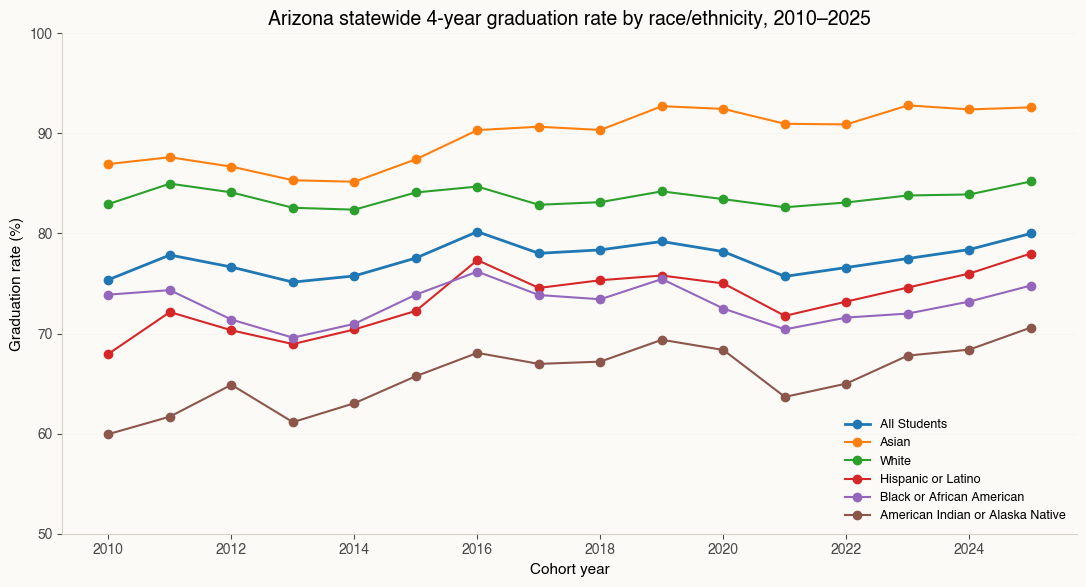

In [22]:
race_subgroups = [
    'All Students',
    'Asian',
    'White',
    'Hispanic or Latino',
    'Black or African American',
    'American Indian or Alaska Native',
]

fig, ax = plt.subplots(figsize=(11, 6))

for sg in race_subgroups:
    if sg in state_grad_pivot.columns:
        series = state_grad_pivot[sg]
        ax.plot(series.index, series.values, marker='o', label=sg, linewidth=2 if sg == 'All Students' else 1.5)

ax.set_title('Arizona statewide 4-year graduation rate by race/ethnicity, 2010–2025')
ax.set_xlabel('Cohort year')
ax.set_ylabel('Graduation rate (%)')
ax.set_ylim(50, 100)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

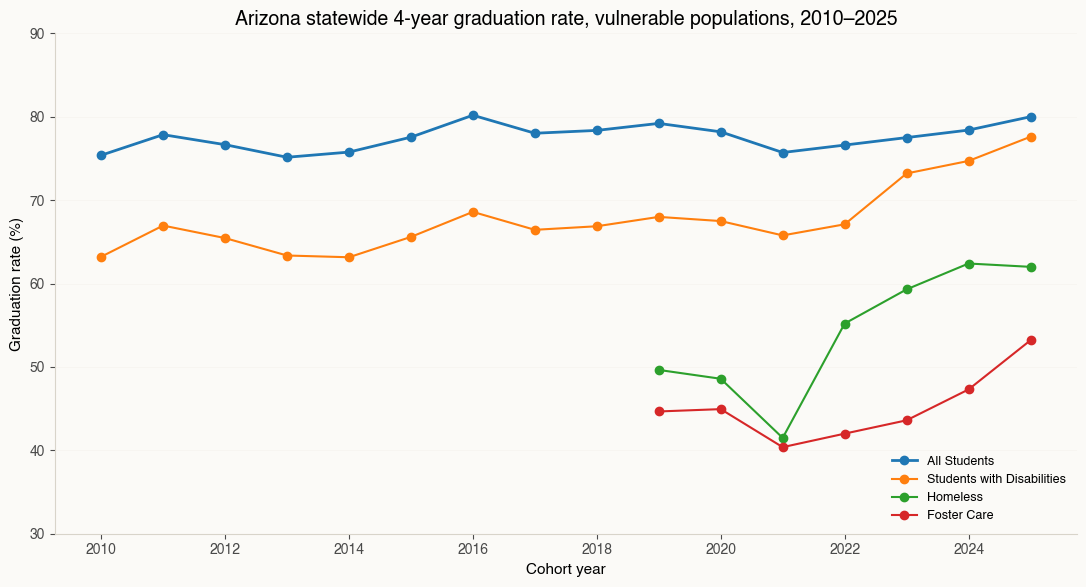

In [23]:
# Vulnerable populations — note that Homeless and Foster Care only start in 2019
vulnerable_subgroups = [
    'All Students',
    'Students with Disabilities',
    'Homeless',
    'Foster Care',
]

fig, ax = plt.subplots(figsize=(11, 6))

for sg in vulnerable_subgroups:
    if sg in state_grad_pivot.columns:
        series = state_grad_pivot[sg].dropna()
        ax.plot(series.index, series.values, marker='o', label=sg, linewidth=2 if sg == 'All Students' else 1.5)

ax.set_title('Arizona statewide 4-year graduation rate, vulnerable populations, 2010–2025')
ax.set_xlabel('Cohort year')
ax.set_ylabel('Graduation rate (%)')
ax.set_ylim(30, 90)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# Load processed test score state-level data
state_test = pd.read_csv('../data/processed/test_scores_state.csv')

# Filter to our analytical universe
RACE_SUBGROUPS = ['All Students', 'White', 'Asian', 'Hispanic or Latino', 
                  'Black or African American', 'American Indian or Alaska Native']

VULNERABLE_SUBGROUPS = ['All Students', 'Students with Disabilities', 'Homeless']
# Note: Foster Care is NOT in test data — we filtered to a smaller subgroup list at ingestion

# Build pivot tables: rows = year, cols = subgroup, values = pct_passing
def build_state_pivot(subject):
    df = state_test[
        (state_test['subject'] == subject)
        & (state_test['test_level'] == f'{"ELA" if "Language" in subject else "Math"} Grade 11')
        & (state_test['school_type'] == 'All')
        & (state_test['fay_status'] == 'All')
    ]
    pivot = df.pivot_table(
        index='fiscal_year', columns='subgroup', values='pct_passing', aggfunc='first'
    )
    return pivot

ela_pivot = build_state_pivot('English Language Arts')
math_pivot = build_state_pivot('Mathematics')

print("ELA Grade 11 — statewide passing % by subgroup:")
print(ela_pivot.round(1).to_string())

print("\nMath Grade 11 — statewide passing % by subgroup:")
print(math_pivot.round(1).to_string())

ELA Grade 11 — statewide passing % by subgroup:
subgroup     All Students  American Indian or Alaska Native  Asian  Black or African American  ELFEP14  Hispanic or Latino  Homeless  Income Eligibility 1 and 2  Limited English Proficient  Students with Disabilities  White
fiscal_year                                                                                                                                                                                                                    
2022                 38.0                              14.0   71.0                       23.0      NaN                25.0      14.0                        23.0                         NaN                         7.0   55.0
2023                 40.0                              15.0   73.0                       25.0      NaN                27.0      17.0                        24.0                         NaN                         7.0   57.0
2024                 38.0                              1

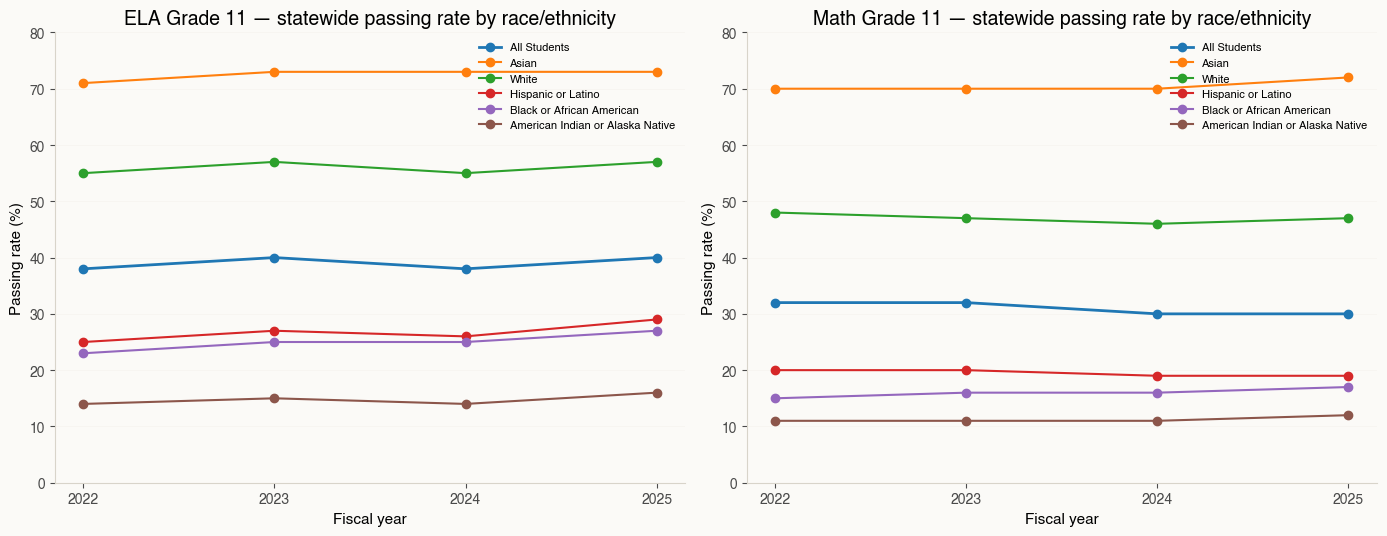

In [25]:
# Race/ethnicity test scores — ELA and Math side-by-side
race_test_subgroups = ['All Students', 'Asian', 'White', 'Hispanic or Latino', 
                        'Black or African American', 'American Indian or Alaska Native']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, pivot, title in [(axes[0], ela_pivot, 'ELA Grade 11'), (axes[1], math_pivot, 'Math Grade 11')]:
    for sg in race_test_subgroups:
        if sg in pivot.columns:
            series = pivot[sg].dropna()
            ax.plot(series.index, series.values, marker='o', label=sg, 
                    linewidth=2 if sg == 'All Students' else 1.5)
    ax.set_title(f'{title} — statewide passing rate by race/ethnicity')
    ax.set_xlabel('Fiscal year')
    ax.set_ylabel('Passing rate (%)')
    ax.set_ylim(0, 80)
    ax.set_xticks([2022, 2023, 2024, 2025])
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

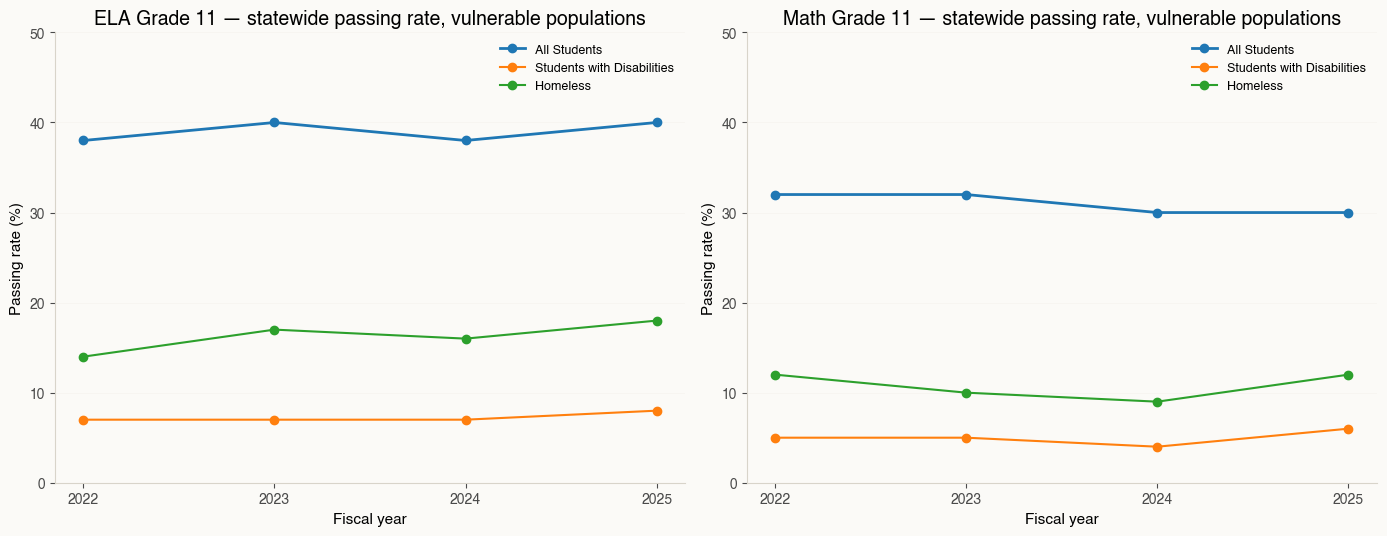

In [26]:
# Vulnerable populations test scores — note: Foster Care not in test data
vulnerable_test_subgroups = ['All Students', 'Students with Disabilities', 'Homeless']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, pivot, title in [(axes[0], ela_pivot, 'ELA Grade 11'), (axes[1], math_pivot, 'Math Grade 11')]:
    for sg in vulnerable_test_subgroups:
        if sg in pivot.columns:
            series = pivot[sg].dropna()
            ax.plot(series.index, series.values, marker='o', label=sg, 
                    linewidth=2 if sg == 'All Students' else 1.5)
    ax.set_title(f'{title} — statewide passing rate, vulnerable populations')
    ax.set_xlabel('Fiscal year')
    ax.set_ylabel('Passing rate (%)')
    ax.set_ylim(0, 50)
    ax.set_xticks([2022, 2023, 2024, 2025])
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
# Load needed data
districts_grad = pd.read_csv('../data/processed/districts_with_subgroups.csv')
test_districts = pd.read_csv('../data/processed/test_scores_districts.csv', low_memory=False)
trad = pd.read_csv('../data/reference/traditional_districts.csv')

# Filter grad data: 2025 cohort, All Students, traditional districts only
trad_ids = set(trad['lea_id'])
grad_2025 = districts_grad[
    (districts_grad['cohort_year'] == 2025)
    & (districts_grad['subgroup'] == 'All Students')
    & (districts_grad['lea_id'].isin(trad_ids))
    & (districts_grad['grad_rate'].notna())
][['lea_id', 'lea_name', 'grad_rate', 'n_cohort']].copy()
grad_2025 = grad_2025.rename(columns={'grad_rate': 'grad_rate_2025', 'n_cohort': 'cohort_size_2025'})
print(f"Districts with 2025 grad rate: {len(grad_2025)}")

# Filter test data: 2025, Grade 11 ELA & Math, All Students, traditional districts
test_2025 = test_districts[
    (test_districts['fiscal_year'] == 2025)
    & (test_districts['test_level'].isin(['ELA Grade 11', 'Math Grade 11']))
    & (test_districts['subgroup'] == 'All Students')
    & (test_districts['lea_id'].isin(trad_ids))
    & (test_districts['pct_passing'].notna())
][['lea_id', 'subject', 'pct_passing', 'n_tested']].copy()

# Pivot to wide format: one row per district with separate ELA / Math columns
test_pivot = test_2025.pivot_table(
    index='lea_id', columns='subject', values='pct_passing', aggfunc='first'
).reset_index()
test_pivot = test_pivot.rename(columns={
    'English Language Arts': 'ela_passing_2025',
    'Mathematics': 'math_passing_2025',
})
print(f"Districts with 2025 test data: {len(test_pivot)}")

# Join grad + test
merged = grad_2025.merge(test_pivot, on='lea_id', how='inner')
print(f"\nDistricts in BOTH grad & test data: {len(merged)}")

# How many have all 3 metrics non-null?
complete = merged.dropna(subset=['grad_rate_2025', 'math_passing_2025', 'ela_passing_2025'])
print(f"Districts with grad + math + ela all non-suppressed: {len(complete)}")

# Show the head and tail to spot-check
print("\n--- Top 5 by grad rate ---")
print(complete.nlargest(5, 'grad_rate_2025')[['lea_name', 'grad_rate_2025', 'math_passing_2025', 'ela_passing_2025']].to_string(index=False))
print("\n--- Bottom 5 by grad rate ---")
print(complete.nsmallest(5, 'grad_rate_2025')[['lea_name', 'grad_rate_2025', 'math_passing_2025', 'ela_passing_2025']].to_string(index=False))

Districts with 2025 grad rate: 81
Districts with 2025 test data: 106

Districts in BOTH grad & test data: 80
Districts with grad + math + ela all non-suppressed: 80

--- Top 5 by grad rate ---
                      lea_name  grad_rate_2025  math_passing_2025  ela_passing_2025
Higley Unified School District            96.4               54.0              61.0
       Bagdad Unified District            96.2               14.0              24.0
   Cave Creek Unified District            96.0               57.0              70.0
  Deer Valley Unified District            96.0               51.0              63.0
     Thatcher Unified District            95.7               37.0              45.0

--- Bottom 5 by grad rate ---
                               lea_name  grad_rate_2025  math_passing_2025  ela_passing_2025
            Whiteriver Unified District            57.2                3.0               6.0
         Ganado Unified School District            63.9               13.0            

In [28]:
# Why did 33 districts disappear?
trad_with_grad_2025 = set(grad_2025['lea_id'])
trad_with_test_2025 = set(test_pivot['lea_id'])
trad_ids = set(trad['lea_id'])

print(f"NCES traditional districts:                  {len(trad_ids)}")
print(f"Of those, with 2025 grad rate:              {len(trad_ids & trad_with_grad_2025)}")
print(f"Of those, with 2025 test data:              {len(trad_ids & trad_with_test_2025)}")
print(f"Of those, with both 2025 grad and test:     {len(trad_ids & trad_with_grad_2025 & trad_with_test_2025)}")

# Districts with grad data but no test data
missing_test = (trad_ids & trad_with_grad_2025) - trad_with_test_2025
print(f"\n{len(missing_test)} districts have 2025 grad but no 2025 test data:")
for lid in list(missing_test)[:10]:
    name = trad[trad['lea_id'] == lid]['district_name'].values[0]
    print(f"  [{lid}] {name}")

NCES traditional districts:                  214
Of those, with 2025 grad rate:              81
Of those, with 2025 test data:              106
Of those, with both 2025 grad and test:     80

1 districts have 2025 grad but no 2025 test data:
  [4369] Peach Springs Unified District


In [29]:
# Why are only 81 traditional districts present in 2025 grad data when 115 exist overall?
# Look at year-by-year coverage in our subgroups grad data
grad_traditional = districts_grad[
    (districts_grad['lea_id'].isin(trad_ids))
    & (districts_grad['subgroup'] == 'All Students')
]
print("Traditional districts with All Students grad rate by year:")
counts = grad_traditional.groupby('cohort_year')['lea_id'].nunique()
print(counts.to_string())

# How many distinct districts across all years?
print(f"\nTotal distinct traditional districts in subgroups data: {grad_traditional['lea_id'].nunique()}")

# Check 2025 specifically — districts that exist in trad list but missing from 2025
missing_from_2025 = trad_ids - set(grad_traditional[grad_traditional['cohort_year'] == 2025]['lea_id'])
present_in_other_years = set(grad_traditional[grad_traditional['cohort_year'] != 2025]['lea_id'])
missing_but_have_other = missing_from_2025 & present_in_other_years

print(f"\nDistricts not in 2025 but present in other years: {len(missing_but_have_other)}")
for lid in list(missing_but_have_other)[:15]:
    name = trad[trad['lea_id'] == lid]['district_name'].values[0]
    other_years = sorted(grad_traditional[grad_traditional['lea_id'] == lid]['cohort_year'].unique().tolist())
    print(f"  [{lid}] {name:<45s} | years present: {other_years[:3]}...{other_years[-2:] if len(other_years) > 3 else ''}")
    

Traditional districts with All Students grad rate by year:
cohort_year
2010    112
2011    112
2012    113
2013    112
2014    113
2015    111
2016    112
2017    111
2018    111
2019    110
2020    109
2021    111
2022    114
2023    114
2024    114
2025    113

Total distinct traditional districts in subgroups data: 115

Districts not in 2025 but present in other years: 2
  [4395] Cedar Unified District                        | years present: [2010, 2011, 2012]...[2017, 2018]
  [4213] Young Elementary District                     | years present: [2010, 2011, 2012]...[2023, 2024]


In [30]:
# How many traditional districts have a 2025 row but NaN grad_rate?
trad_2025 = districts_grad[
    (districts_grad['lea_id'].isin(trad_ids))
    & (districts_grad['subgroup'] == 'All Students')
    & (districts_grad['cohort_year'] == 2025)
]
print(f"Traditional districts with 2025 row: {len(trad_2025)}")
print(f"  ...with non-null grad_rate:        {trad_2025['grad_rate'].notna().sum()}")
print(f"  ...with NaN grad_rate (suppressed): {trad_2025['grad_rate'].isna().sum()}")

# Show the suppressed districts to confirm they're small/rural
suppressed = trad_2025[trad_2025['grad_rate'].isna()]
print(f"\nSample of districts with suppressed 2025 grad rate:")
for _, row in suppressed.head(15).iterrows():
    name = trad[trad['lea_id'] == row['lea_id']]['district_name'].values[0] if row['lea_id'] in trad['lea_id'].values else row.get('lea_name', '?')
    cohort = row.get('n_cohort', '?')
    print(f"  [{row['lea_id']}] {name:<45s}  cohort: {cohort}")

Traditional districts with 2025 row: 113
  ...with non-null grad_rate:        81
  ...with NaN grad_rate (suppressed): 32

Sample of districts with suppressed 2025 grad rate:
  [4156] Sanders Unified District                       cohort: 57.0
  [4168] Tombstone Unified District                     cohort: 128.0
  [4170] Willcox Unified District                       cohort: 96.0
  [4171] Bowie Unified District                         cohort: nan
  [4172] San Simon Unified District                     cohort: nan
  [4173] St David Unified District                      cohort: 32.0
  [4190] Valley Union High School District              cohort: 16.0
  [4193] Williams Unified District                      cohort: 56.0
  [4194] Grand Canyon Unified District                  cohort: 15.0
  [4195] Fredonia-Moccasin Unified District             cohort: 12.0
  [4212] Hayden-Winkelman Unified District              cohort: 17.0
  [4217] Graham County Special Services                 cohort: nan

In [31]:
# Look directly at the raw 2025 file for one of the surprising suppressions
import pandas as pd

raw_2025 = pd.read_excel(
    '../data/raw/4Y-GradRate-Cohort2025.xlsx',
    sheet_name='LEA by Subgroup'
)
raw_2025.columns = [str(c).strip() for c in raw_2025.columns]

# Show what the raw row looks like for Tombstone Unified
mask = raw_2025['LEA Name'].str.contains('Tombstone', case=False, na=False) if 'LEA Name' in raw_2025.columns else (
    raw_2025[raw_2025.columns[1]].astype(str).str.contains('Tombstone', case=False, na=False)
)
print("Raw 2025 Tombstone rows:")
print(raw_2025[mask].to_string())

# Same for Sanders
print("\nRaw 2025 Sanders rows:")
mask = raw_2025['LEA Name'].str.contains('Sanders', case=False, na=False) if 'LEA Name' in raw_2025.columns else (
    raw_2025[raw_2025.columns[1]].astype(str).str.contains('Sanders', case=False, na=False)
)
print(raw_2025[mask].to_string())

# Show columns to confirm structure
print("\nColumns in 2025 file:")
print(raw_2025.columns.tolist())

Raw 2025 Tombstone rows:
    Cohort Year Graduation Rate Type  LEA Entity ID                    LEA Name   County                          Subgroup Number in Cohort Number Graduated Percent Graduated in 4 Years
77         2025               4 Year           4168  Tombstone Unified District  Cochise                               All              128                *                            *
78         2025               4 Year           4168  Tombstone Unified District  Cochise  American Indian or Alaska Native                *                *                            *
79         2025               4 Year           4168  Tombstone Unified District  Cochise                             Asian                *                *                            *
80         2025               4 Year           4168  Tombstone Unified District  Cochise            Black/African American                *                *                            *
81         2025               4 Year         

In [32]:
def build_scatter_data(year):
    """Build merged grad+test scatter data for a given year."""
    grad_year = districts_grad[
        (districts_grad['cohort_year'] == year)
        & (districts_grad['subgroup'] == 'All Students')
        & (districts_grad['lea_id'].isin(trad_ids))
        & (districts_grad['grad_rate'].notna())
    ][['lea_id', 'lea_name', 'grad_rate', 'n_cohort']].copy()
    grad_year.columns = ['lea_id', 'lea_name', 'grad_rate', 'cohort_size']
    
    test_year = test_districts[
        (test_districts['fiscal_year'] == year)
        & (test_districts['test_level'].isin(['ELA Grade 11', 'Math Grade 11']))
        & (test_districts['subgroup'] == 'All Students')
        & (test_districts['lea_id'].isin(trad_ids))
        & (test_districts['pct_passing'].notna())
    ][['lea_id', 'subject', 'pct_passing', 'n_tested']].copy()
    
    test_pivot = test_year.pivot_table(
        index='lea_id', columns='subject', values='pct_passing', aggfunc='first'
    ).reset_index()
    test_pivot.columns = [
        'lea_id' if c == 'lea_id' else 
        'ela_passing' if 'Language' in str(c) else 
        'math_passing' if c == 'Mathematics' else c 
        for c in test_pivot.columns
    ]
    
    merged = grad_year.merge(test_pivot, on='lea_id', how='inner')
    complete = merged.dropna(subset=['grad_rate', 'math_passing', 'ela_passing'])
    return complete

# Build for both years
scatter_2024 = build_scatter_data(2024)
scatter_2025 = build_scatter_data(2025)

print(f"2024 analytical universe: {len(scatter_2024)} districts")
print(f"2025 analytical universe: {len(scatter_2025)} districts")
print(f"Districts in 2024 but NOT in 2025: {len(set(scatter_2024['lea_id']) - set(scatter_2025['lea_id']))}")
print(f"Districts in 2025 but NOT in 2024: {len(set(scatter_2025['lea_id']) - set(scatter_2024['lea_id']))}")

# Show statewide reference points for both years
print(f"\nStatewide All Students 2024:")
mask_2024 = (state_test['fiscal_year'] == 2024) & (state_test['subgroup'] == 'All Students') & (state_test['school_type'] == 'All')
print(f"  ELA Grade 11: {state_test[mask_2024 & (state_test['test_level'] == 'ELA Grade 11')]['pct_passing'].values}")
print(f"  Math Grade 11: {state_test[mask_2024 & (state_test['test_level'] == 'Math Grade 11')]['pct_passing'].values}")
print(f"  Grad rate (statewide All): {state_grad_subgroups[(state_grad_subgroups['cohort_year']==2024) & (state_grad_subgroups['subgroup']=='All Students')]['grad_rate'].values}")

print(f"\nStatewide All Students 2025:")
mask_2025 = (state_test['fiscal_year'] == 2025) & (state_test['subgroup'] == 'All Students') & (state_test['school_type'] == 'All')
print(f"  ELA Grade 11: {state_test[mask_2025 & (state_test['test_level'] == 'ELA Grade 11')]['pct_passing'].values}")
print(f"  Math Grade 11: {state_test[mask_2025 & (state_test['test_level'] == 'Math Grade 11')]['pct_passing'].values}")
print(f"  Grad rate (statewide All): {state_grad_subgroups[(state_grad_subgroups['cohort_year']==2025) & (state_grad_subgroups['subgroup']=='All Students')]['grad_rate'].values}")

2024 analytical universe: 80 districts
2025 analytical universe: 80 districts
Districts in 2024 but NOT in 2025: 3
Districts in 2025 but NOT in 2024: 3

Statewide All Students 2024:
  ELA Grade 11: [38.]
  Math Grade 11: [30.]
  Grad rate (statewide All): [78.4]

Statewide All Students 2025:
  ELA Grade 11: [40.]
  Math Grade 11: [30.]
  Grad rate (statewide All): [80.]


In [33]:
in_2024_not_2025 = set(scatter_2024['lea_id']) - set(scatter_2025['lea_id'])
in_2025_not_2024 = set(scatter_2025['lea_id']) - set(scatter_2024['lea_id'])

print("In 2024 but NOT in 2025 (lost):")
for lid in in_2024_not_2025:
    name = scatter_2024[scatter_2024['lea_id'] == lid]['lea_name'].values[0]
    print(f"  [{lid}] {name}")

print("\nIn 2025 but NOT in 2024 (gained):")
for lid in in_2025_not_2024:
    name = scatter_2025[scatter_2025['lea_id'] == lid]['lea_name'].values[0]
    print(f"  [{lid}] {name}")
    

In 2024 but NOT in 2025 (lost):
  [4156] Sanders Unified District
  [4390] Pinon Unified District
  [4487] Cottonwood-Oak Creek Elementary District

In 2025 but NOT in 2024 (gained):
  [4210] San Carlos Unified District
  [4211] Miami Unified District
  [4412] Baboquivari Unified School District #40


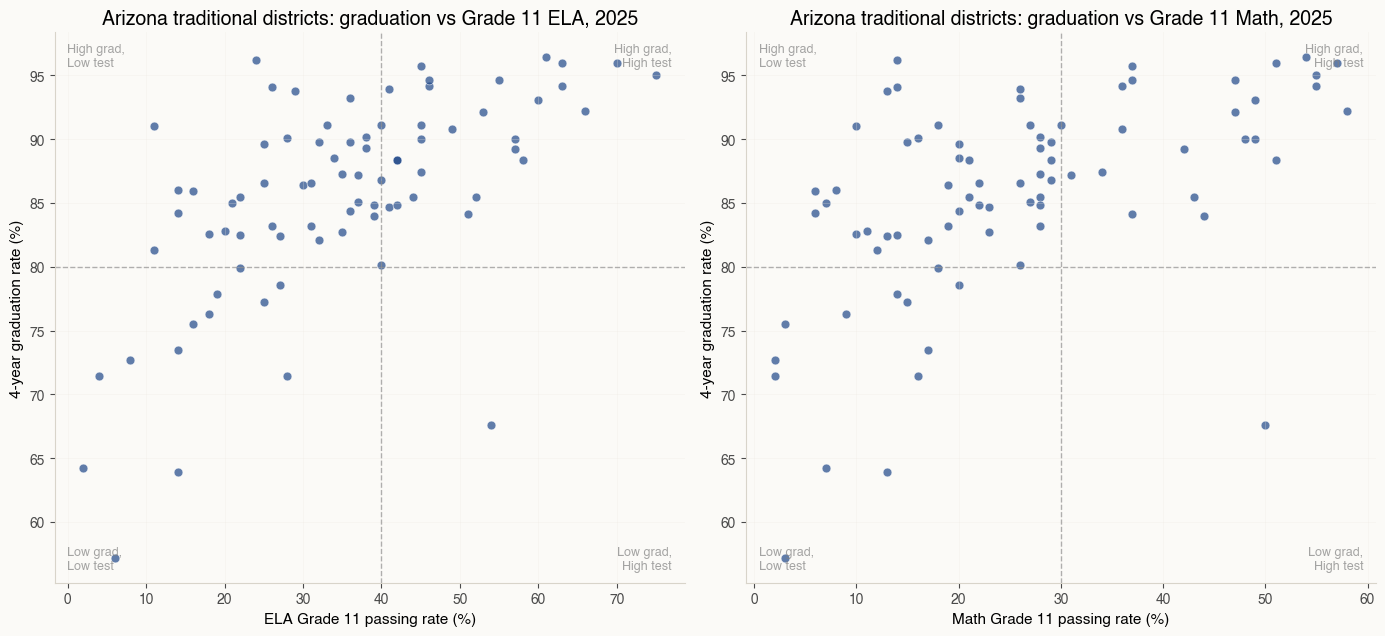

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

statewide_ela_2025 = 40
statewide_math_2025 = 30
statewide_grad_2025 = 80

for ax, x_col, x_ref, x_label in [
    (axes[0], 'ela_passing', statewide_ela_2025, 'ELA Grade 11 passing rate (%)'),
    (axes[1], 'math_passing', statewide_math_2025, 'Math Grade 11 passing rate (%)'),
]:
    ax.scatter(
        scatter_2025[x_col], 
        scatter_2025['grad_rate'],
        s=40, alpha=0.7, color='#1f4788', edgecolor='white', linewidth=0.5
    )
    
    # Reference lines: statewide rates
    ax.axvline(x_ref, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(statewide_grad_2025, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    
    # Quadrant labels
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.text(0.98, 0.98, 'High grad,\nHigh test', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray', alpha=0.7)
    ax.text(0.02, 0.98, 'High grad,\nLow test', transform=ax.transAxes,
            ha='left', va='top', fontsize=9, color='gray', alpha=0.7)
    ax.text(0.98, 0.02, 'Low grad,\nHigh test', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9, color='gray', alpha=0.7)
    ax.text(0.02, 0.02, 'Low grad,\nLow test', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=9, color='gray', alpha=0.7)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel('4-year graduation rate (%)')
    ax.set_title(f'Arizona traditional districts: graduation vs Grade 11 {x_label.split()[0]}, 2025')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

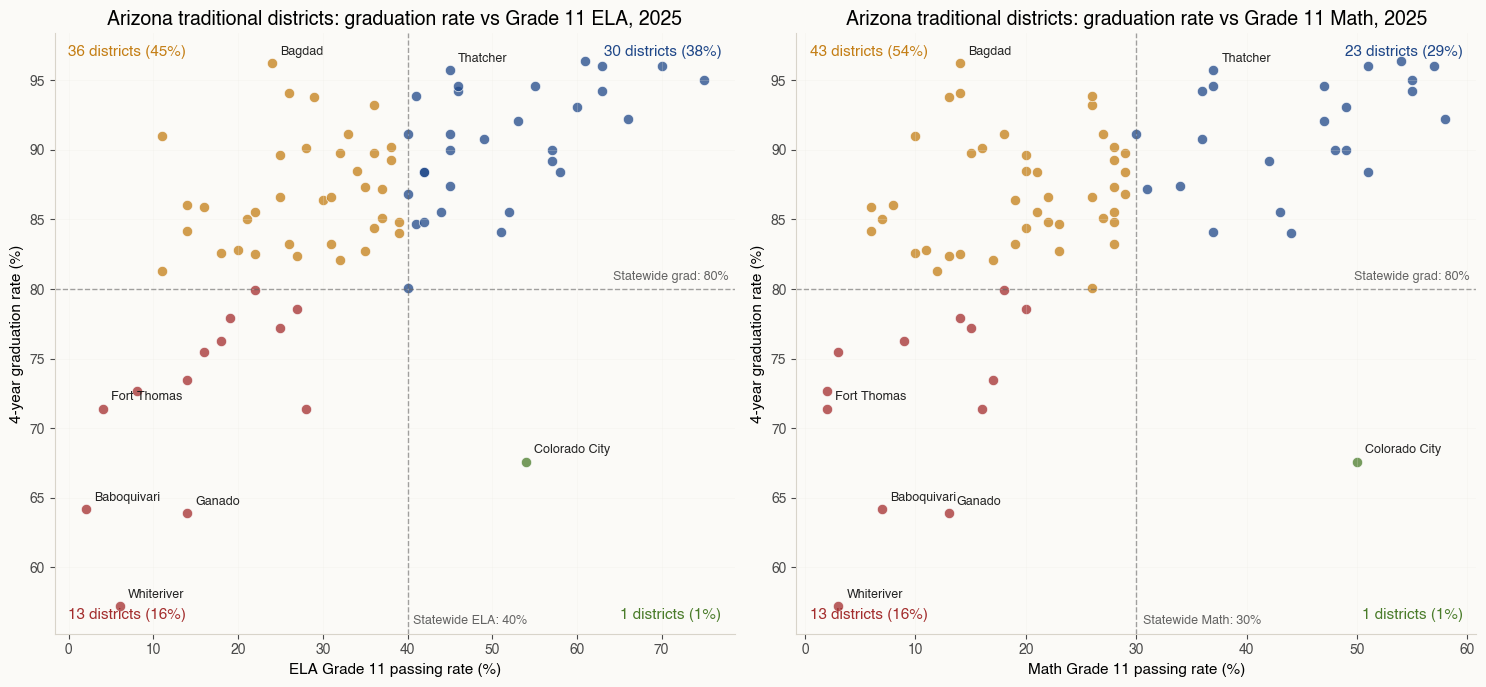

In [36]:
# Slimmed labels — only districts the article will likely name
LABEL_DISTRICTS = {
    'Bagdad Unified District',                  # the diploma-vs-skills star
    'Colorado City Unified District',           # the inverse outlier
    'Whiteriver Unified District',              # tribal, lowest grad
    'Baboquivari Unified School District #40',  # tribal, low both
    'Ganado Unified School District',           # tribal, low both
    'Fort Thomas Unified District',             # tribal, low both
    'Thatcher Unified District',                # rural unified, illustrative top performer
}

# Re-run the chart code with updated LABEL_DISTRICTS — paste it in or just rerun the previous cell
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

QUAD_COLORS = {
    'high_grad_high_test': '#1f4788',
    'high_grad_low_test':  '#c47e15',
    'low_grad_high_test':  '#4a7c2a',
    'low_grad_low_test':   '#a32d2d',
}

statewide_grad_2025 = 80.0

def classify(grad, test, test_ref):
    high_grad = grad >= statewide_grad_2025
    high_test = test >= test_ref
    if high_grad and high_test: return 'high_grad_high_test'
    if high_grad and not high_test: return 'high_grad_low_test'
    if not high_grad and high_test: return 'low_grad_high_test'
    return 'low_grad_low_test'

for ax, x_col, x_ref, x_label, subject_short in [
    (axes[0], 'ela_passing', 40, 'ELA Grade 11 passing rate (%)', 'ELA'),
    (axes[1], 'math_passing', 30, 'Math Grade 11 passing rate (%)', 'Math'),
]:
    df = scatter_2025.copy()
    df['quad'] = df.apply(lambda r: classify(r['grad_rate'], r[x_col], x_ref), axis=1)
    
    for quad, color in QUAD_COLORS.items():
        sub = df[df['quad'] == quad]
        ax.scatter(sub[x_col], sub['grad_rate'], s=55, alpha=0.75,
                   color=color, edgecolor='white', linewidth=0.6, label=None)
    
    ax.axvline(x_ref, color='#4a4a4a', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(statewide_grad_2025, color='#4a4a4a', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.text(x_ref + 0.6, ax.get_ylim()[0] + 0.5, f'Statewide {subject_short}: {x_ref}%',
            fontsize=9, color='#4a4a4a', alpha=0.85, va='bottom', ha='left')
    ax.text(ax.get_xlim()[1] * 0.99, statewide_grad_2025 + 0.4, 'Statewide grad: 80%',
            fontsize=9, color='#4a4a4a', alpha=0.85, ha='right', va='bottom')
    
    for _, row in df.iterrows():
        if row['lea_name'] in LABEL_DISTRICTS:
            x = row[x_col]
            y = row['grad_rate']
            label = row['lea_name'].replace(' Unified School District', '').replace(' Unified District', '').replace(' #40', '')
            ax.annotate(label, (x, y), xytext=(6, 6), textcoords='offset points',
                       fontsize=9, color='#1a1a1a', alpha=0.95)
    
    counts = df['quad'].value_counts()
    n_total = len(df)
    quad_count_text = {
        'high_grad_high_test': (0.98, 0.98, 'right', 'top'),
        'high_grad_low_test':  (0.02, 0.98, 'left', 'top'),
        'low_grad_high_test':  (0.98, 0.02, 'right', 'bottom'),
        'low_grad_low_test':   (0.02, 0.02, 'left', 'bottom'),
    }
    for quad, (xpos, ypos, ha, va) in quad_count_text.items():
        n = counts.get(quad, 0)
        pct = 100 * n / n_total
        ax.text(xpos, ypos, f'{n} districts ({pct:.0f}%)', transform=ax.transAxes,
                ha=ha, va=va, fontsize=11, color=QUAD_COLORS[quad], fontweight=600)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel('4-year graduation rate (%)')
    ax.set_title(f'Arizona traditional districts: graduation rate vs Grade 11 {subject_short}, 2025')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [38]:
# Build the named quadrant table — for journalism use
def build_quadrant_table(scatter_df, x_col, x_ref, statewide_grad=80.0):
    """Return a dataframe of districts in each quadrant, sorted by gap size."""
    df = scatter_df.copy()
    df['grad_above'] = df['grad_rate'] >= statewide_grad
    df['test_above'] = df[x_col] >= x_ref
    df['grad_gap'] = df['grad_rate'] - statewide_grad
    df['test_gap'] = df[x_col] - x_ref
    
    def quad_label(row):
        if row['grad_above'] and row['test_above']: return 'High grad, High test'
        if row['grad_above'] and not row['test_above']: return 'High grad, LOW test'
        if not row['grad_above'] and row['test_above']: return 'LOW grad, High test'
        return 'LOW grad, LOW test'
    
    df['quadrant'] = df.apply(quad_label, axis=1)
    
    # For "diploma vs skills" outliers we want districts where grad is high AND test is very low
    # Sort: highest grad rate, then lowest test rate
    df['diploma_vs_skills_score'] = df['grad_rate'] - df[x_col]  # bigger = more extreme
    
    return df

# ELA quadrants
ela_quad = build_quadrant_table(scatter_2025, 'ela_passing', 40, 80.0)
math_quad = build_quadrant_table(scatter_2025, 'math_passing', 30, 80.0)

# Top 15 "diploma vs skills" outliers — high grad, low test, ELA
print("="*100)
print("ELA — Top 15 'High grad, Low test' districts (sorted by largest grad-test gap)")
print("="*100)
ela_outliers = ela_quad[ela_quad['quadrant'] == 'High grad, LOW test'].sort_values('diploma_vs_skills_score', ascending=False)
print(ela_outliers[['lea_name', 'cohort_size', 'grad_rate', 'ela_passing', 'diploma_vs_skills_score']].head(15).to_string(index=False))

print("\n" + "="*100)
print("MATH — Top 15 'High grad, Low test' districts (sorted by largest grad-test gap)")
print("="*100)
math_outliers = math_quad[math_quad['quadrant'] == 'High grad, LOW test'].sort_values('diploma_vs_skills_score', ascending=False)
print(math_outliers[['lea_name', 'cohort_size', 'grad_rate', 'math_passing', 'diploma_vs_skills_score']].head(15).to_string(index=False))

# Also: districts that appear in BOTH ELA and Math top 15 (consistent diploma-vs-skills outliers)
ela_top15_ids = set(ela_outliers.head(15)['lea_id'])
math_top15_ids = set(math_outliers.head(15)['lea_id'])
both = ela_top15_ids & math_top15_ids
print(f"\nDistricts in BOTH top-15 lists ({len(both)}):")
for lid in both:
    name = ela_outliers[ela_outliers['lea_id'] == lid]['lea_name'].values[0]
    cohort = ela_outliers[ela_outliers['lea_id'] == lid]['cohort_size'].values[0]
    grad = ela_outliers[ela_outliers['lea_id'] == lid]['grad_rate'].values[0]
    ela = ela_outliers[ela_outliers['lea_id'] == lid]['ela_passing'].values[0]
    math = math_outliers[math_outliers['lea_id'] == lid]['math_passing'].values[0]
    print(f"  {name:<45s}  cohort: {cohort:>4.0f}  grad: {grad:>5.1f}  ELA: {ela:>4.0f}  Math: {math:>4.0f}")

ELA — Top 15 'High grad, Low test' districts (sorted by largest grad-test gap)
                                    lea_name  cohort_size  grad_rate  ela_passing  diploma_vs_skills_score
         Kayenta Unified School District #27        166.0       91.0         11.0                     80.0
                     Bagdad Unified District          NaN       96.2         24.0                     72.2
         Antelope Union High School District          NaN       86.0         14.0                     72.0
                      Miami Unified District         75.0       81.3         11.0                     70.3
Santa Cruz Valley Union High School District        101.0       84.2         14.0                     70.2
                     Bisbee Unified District         85.0       85.9         16.0                     69.9
             Yuma Union High School District       2693.0       94.1         26.0                     68.1
          Santa Cruz Valley Unified District        390.0       9

In [39]:
# Check why Bagdad and Antelope Union show NaN cohort
for name_search in ['Bagdad', 'Antelope Union']:
    matching = districts_grad[
        (districts_grad['lea_name'].str.contains(name_search, case=False, na=False))
        & (districts_grad['subgroup'] == 'All Students')
        & (districts_grad['cohort_year'] == 2025)
    ]
    print(f"\n{name_search}:")
    print(matching[['lea_id', 'lea_name', 'cohort_year', 'subgroup', 'grad_rate', 'n_cohort']].to_string(index=False))


Bagdad:
 lea_id                lea_name  cohort_year     subgroup  grad_rate  n_cohort
   4468 Bagdad Unified District         2025 All Students       96.2       NaN

Antelope Union:
 lea_id                            lea_name  cohort_year     subgroup  grad_rate  n_cohort
   4506 Antelope Union High School District         2025 All Students       86.0       NaN


In [40]:
# 12 consistent outliers (in BOTH ELA and Math top-15)
OUTLIER_DISTRICT_NAMES = [
    'Tolleson Union High School District',
    'Santa Cruz Valley Union High School District',
    'Bisbee Unified District',
    'Santa Cruz Valley Unified District',
    'Kayenta Unified School District #27',
    'Globe Unified District',
    'Bagdad Unified District',
    'Florence Unified School District',
    'Sunnyside Unified District',
    'Antelope Union High School District',
    'Yuma Union High School District',
    'Parker Unified School District',
]

# Get their lea_ids
outlier_ids = []
for name in OUTLIER_DISTRICT_NAMES:
    match = scatter_2025[scatter_2025['lea_name'] == name]
    if len(match) == 1:
        outlier_ids.append(int(match['lea_id'].iloc[0]))
    else:
        print(f"WARNING: ambiguous/missing match for '{name}': {len(match)} rows")

print(f"\nFound {len(outlier_ids)} outlier district IDs\n")

# Get racial subgroup breakdown for these districts: grad rate (2025) + test scores (2025)
RACIAL_SUBGROUPS = ['All Students', 'White', 'Hispanic or Latino', 
                    'Black or African American', 'American Indian or Alaska Native', 'Asian']

# Grad rate by subgroup
grad_subgroup = districts_grad[
    (districts_grad['cohort_year'] == 2025)
    & (districts_grad['lea_id'].isin(outlier_ids))
    & (districts_grad['subgroup'].isin(RACIAL_SUBGROUPS))
][['lea_id', 'lea_name', 'subgroup', 'grad_rate', 'n_cohort']].copy()

# Test scores by subgroup (Math 11 + ELA 11)
test_subgroup = test_districts[
    (test_districts['fiscal_year'] == 2025)
    & (test_districts['lea_id'].isin(outlier_ids))
    & (test_districts['test_level'].isin(['ELA Grade 11', 'Math Grade 11']))
    & (test_districts['subgroup'].isin(RACIAL_SUBGROUPS))
    & (test_districts['pct_passing'].notna())
][['lea_id', 'subject', 'subgroup', 'pct_passing', 'n_tested']].copy()

# Make a wide-format summary per district
print("="*120)
print("SUBGROUP BREAKDOWN FOR DIPLOMA-VS-SKILLS OUTLIERS (2025)")
print("="*120)

for lid in outlier_ids:
    name_match = grad_subgroup[grad_subgroup['lea_id'] == lid]
    if len(name_match) == 0:
        continue
    name = name_match.iloc[0]['lea_name']
    
    print(f"\n{'─'*120}")
    print(f"  {name}  (LEA {lid})")
    print(f"{'─'*120}")
    print(f"  {'Subgroup':<40s} {'Cohort':>8s}  {'Grad %':>8s}    {'ELA %':>8s}    {'Math %':>8s}")
    
    for sg in RACIAL_SUBGROUPS:
        # Grad
        grad_row = grad_subgroup[(grad_subgroup['lea_id'] == lid) & (grad_subgroup['subgroup'] == sg)]
        grad_str = f"{grad_row.iloc[0]['grad_rate']:>6.1f}" if len(grad_row) > 0 and pd.notna(grad_row.iloc[0]['grad_rate']) else "    —"
        cohort_str = f"{grad_row.iloc[0]['n_cohort']:>6.0f}" if len(grad_row) > 0 and pd.notna(grad_row.iloc[0]['n_cohort']) else "    —"
        
        # ELA
        ela_row = test_subgroup[(test_subgroup['lea_id'] == lid) & (test_subgroup['subgroup'] == sg) & (test_subgroup['subject'] == 'English Language Arts')]
        ela_str = f"{ela_row.iloc[0]['pct_passing']:>6.0f}" if len(ela_row) > 0 else "    —"
        
        # Math
        math_row = test_subgroup[(test_subgroup['lea_id'] == lid) & (test_subgroup['subgroup'] == sg) & (test_subgroup['subject'] == 'Mathematics')]
        math_str = f"{math_row.iloc[0]['pct_passing']:>6.0f}" if len(math_row) > 0 else "    —"
        
        print(f"  {sg:<40s} {cohort_str}    {grad_str}     {ela_str}      {math_str}")


Found 12 outlier district IDs

SUBGROUP BREAKDOWN FOR DIPLOMA-VS-SKILLS OUTLIERS (2025)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Tolleson Union High School District  (LEA 4288)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Subgroup                                   Cohort    Grad %       ELA %      Math %
  All Students                               3460      89.6         25          20
  White                                       188      90.4         44          39
  Hispanic or Latino                         2626      89.9         24          19
  Black or African American                   333      88.9         21          13
  American Indian or Alaska Native             51      78.4         22          23
  Asian                                        —      95.7         56          58

──────────────────────────────────

In [42]:
# Compute white-vs-Hispanic gaps for each outlier district
GAP_THRESHOLD = 15  # points — separates "structural" from "racial gap"

results = []

for lid in outlier_ids:
    name_match = grad_subgroup[grad_subgroup['lea_id'] == lid]
    if len(name_match) == 0:
        continue
    name = name_match.iloc[0]['lea_name']
    
    # Pull each metric for white and hispanic subgroups
    def get_metric(metric_df, lea_id, sg, col, **filters):
        row = metric_df[(metric_df['lea_id'] == lea_id) & (metric_df['subgroup'] == sg)]
        for k, v in filters.items():
            row = row[row[k] == v]
        if len(row) == 0:
            return None
        val = row.iloc[0][col]
        return val if pd.notna(val) else None
    
    white_grad = get_metric(grad_subgroup, lid, 'White', 'grad_rate')
    hisp_grad = get_metric(grad_subgroup, lid, 'Hispanic or Latino', 'grad_rate')
    
    white_ela = get_metric(test_subgroup, lid, 'White', 'pct_passing', subject='English Language Arts')
    hisp_ela = get_metric(test_subgroup, lid, 'Hispanic or Latino', 'pct_passing', subject='English Language Arts')
    
    white_math = get_metric(test_subgroup, lid, 'White', 'pct_passing', subject='Mathematics')
    hisp_math = get_metric(test_subgroup, lid, 'Hispanic or Latino', 'pct_passing', subject='Mathematics')
    
    # Compute gaps where data permits
    ela_gap = (white_ela - hisp_ela) if (white_ela is not None and hisp_ela is not None) else None
    math_gap = (white_math - hisp_math) if (white_math is not None and hisp_math is not None) else None
    grad_gap = (white_grad - hisp_grad) if (white_grad is not None and hisp_grad is not None) else None
    
    # Average test gap (if both subjects have data)
    if ela_gap is not None and math_gap is not None:
        avg_test_gap = (ela_gap + math_gap) / 2
    elif ela_gap is not None:
        avg_test_gap = ela_gap
    elif math_gap is not None:
        avg_test_gap = math_gap
    else:
        avg_test_gap = None
    
    # Classify
    if avg_test_gap is None:
        story_type = 'Insufficient data'
    elif avg_test_gap < GAP_THRESHOLD:
        story_type = 'Type 1: STRUCTURAL (gap < 15 pts)'
    else:
        story_type = 'Type 2: RACIAL (gap ≥ 15 pts)'
    
    inverse_flag = '⚠ INVERSE GRAD' if (grad_gap is not None and grad_gap < -3) else ''
    
    results.append({
        'lea_id': lid,
        'name': name,
        'white_grad': white_grad,
        'hisp_grad': hisp_grad,
        'grad_gap': grad_gap,
        'white_ela': white_ela,
        'hisp_ela': hisp_ela,
        'ela_gap': ela_gap,
        'white_math': white_math,
        'hisp_math': hisp_math,
        'math_gap': math_gap,
        'avg_test_gap': avg_test_gap,
        'story_type': story_type,
        'inverse_flag': inverse_flag,
    })

results_df = pd.DataFrame(results)

# Sort by story type, then by gap size within type
results_df['_sort_key'] = results_df['story_type'] + results_df['avg_test_gap'].fillna(-999).astype(str)
results_df = results_df.sort_values(['story_type', 'avg_test_gap'], ascending=[True, False])

# Print formatted table
print("="*120)
print("WHITE vs HISPANIC GAP ANALYSIS — DIPLOMA-VS-SKILLS OUTLIERS, 2025")
print("="*120)
for story_type in results_df['story_type'].unique():
    sub = results_df[results_df['story_type'] == story_type]
    print(f"\n{story_type}  ({len(sub)} districts)")
    print("─" * 120)
    print(f"  {'District':<45s} {'W grad':>7s} {'H grad':>7s} {'W ELA':>6s} {'H ELA':>6s} {'ΔELA':>6s} {'W Math':>7s} {'H Math':>7s} {'ΔMath':>7s} {'Avg gap':>8s}  Flag")
    for _, row in sub.iterrows():
        def fmt(v, w=6):
            return f"{v:>{w}.0f}" if pd.notna(v) and v is not None else f"{'—':>{w}s}"
        def fmt_gap(v, w=6):
            return f"{v:>+{w}.0f}" if pd.notna(v) and v is not None else f"{'—':>{w}s}"
        
        name_short = row['name'].replace(' Unified School District', '').replace(' Unified District', '').replace(' #40', '').replace(' #27', '')
        print(f"  {name_short:<45s} {fmt(row['white_grad'], 7)} {fmt(row['hisp_grad'], 7)} "
              f"{fmt(row['white_ela'])} {fmt(row['hisp_ela'])} {fmt_gap(row['ela_gap'])} "
              f"{fmt(row['white_math'], 7)} {fmt(row['hisp_math'], 7)} {fmt_gap(row['math_gap'], 7)} "
              f"{fmt_gap(row['avg_test_gap'], 8)}  {row['inverse_flag']}")

WHITE vs HISPANIC GAP ANALYSIS — DIPLOMA-VS-SKILLS OUTLIERS, 2025

Insufficient data  (2 districts)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  District                                       W grad  H grad  W ELA  H ELA   ΔELA  W Math  H Math   ΔMath  Avg gap  Flag
  Kayenta                                             —       —      —      —      —       —       —       —        —  
  Bagdad                                              —      93     34      —      —      18       —       —        —  

Type 1: STRUCTURAL (gap < 15 pts)  (5 districts)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  District                                       W grad  H grad  W ELA  H ELA   ΔELA  W Math  H Math   ΔMath  Avg gap  Flag
  Yuma Union High School District                    87      95     41     24    +17      23      13     +10      +14  ⚠

In [43]:
# Compute white-vs-Hispanic grad gap for ALL 80 traditional districts in our analytical universe
all_grad_gaps = []

for lid in scatter_2025['lea_id']:
    name_match = scatter_2025[scatter_2025['lea_id'] == lid]
    if len(name_match) == 0:
        continue
    name = name_match.iloc[0]['lea_name']
    
    # Get grad rates by subgroup for this district in 2025
    grad_for_lid = districts_grad[
        (districts_grad['lea_id'] == lid)
        & (districts_grad['cohort_year'] == 2025)
        & (districts_grad['subgroup'].isin(['White', 'Hispanic or Latino', 'All Students']))
    ][['subgroup', 'grad_rate', 'n_cohort']].copy()
    
    def pull(sg, col):
        row = grad_for_lid[grad_for_lid['subgroup'] == sg]
        if len(row) == 0:
            return None
        val = row.iloc[0][col]
        return val if pd.notna(val) else None
    
    white_grad = pull('White', 'grad_rate')
    hisp_grad = pull('Hispanic or Latino', 'grad_rate')
    white_n = pull('White', 'n_cohort')
    hisp_n = pull('Hispanic or Latino', 'n_cohort')
    overall_grad = pull('All Students', 'grad_rate')
    overall_n = pull('All Students', 'n_cohort')
    
    if white_grad is not None and hisp_grad is not None:
        all_grad_gaps.append({
            'lea_id': lid,
            'name': name,
            'overall_grad': overall_grad,
            'overall_n': overall_n,
            'white_grad': white_grad,
            'white_n': white_n,
            'hisp_grad': hisp_grad,
            'hisp_n': hisp_n,
            'gap': white_grad - hisp_grad,  # positive = white higher (expected); negative = inverse
        })

gap_df = pd.DataFrame(all_grad_gaps)

print(f"Districts with both white and Hispanic 2025 grad rate data: {len(gap_df)}")
print(f"\nDistribution of white−Hispanic grad gap (positive = white graduates higher):")
print(f"  White grads ≥ 5+ pts higher than Hispanic:    {((gap_df['gap']) >= 5).sum()}")
print(f"  White grads within ±5 pts of Hispanic:        {((gap_df['gap'] >= -5) & (gap_df['gap'] < 5)).sum()}")
print(f"  Hispanic grads 5−15 pts higher than White:    {((gap_df['gap'] < -5) & (gap_df['gap'] >= -15)).sum()}")
print(f"  Hispanic grads 15+ pts higher than White:     {((gap_df['gap']) < -15).sum()}")

print(f"\nMedian gap: {gap_df['gap'].median():+.1f} points (negative means Hispanic higher)")
print(f"Mean gap:   {gap_df['gap'].mean():+.1f} points")

# What about districts where Hispanic students are a meaningful share (say, 30%+ of cohort)?
gap_df['hisp_share'] = gap_df['hisp_n'] / gap_df['overall_n']
hisp_majority_districts = gap_df[gap_df['hisp_share'] >= 0.3].copy()
print(f"\n--- Districts where Hispanic students are ≥30% of cohort ({len(hisp_majority_districts)} districts) ---")
print(f"  Median gap in these districts: {hisp_majority_districts['gap'].median():+.1f}")
print(f"  Inverse pattern (gap < 0):     {(hisp_majority_districts['gap'] < 0).sum()} of {len(hisp_majority_districts)}")
print(f"  Strong inverse (gap < -5):     {(hisp_majority_districts['gap'] < -5).sum()} of {len(hisp_majority_districts)}")

# Show top 10 most-inverse districts (where Hispanic graduates much more than white)
print("\n--- Top 10 most-inverse districts (Hispanic >> White grad rate) ---")
top_inverse = gap_df.sort_values('gap').head(10)
print(f"  {'District':<45s} {'Hisp share':>11s} {'W grad':>7s} {'H grad':>7s} {'Gap':>6s}")
for _, r in top_inverse.iterrows():
    name = r['name'][:42]
    hs = f"{r['hisp_share']*100:>9.0f}%" if pd.notna(r['hisp_share']) else "        —"
    print(f"  {name:<45s} {hs} {r['white_grad']:>7.1f} {r['hisp_grad']:>7.1f} {r['gap']:>+6.1f}")

Districts with both white and Hispanic 2025 grad rate data: 55

Distribution of white−Hispanic grad gap (positive = white graduates higher):
  White grads ≥ 5+ pts higher than Hispanic:    12
  White grads within ±5 pts of Hispanic:        31
  Hispanic grads 5−15 pts higher than White:    10
  Hispanic grads 15+ pts higher than White:     2

Median gap: +1.1 points (negative means Hispanic higher)
Mean gap:   -0.1 points

--- Districts where Hispanic students are ≥30% of cohort (27 districts) ---
  Median gap in these districts: +0.4
  Inverse pattern (gap < 0):     13 of 27
  Strong inverse (gap < -5):     7 of 27

--- Top 10 most-inverse districts (Hispanic >> White grad rate) ---
  District                                       Hisp share  W grad  H grad    Gap
  Santa Cruz Valley Union High School Distri            —    44.4    88.9  -44.5
  Sunnyside Unified District                           88%    66.7    84.9  -18.2
  Safford Unified District                             54%   

In [45]:
# Identify the "named outliers" — those in BOTH top-15 ELA gap AND top-15 Math gap
ela_top15 = master_df.copy()
ela_top15['ela_gap'] = ela_top15['all_grad_2025'] - ela_top15['all_ela_2025']
ela_top15_ids = set(ela_top15.nlargest(15, 'ela_gap')['lea_id'])

math_top15 = master_df.copy()
math_top15['math_gap'] = math_top15['all_grad_2025'] - math_top15['all_math_2025']
math_top15_ids = set(math_top15.nlargest(15, 'math_gap')['lea_id'])

named_outlier_ids = ela_top15_ids & math_top15_ids

# Update the column
master_df['named_outlier'] = master_df['lea_id'].isin(named_outlier_ids)

# Use a consistent inverse-grad threshold (5 points)
master_df['inverse_grad_strong'] = master_df['white_hisp_grad_gap'].apply(
    lambda x: x is not None and pd.notna(x) and x < -5
)
master_df = master_df.drop(columns=['in_diploma_skills_top12', 'inverse_grad_pattern'], errors='ignore')

# Re-save
output_path = ARTICLE1_DIR / 'district-analysis-2025.csv'
master_df.to_csv(output_path, index=False)

print(f"Updated {output_path}")
print(f"Named outliers (in BOTH top-15 ELA and top-15 Math): {master_df['named_outlier'].sum()}")
print(f"Strong inverse grad pattern (Hispanic >5 pts above White): {master_df['inverse_grad_strong'].sum()}")

# Show the 12 named outliers with key columns
print("\nThe 12 named outliers:")
named = master_df[master_df['named_outlier']].sort_values('diploma_vs_skills_gap', ascending=False)
display_cols = ['district_name', 'county', 'cohort_size_2025', 'all_grad_2025', 'all_ela_2025', 'all_math_2025', 'inverse_grad_strong']
print(named[display_cols].to_string(index=False))

Updated findings/article-1-diploma-vs-skills/district-analysis-2025.csv
Named outliers (in BOTH top-15 ELA and top-15 Math): 11
Strong inverse grad pattern (Hispanic >5 pts above White): 12

The 12 named outliers:
                               district_name            county  cohort_size_2025  all_grad_2025  all_ela_2025  all_math_2025  inverse_grad_strong
         Kayenta Unified School District #27     Navajo County             166.0           91.0          11.0           10.0                False
                     Bagdad Unified District    Yavapai County               NaN           96.2          24.0           14.0                False
         Antelope Union High School District       Yuma County               NaN           86.0          14.0            8.0                False
                     Bisbee Unified District    Cochise County              85.0           85.9          16.0            6.0                 True
Santa Cruz Valley Union High School District      Pinal 

In [46]:
# Show the actual top-15 lists for each subject — using the same diploma_vs_skills_score we used earlier
ela_quad = scatter_2025.copy()
ela_quad['gap_score'] = ela_quad['grad_rate'] - ela_quad['ela_passing']
math_quad = scatter_2025.copy()
math_quad['gap_score'] = math_quad['grad_rate'] - math_quad['math_passing']

# But filter to only "high grad / low test" quadrant first (matches earlier analysis)
ela_outliers_filtered = ela_quad[(ela_quad['grad_rate'] >= 80) & (ela_quad['ela_passing'] < 40)].nlargest(15, 'gap_score')
math_outliers_filtered = math_quad[(math_quad['grad_rate'] >= 80) & (math_quad['math_passing'] < 30)].nlargest(15, 'gap_score')

print("ELA top 15 (in high-grad/low-test quadrant):")
print(ela_outliers_filtered[['lea_name', 'grad_rate', 'ela_passing', 'gap_score']].to_string(index=False))
print(f"\nMath top 15 (in high-grad/low-test quadrant):")
print(math_outliers_filtered[['lea_name', 'grad_rate', 'math_passing', 'gap_score']].to_string(index=False))

both_ids = set(ela_outliers_filtered['lea_id']) & set(math_outliers_filtered['lea_id'])
print(f"\nIn both: {len(both_ids)}")
print([master_df[master_df['lea_id']==i]['district_name'].iloc[0] for i in both_ids])

ELA top 15 (in high-grad/low-test quadrant):
                                    lea_name  grad_rate  ela_passing  gap_score
         Kayenta Unified School District #27       91.0         11.0       80.0
                     Bagdad Unified District       96.2         24.0       72.2
         Antelope Union High School District       86.0         14.0       72.0
                      Miami Unified District       81.3         11.0       70.3
Santa Cruz Valley Union High School District       84.2         14.0       70.2
                     Bisbee Unified District       85.9         16.0       69.9
             Yuma Union High School District       94.1         26.0       68.1
          Santa Cruz Valley Unified District       93.8         29.0       64.8
         Tolleson Union High School District       89.6         25.0       64.6
                  Sunnyside Unified District       82.6         18.0       64.6
                      Globe Unified District       85.0         21.0       

In [47]:
named_outlier_ids = both_ids
master_df['named_outlier'] = master_df['lea_id'].isin(named_outlier_ids)
master_df.to_csv(ARTICLE1_DIR / 'district-analysis-2025.csv', index=False)
print(f"Updated: {master_df['named_outlier'].sum()} named outliers")

Updated: 12 named outliers


In [48]:
findings_text = """# Article 1: Diploma vs. Skills Gap — Findings Brief

**Project:** Arizona graduation rate analysis
**Data:** ADE 4-year cohort grad rates (2010–2025), AASA Grade 11 test scores (2022–2025)
**Universe:** Arizona's 113 traditional NCES-classified school districts; analytical scatter has 80 districts (those with non-suppressed 2025 grad and test data on both ELA and Math)
**Date:** April 2026

---

## The headline finding

Arizona's 4-year graduation rate hit 80.0% in 2025 — tying the all-time high set in 2016. But state test scores tell a different story. Among Arizona's 11th graders, only 40% pass the state ELA assessment and 30% pass the state Math assessment. The gap between graduating and demonstrating academic readiness is large, and largest in specific districts where 90%+ of students earn diplomas while fewer than 1 in 5 pass the state's tests.

## Statewide context

**Graduation rates have recovered from COVID:**
- 2025 statewide rate: 80.0% (ties 2016 all-time high)
- COVID floor: 75.7% in 2021
- Recovery by group: Hispanic students gained the most ground (+10 points over 16 years, 68 → 78%); Native American students gained the most absolute improvement (+10.6 points, 60 → 71%); Black students stagnated (+0.9 points over 16 years).

**Test scores have NOT recovered, and barely move:**
- ELA Grade 11 statewide passing: 38% (2022) → 40% (2025) — flat with year-to-year noise
- Math Grade 11 statewide passing: 32% (2022) → 30% (2025) — flat or slightly declining
- All racial subgroups show essentially flat trajectories on test scores
- The Hispanic ELA gain (25 → 29%) is the only meaningful subgroup movement

**The gap statewide:**
- Graduation rate: 80.0%
- Average test passing (ELA + Math, all students): 35%
- Gap: 45 percentage points

## Vulnerable populations

Three subgroups deserve attention:

- **Foster Care students:** 53.2% graduation rate (2025), up from 40.4% in 2021 — a +13-point recovery, but still 27 points below the statewide average. Half of Arizona's foster children are not graduating high school.
- **Homeless students:** 62.0% graduation, up from 41.5% in 2021 — a +21-point recovery, but still 18 points below average.
- **Students with Disabilities:** 77.6% grad rate (2025), up from 65.8% in 2021 — a 12-point gain after a decade of stability. Test passing for this group is at the floor: 8% on ELA, 6% on Math. **77 percent of SWD students graduate; 6 percent pass the state's math test.** That's the diploma-vs-skills gap at its most extreme.

*Note: Foster Care students are not present in test score data. Reasons unclear and worth asking ADE.*

## District-level: the four-quadrant analysis

Plotting all 80 traditional districts on graduation rate (y-axis) vs Grade 11 test passing rate (x-axis), referenced against statewide averages:

**Math Grade 11 quadrant counts:**
- High grad, High test: 23 districts (29%)
- **High grad, LOW test: 43 districts (54%)** ← the diploma-vs-skills majority
- Low grad, High test: 1 district (1%) — Colorado City Unified
- Low grad, Low test: 13 districts (16%)

**ELA Grade 11 quadrant counts:**
- High grad, High test: 30 districts (38%)
- High grad, LOW test: 36 districts (45%)
- Low grad, High test: 1 district (1%) — Colorado City Unified
- Low grad, Low test: 13 districts (16%)

**Reportable finding:** A majority of Arizona traditional districts (54%) graduate students at above-statewide rates while their juniors pass the state's Math assessment at below-statewide rates.

## Named outliers — the 12 most extreme cases

Districts that appear in BOTH the top-15 ELA gap list AND the top-15 Math gap list. These are the strongest candidates for named feature in the article:

| District | County | Cohort | Grad % | ELA % | Math % | Gap |
|---|---|---|---|---|---|---|
| Yuma Union High School | Yuma | 2,693 | 94.1 | 26 | 14 | 74 |
| Tolleson Union High | Maricopa | 3,460 | 89.6 | 25 | 20 | 67 |
| Sunnyside Unified | Pima | 1,117 | 82.6 | 18 | 10 | 69 |
| Florence Unified | Pinal | 837 | 90.1 | 28 | 16 | 68 |
| Santa Cruz Valley Unified | Santa Cruz | 390 | 93.8 | 29 | 13 | 73 |
| Kayenta Unified #27 | Navajo | 166 | 91.0 | 11 | 10 | 80 |
| Parker Unified | La Paz | 134 | 82.8 | 20 | 11 | 67 |
| Globe Unified | Gila | 133 | 85.0 | 21 | 7 | 71 |
| Santa Cruz Valley Union HS | Pinal | 101 | 84.2 | 14 | 6 | 74 |
| Bisbee Unified | Cochise | 85 | 85.9 | 16 | 6 | 75 |
| Bagdad Unified | Yavapai | * | 96.2 | 24 | 14 | 77 |
| Antelope Union High | Yuma | * | 86.0 | 14 | 8 | 75 |

*Cohort sizes for Bagdad and Antelope Union were not published by ADE despite a graduation rate being released. We recommend not featuring these prominently without ADE clarification.*

**Combined enrollment of the strongest cases:** Yuma Union, Tolleson, Sunnyside, Florence, Santa Cruz Valley, Parker = approximately 8,571 graduating students in 2025 — roughly 9% of Arizona's senior class.

## A wrinkle in the racial framing

We initially hypothesized the diploma-vs-skills gap would be racially concentrated — that Hispanic students would be receiving diplomas without academic preparation while white students were not. **The data does not support that story.** In most outlier districts, the gap is structural and affects all racial groups roughly equally:

- Yuma Union: White 87% grad / 41% ELA / 23% Math; Hispanic 95% grad / 24% ELA / 13% Math. Same gap pattern, different absolute levels.
- Tolleson Union: White 90% grad / 44% ELA / 39% Math; Hispanic 90% grad / 24% ELA / 19% Math.
- Florence Unified: White 89% grad / 33% ELA / 22% Math; Hispanic 90% grad / 23% ELA / 11% Math.

Both groups are graduating well above their test pass rates. White students simply pass tests at higher levels.

## A separate, complicating finding: the inverse-grad pattern

In **majority-Hispanic districts** (Hispanic students ≥30% of cohort), Hispanic students often graduate at *higher* rates than their white peers. Specifically: 13 of 27 majority-Hispanic districts (48%) show this pattern. Statewide overall, 22% of districts show it (12 of 55).

Most extreme inverse cases:
- Sunnyside: 67% White grad / 85% Hispanic grad (-18-point gap)
- Yuma Union: 87% White / 95% Hispanic (-8 points)
- Phoenix Union (79% Hispanic): 72% White / 78% Hispanic (-6 points)

**This is a separate, complicating finding — not a primary article angle.** Possible explanations to investigate via reporting:
1. White students at heavily Hispanic districts may be a sociologically unrepresentative remnant population (different from white students statewide).
2. Districts may deploy graduation-supportive resources (credit recovery, alternative pathways) more effectively for Hispanic students.
3. Bisbee anomaly: 89% Hispanic grad rate but only 3% Math passing for Hispanic students vs. 25% Math for white students. Worth its own paragraph.

## What we're NOT reporting (and why)

**Excluded from the article:**
- **English Learner subgroups (LEP, EL Cohort, ELFEP14):** ADE labels and definitions changed too often across years to compare cleanly. Save for follow-up reporting after pinning down definitions with ADE.
- **Income Eligibility 1 and 2 / Economically Disadvantaged:** ADE's methodology for identifying low-income students changed in 2018, and the new "Income Eligibility 1 and 2" subgroup tracks roughly 80% graduation — virtually the same as the statewide rate, suggesting the subgroup is identifying a different (smaller, more acute) population than the older "Economically Disadvantaged" definition. Without ADE clarification, this trend is not reportable cleanly.

## Reporting questions for ADE

To be answered before publication:

1. **What's different about graduation requirements at Yuma Union, Tolleson, Sunnyside, Florence, Santa Cruz Valley, and Parker?** Specifically: how do students earn math credit if they don't pass state assessments? Are credit recovery, dual enrollment, or alternative pathway programs deployed differently here than in other districts?
2. **Why did SWD grad rate jump 12 points between 2021 and 2025 after a decade of stability?** Methodology change? Policy change? Different IEP requirements?
3. **What happened in 2016?** Single-year jumps in subgroups grad rates that year suggest a methodological change. Was it documented?
4. **Why does ADE suppress grad rates for districts with cohorts above the standard suppression threshold?** Tombstone Unified (cohort 128), Sanders (57), Willcox (96), Morenci (85) — all suppressed in 2025 despite cohort sizes well above the standard threshold of 10. What's the criterion?
5. **Foster Care students aren't present in test data.** Why? Were they not tested, or were results filtered out before publication?

## Methodology notes

- All grad rates: 4-year cohort, ADE published rates, "All Students" subgroup unless noted
- Test scores: AASA-era (FY22–25) Grade 11 ELA and Math, statewide aggregations from `school_type='All'` rows. AASA replaced AzMERIT in Spring 2022; cut scores aligned to 2015 standards.
- District-level analysis: traditional NCES-classified districts only (114 with grad data; 80 with all 2025 grad + test data non-suppressed)
- Statewide subgroup labels harmonized: e.g., "Native American" (pre-2013) mapped to "American Indian or Alaska Native"; "Multiple Races" mapped to "Two or more Races"; gender-neutral subgroup labels unified across years

## Files

- `district-analysis-2025.csv` — comprehensive district spreadsheet (80 rows, 28 columns, sortable)
- Charts: `chart-1-statewide-grad-by-race.png` through `chart-6-inverse-grad-pattern.png`
"""

findings_path = ARTICLE1_DIR / 'findings.md'
findings_path.write_text(findings_text)
print(f"Wrote {findings_path}: {len(findings_text):,} characters")
print(f"Word count: ~{len(findings_text.split()):,} words")

Wrote findings/article-1-diploma-vs-skills/findings.md: 9,551 characters
Word count: ~1,559 words


In [49]:
# Extend the spreadsheet to all 113 traditional districts (those with any 2025 grad data)
# Add flags showing which have suppressed test/grad data and why they're excluded from scatter

# Find all 113 traditional districts that have ANY 2025 row (whether suppressed or not)
trad_2025_all = districts_grad[
    (districts_grad['lea_id'].isin(trad_ids))
    & (districts_grad['cohort_year'] == 2025)
    & (districts_grad['subgroup'] == 'All Students')
][['lea_id', 'lea_name', 'grad_rate', 'n_cohort']].drop_duplicates(subset='lea_id')

print(f"Total traditional districts with 2025 grad row: {len(trad_2025_all)}")

# Build the comprehensive spreadsheet
def build_full_spreadsheet():
    rows = []
    
    for _, grad_row in trad_2025_all.iterrows():
        lid = grad_row['lea_id']
        name = grad_row['lea_name']
        
        # Get all subgroup data for this district (2025)
        district_grad = districts_grad[
            (districts_grad['lea_id'] == lid) 
            & (districts_grad['cohort_year'] == 2025)
        ]
        district_test = test_districts[
            (test_districts['lea_id'] == lid)
            & (test_districts['fiscal_year'] == 2025)
            & (test_districts['test_level'].isin(['ELA Grade 11', 'Math Grade 11']))
        ]
        
        def grad_for(sg):
            row = district_grad[district_grad['subgroup'] == sg]
            return row.iloc[0]['grad_rate'] if len(row) > 0 and pd.notna(row.iloc[0]['grad_rate']) else None
        
        def cohort_for(sg):
            row = district_grad[district_grad['subgroup'] == sg]
            return row.iloc[0]['n_cohort'] if len(row) > 0 and pd.notna(row.iloc[0]['n_cohort']) else None
        
        def test_for(sg, subject):
            row = district_test[(district_test['subgroup'] == sg) & (district_test['subject'] == subject)]
            return row.iloc[0]['pct_passing'] if len(row) > 0 and pd.notna(row.iloc[0]['pct_passing']) else None
        
        # Get county
        county_row = trad[trad['lea_id'] == lid]
        county = county_row.iloc[0]['county'] if len(county_row) > 0 and 'county' in county_row.columns else ''
        
        # Top-level metrics
        all_grad = grad_for('All Students')
        all_cohort = cohort_for('All Students')
        all_ela = test_for('All Students', 'English Language Arts')
        all_math = test_for('All Students', 'Mathematics')
        
        # Determine data status
        has_grad = all_grad is not None
        has_ela = all_ela is not None
        has_math = all_math is not None
        
        if has_grad and has_ela and has_math:
            data_status = 'complete'
            excluded_from_scatter = False
        elif not has_grad:
            data_status = 'suppressed_grad'
            excluded_from_scatter = True
        elif not has_ela and not has_math:
            data_status = 'suppressed_both_tests'
            excluded_from_scatter = True
        elif not has_ela:
            data_status = 'suppressed_ela'
            excluded_from_scatter = True
        elif not has_math:
            data_status = 'suppressed_math'
            excluded_from_scatter = True
        else:
            data_status = 'unknown'
            excluded_from_scatter = True
        
        # Subgroup metrics (only meaningful if data is complete)
        white_grad = grad_for('White')
        hisp_grad = grad_for('Hispanic or Latino')
        wh_grad_gap = (white_grad - hisp_grad) if (white_grad is not None and hisp_grad is not None) else None
        
        white_ela = test_for('White', 'English Language Arts')
        hisp_ela = test_for('Hispanic or Latino', 'English Language Arts')
        wh_ela_gap = (white_ela - hisp_ela) if (white_ela is not None and hisp_ela is not None) else None
        
        white_math = test_for('White', 'Mathematics')
        hisp_math = test_for('Hispanic or Latino', 'Mathematics')
        wh_math_gap = (white_math - hisp_math) if (white_math is not None and hisp_math is not None) else None
        
        # Diploma-vs-skills gap
        if all_grad is not None and all_ela is not None and all_math is not None:
            diploma_skills_gap = all_grad - ((all_ela + all_math) / 2)
        else:
            diploma_skills_gap = None
        
        # Named outlier flag (only true for the 12 we identified earlier)
        is_named_outlier = lid in named_outlier_ids
        
        # Inverse grad pattern
        inverse_grad_strong = (wh_grad_gap is not None and wh_grad_gap < -5)
        
        rows.append({
            'lea_id': lid,
            'district_name': name,
            'county': county,
            'data_status': data_status,
            'excluded_from_scatter': excluded_from_scatter,
            'named_outlier': is_named_outlier,
            'inverse_grad_strong': inverse_grad_strong,
            
            'cohort_size_2025': all_cohort,
            'all_grad_2025': all_grad,
            'all_ela_2025': all_ela,
            'all_math_2025': all_math,
            'diploma_vs_skills_gap': diploma_skills_gap,
            
            'white_grad_2025': white_grad,
            'white_cohort_2025': cohort_for('White'),
            'white_ela_2025': white_ela,
            'white_math_2025': white_math,
            
            'hispanic_grad_2025': hisp_grad,
            'hispanic_cohort_2025': cohort_for('Hispanic or Latino'),
            'hispanic_ela_2025': hisp_ela,
            'hispanic_math_2025': hisp_math,
            
            'native_grad_2025': grad_for('American Indian or Alaska Native'),
            'native_cohort_2025': cohort_for('American Indian or Alaska Native'),
            'native_ela_2025': test_for('American Indian or Alaska Native', 'English Language Arts'),
            'native_math_2025': test_for('American Indian or Alaska Native', 'Mathematics'),
            
            'black_grad_2025': grad_for('Black or African American'),
            'asian_grad_2025': grad_for('Asian'),
            'swd_grad_2025': grad_for('Students with Disabilities'),
            
            'white_hisp_grad_gap': wh_grad_gap,
            'white_hisp_ela_gap': wh_ela_gap,
            'white_hisp_math_gap': wh_math_gap,
        })
    
    return pd.DataFrame(rows)

full_df = build_full_spreadsheet()

# Sort: complete data first (sorted by gap), then suppressed
full_df['_sort_priority'] = full_df['data_status'].apply(lambda x: 0 if x == 'complete' else 1)
full_df = full_df.sort_values(['_sort_priority', 'diploma_vs_skills_gap'], ascending=[True, False])
full_df = full_df.drop(columns=['_sort_priority'])

# Save
output_path = ARTICLE1_DIR / 'district-analysis-2025.csv'
full_df.to_csv(output_path, index=False)

print(f"\nWrote {output_path}: {len(full_df)} districts, {len(full_df.columns)} columns")
print(f"\nData status breakdown:")
print(full_df['data_status'].value_counts().to_string())
print(f"\nFlags:")
print(f"  Named outliers (top 12 gap districts): {full_df['named_outlier'].sum()}")
print(f"  Inverse grad pattern (Hispanic >5 pts above White): {full_df['inverse_grad_strong'].sum()}")
print(f"  Excluded from scatter analysis: {full_df['excluded_from_scatter'].sum()}")

# Spot-check: a few suppressed districts to confirm flags are right
print("\nSample of suppressed districts (5):")
suppressed_sample = full_df[full_df['data_status'] != 'complete'].head(5)
print(suppressed_sample[['district_name', 'county', 'data_status', 'all_grad_2025', 'all_ela_2025', 'all_math_2025']].to_string(index=False))

Total traditional districts with 2025 grad row: 113

Wrote findings/article-1-diploma-vs-skills/district-analysis-2025.csv: 113 districts, 30 columns

Data status breakdown:
data_status
complete                 80
suppressed_grad          32
suppressed_both_tests     1

Flags:
  Named outliers (top 12 gap districts): 12
  Inverse grad pattern (Hispanic >5 pts above White): 12
  Excluded from scatter analysis: 33

Sample of suppressed districts (5):
             district_name         county     data_status  all_grad_2025  all_ela_2025  all_math_2025
  Sanders Unified District  Apache County suppressed_grad            NaN          10.0            2.0
Tombstone Unified District Cochise County suppressed_grad            NaN          46.0           34.0
  Willcox Unified District Cochise County suppressed_grad            NaN          26.0           12.0
    Bowie Unified District Cochise County suppressed_grad            NaN           NaN            NaN
San Simon Unified District Cochise Co

In [50]:
findings_text = """# Article 1: Diploma vs. Skills Gap — Findings Brief

**Project:** Arizona graduation rate analysis
**Data:** ADE 4-year cohort grad rates (2010–2025), AASA Grade 11 test scores (2022–2025)
**Universe:** Arizona's 113 NCES-classified traditional school districts. Of these, 80 had complete 2025 data (graduation rate plus both ELA and Math passing rates) and form the analytical scatter universe. 33 districts were excluded due to suppression — a fact that is itself part of the story (see below).
**Date:** April 2026

---

## The headline finding

Arizona's 4-year graduation rate hit 80.0% in 2025 — tying the all-time high set in 2016. But state test scores tell a different story. Among Arizona's 11th graders, only 40% pass the state ELA assessment and 30% pass the state Math assessment. The gap between graduating and demonstrating academic readiness is large, and largest in specific districts where 90%+ of students earn diplomas while fewer than 1 in 5 pass the state's tests.

## Statewide context

**Graduation rates have recovered from COVID:**
- 2025 statewide rate: 80.0% (ties 2016 all-time high)
- COVID floor: 75.7% in 2021
- Recovery by group: Hispanic students gained the most ground (+10 points over 16 years, 68 → 78%); Native American students gained the most absolute improvement (+10.6 points, 60 → 71%); Black students stagnated (+0.9 points over 16 years).

**Test scores have NOT recovered, and barely move:**
- ELA Grade 11 statewide passing: 38% (2022) → 40% (2025) — flat with year-to-year noise
- Math Grade 11 statewide passing: 32% (2022) → 30% (2025) — flat or slightly declining
- All racial subgroups show essentially flat trajectories on test scores
- The Hispanic ELA gain (25 → 29%) is the only meaningful subgroup movement

**The gap statewide:**
- Graduation rate: 80.0%
- Average test passing (ELA + Math, all students): 35%
- Gap: 45 percentage points

## Vulnerable populations

Three subgroups deserve attention:

- **Foster Care students:** 53.2% graduation rate (2025), up from 40.4% in 2021 — a +13-point recovery, but still 27 points below the statewide average. Half of Arizona's foster children are not graduating high school.
- **Homeless students:** 62.0% graduation, up from 41.5% in 2021 — a +21-point recovery, but still 18 points below average.
- **Students with Disabilities:** 77.6% grad rate (2025), up from 65.8% in 2021 — a 12-point gain after a decade of stability. Test passing for this group is at the floor: 8% on ELA, 6% on Math. **77 percent of SWD students graduate; 6 percent pass the state's math test.** That's the diploma-vs-skills gap at its most extreme.

*Note: Foster Care students are not present in test score data. Reasons unclear and worth asking ADE.*

## District-level: the four-quadrant analysis

Plotting all 80 traditional districts with complete data on graduation rate (y-axis) vs Grade 11 test passing rate (x-axis), referenced against statewide averages:

**Math Grade 11 quadrant counts:**
- High grad, High test: 23 districts (29%)
- **High grad, LOW test: 43 districts (54%)** ← the diploma-vs-skills majority
- Low grad, High test: 1 district (1%) — Colorado City Unified
- Low grad, Low test: 13 districts (16%)

**ELA Grade 11 quadrant counts:**
- High grad, High test: 30 districts (38%)
- High grad, LOW test: 36 districts (45%)
- Low grad, High test: 1 district (1%) — Colorado City Unified
- Low grad, Low test: 13 districts (16%)

**Reportable finding:** A majority of Arizona traditional districts (54%) graduate students at above-statewide rates while their juniors pass the state's Math assessment at below-statewide rates.

## The 12 named outliers — the most extreme cases

These 12 districts appear in BOTH the top-15 ELA gap list AND the top-15 Math gap list. They are the most consistent diploma-vs-skills outliers and the strongest candidates for named reporting:

| District | County | Cohort | Grad % | ELA % | Math % | Inverse* |
|---|---|---|---|---|---|---|
| Yuma Union High School | Yuma | 2,693 | 94.1 | 26 | 14 | ✓ |
| Tolleson Union High | Maricopa | 3,460 | 89.6 | 25 | 20 |  |
| Sunnyside Unified | Pima | 1,117 | 82.6 | 18 | 10 | ✓ |
| Florence Unified | Pinal | 837 | 90.1 | 28 | 16 |  |
| Santa Cruz Valley Unified | Santa Cruz | 390 | 93.8 | 29 | 13 |  |
| Kayenta Unified #27 | Navajo | 166 | 91.0 | 11 | 10 |  |
| Parker Unified | La Paz | 134 | 82.8 | 20 | 11 | ✓ |
| Globe Unified | Gila | 133 | 85.0 | 21 | 7 | ✓ |
| Santa Cruz Valley Union HS | Pinal | 101 | 84.2 | 14 | 6 | ✓ |
| Bisbee Unified | Cochise | 85 | 85.9 | 16 | 6 | ✓ |
| Bagdad Unified | Yavapai | * | 96.2 | 24 | 14 |  |
| Antelope Union High | Yuma | * | 86.0 | 14 | 8 |  |

*Cohort sizes for Bagdad and Antelope Union were not published by ADE despite a graduation rate being released. We recommend not featuring these prominently without ADE clarification.*

*"Inverse" = Hispanic students graduating 5+ percentage points above white students at this district.*

**Combined enrollment of the strongest cases:** Yuma Union, Tolleson, Sunnyside, Florence, Santa Cruz Valley, Parker = approximately 8,571 graduating students in 2025 — roughly 9% of Arizona's senior class.

## A wrinkle in the racial framing

We initially hypothesized the diploma-vs-skills gap would be racially concentrated — that Hispanic students would be receiving diplomas without academic preparation while white students were not. **The data does not support that story.** In most outlier districts, the gap affects all racial groups roughly equally:

- Yuma Union: White 87% grad / 41% ELA / 23% Math; Hispanic 95% grad / 24% ELA / 13% Math. Same gap pattern, different absolute levels.
- Tolleson Union: White 90% grad / 44% ELA / 39% Math; Hispanic 90% grad / 24% ELA / 19% Math.
- Florence Unified: White 89% grad / 33% ELA / 22% Math; Hispanic 90% grad / 23% ELA / 11% Math.

Both groups are graduating well above their test pass rates. White students simply pass tests at higher levels.

## A separate, complicating finding: the inverse-grad pattern

In **majority-Hispanic districts**, Hispanic students often graduate at *higher* rates than their white peers. Across the analyzed universe, 12 districts show this inverse pattern at the strong threshold (Hispanic graduating 5+ points above White). Note: this is a **separate list** from the 12 named diploma-skills outliers — only some districts appear on both.

The 12 inverse-grad districts:

| District | County | Cohort | White grad | Hispanic grad | Gap |
|---|---|---|---|---|---|
| Santa Cruz Valley Union HS | Pinal | 101 | 44.4 | 88.9 | -44.5 |
| Sunnyside Unified | Pima | 1,117 | 66.7 | 84.9 | -18.2 |
| Safford Unified | Graham | 266 | 71.3 | 85.3 | -14.0 |
| Globe Unified | Gila | 133 | 79.2 | 92.3 | -13.1 |
| Wickenburg Unified | Maricopa | 125 | 77.9 | 90.0 | -12.1 |
| Coolidge Unified | Pinal | 257 | 69.8 | 80.4 | -10.6 |
| Parker Unified | La Paz | 134 | 84.0 | 94.6 | -10.6 |
| Yuma Union High | Yuma | 2,693 | 87.2 | 95.1 | -7.9 |
| Casa Grande Union HS | Pinal | 963 | 80.5 | 87.8 | -7.3 |
| Phoenix Union High | Maricopa | 6,469 | 72.3 | 78.3 | -6.0 |
| Colorado River Union HS | Mohave | 498 | 80.8 | 86.1 | -5.3 |
| Bisbee Unified | Cochise | 85 | 83.3 | 88.6 | -5.3 |

**Phoenix Union deserves attention** — at 6,469 students it's one of the largest districts in the state. White students there graduate at 72.3% and Hispanic students at 78.3% — a 6-point inverse gap that affects thousands of students.

**This is a separate, complicating finding — not the primary article angle.** Possible explanations to investigate via reporting:
1. White students at heavily Hispanic districts may be a sociologically unrepresentative remnant population (different from white students statewide).
2. Districts may deploy graduation-supportive resources (credit recovery, alternative pathways) more effectively for Hispanic students.
3. Bisbee anomaly: 89% Hispanic grad rate but only 3% Math passing for Hispanic students vs. 25% Math for white students. Worth its own paragraph.

## Suppression as story

ADE excluded 33 traditional districts from our analytical universe by suppressing key data points. The pattern is troubling:

**Of the 32 districts with suppressed graduation rates:**
- 4 had no published cohort size at all
- 7 had cohort sizes under 20 (defensibly suppressed)
- 13 had cohort sizes between 20-50
- 5 had cohort sizes 50-100
- **3 had cohort sizes of 100+ students**

Districts with substantial cohort sizes whose graduation rates were suppressed in 2025:

| District | County | Cohort | ELA % | Math % |
|---|---|---|---|---|
| Saddle Mountain Unified | Maricopa | 205 | 24 | 16 |
| Tanque Verde Unified | Pima | 163 | 79 | 60 |
| Tombstone Unified | Cochise | 128 | 46 | 34 |
| Willcox Unified | Cochise | 96 | 26 | 12 |
| Pinon Unified | Navajo | 89 | 7 | 8 |
| Morenci Unified | Greenlee | 85 | 37 | 25 |
| Sanders Unified | Apache | 57 | 10 | 2 |
| Williams Unified | Coconino | 56 | 24 | 9 |

**The Tanque Verde anomaly is striking** — a district with 163 students, 79% ELA passing, and 60% Math passing (well above the statewide average) had its graduation rate suppressed. This is one of the strongest test-performing districts in the state, yet ADE did not publish how many of its students graduated.

**Suppression criterion question for ADE:** ADE's standard suppression threshold for student-level data is N=10. Why are graduation rates being suppressed for districts with cohorts of 50, 100, or 200+ students? Is there a stricter threshold for graduation rates specifically? If so, what is it, and why?

## What we're NOT reporting (and why)

**Excluded from the article:**
- **English Learner subgroups (LEP, EL Cohort, ELFEP14):** ADE labels and definitions changed too often across years to compare cleanly. Save for follow-up reporting after pinning down definitions with ADE.
- **Income Eligibility 1 and 2 / Economically Disadvantaged:** ADE's methodology for identifying low-income students changed in 2018, and the new "Income Eligibility 1 and 2" subgroup tracks roughly 80% graduation — virtually the same as the statewide rate, suggesting the subgroup is identifying a different (smaller, more acute) population than the older "Economically Disadvantaged" definition. Without ADE clarification, this trend is not reportable cleanly.

## Reporting questions for ADE

To be answered before publication:

1. **What's different about graduation requirements at Yuma Union, Tolleson, Sunnyside, Florence, Santa Cruz Valley, and Parker?** Specifically: how do students earn math credit if they don't pass state assessments? Are credit recovery, dual enrollment, or alternative pathway programs deployed differently here than in other districts?
2. **Why did SWD grad rate jump 12 points between 2021 and 2025 after a decade of stability?** Methodology change? Policy change? Different IEP requirements?
3. **What happened in 2016?** Single-year jumps in subgroups grad rates that year suggest a methodological change. Was it documented?
4. **Why is ADE suppressing graduation rates for districts with cohorts of 50, 100, even 200+ students?** What is the specific suppression criterion?
5. **Specifically on Tanque Verde:** how does a district with 163 students and 79% ELA / 60% Math passing rates have its graduation rate suppressed?
6. **Why are Foster Care students absent from test score data?** Were they not tested, or were results filtered out before publication?

## Methodology notes

- All grad rates: 4-year cohort, ADE published rates, "All Students" subgroup unless noted
- Test scores: AASA-era (FY22–25) Grade 11 ELA and Math, statewide aggregations from `school_type='All'` rows. AASA replaced AzMERIT in Spring 2022; cut scores aligned to 2015 standards.
- District-level analysis: traditional NCES-classified districts only (113 with grad data; 80 with all 2025 grad + test data non-suppressed)
- Statewide subgroup labels harmonized: e.g., "Native American" (pre-2013) mapped to "American Indian or Alaska Native"; "Multiple Races" mapped to "Two or more Races"; gender-neutral subgroup labels unified across years

## Files

- `district-analysis-2025.csv` — comprehensive district spreadsheet (113 rows × 30 columns, sortable). Includes:
  - `data_status`: 'complete' / 'suppressed_grad' / 'suppressed_both_tests' / etc.
  - `excluded_from_scatter`: True/False
  - `named_outlier`: True for the 12 named diploma-skills outliers
  - `inverse_grad_strong`: True for districts where Hispanic grad rate exceeds White by 5+ points
- Charts: `chart-1-statewide-grad-by-race.png` through `chart-6-inverse-grad-pattern.png`
"""

findings_path = ARTICLE1_DIR / 'findings.md'
findings_path.write_text(findings_text)
print(f"Wrote {findings_path}: {len(findings_text):,} characters, ~{len(findings_text.split()):,} words")

Wrote findings/article-1-diploma-vs-skills/findings.md: 12,628 characters, ~2,140 words


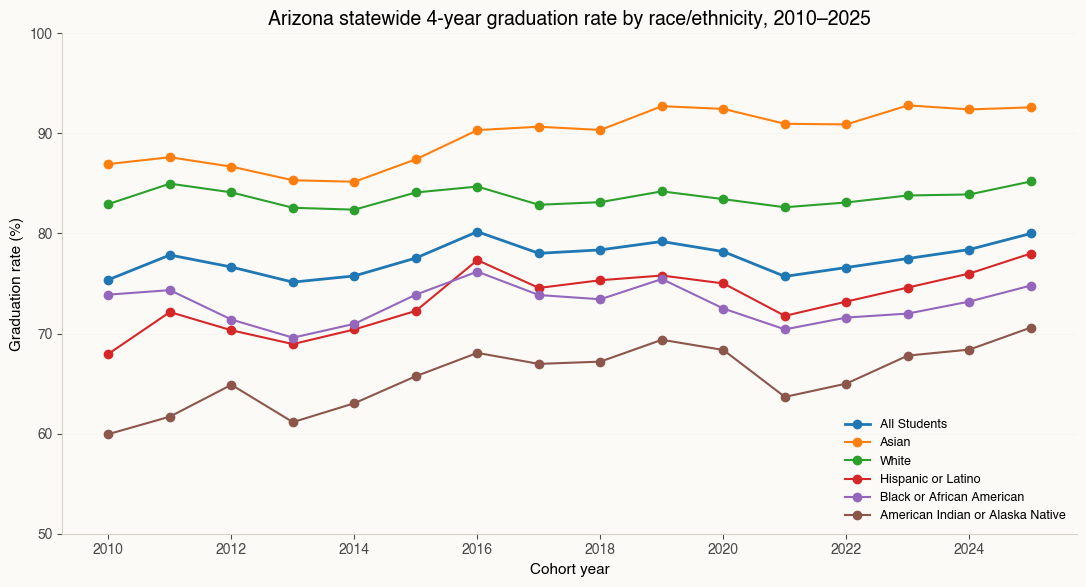

Saved chart 1


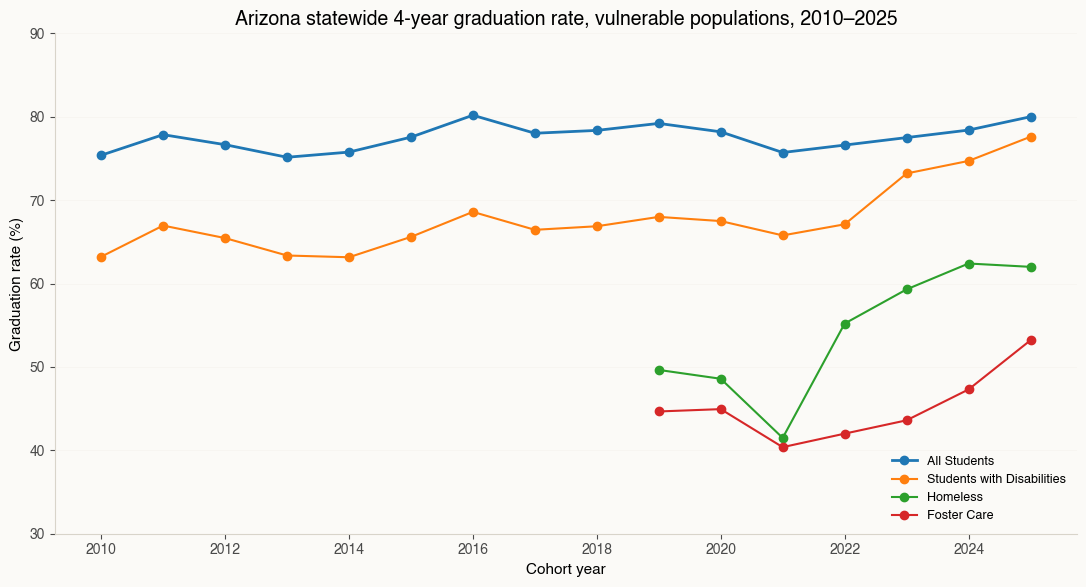

Saved chart 2


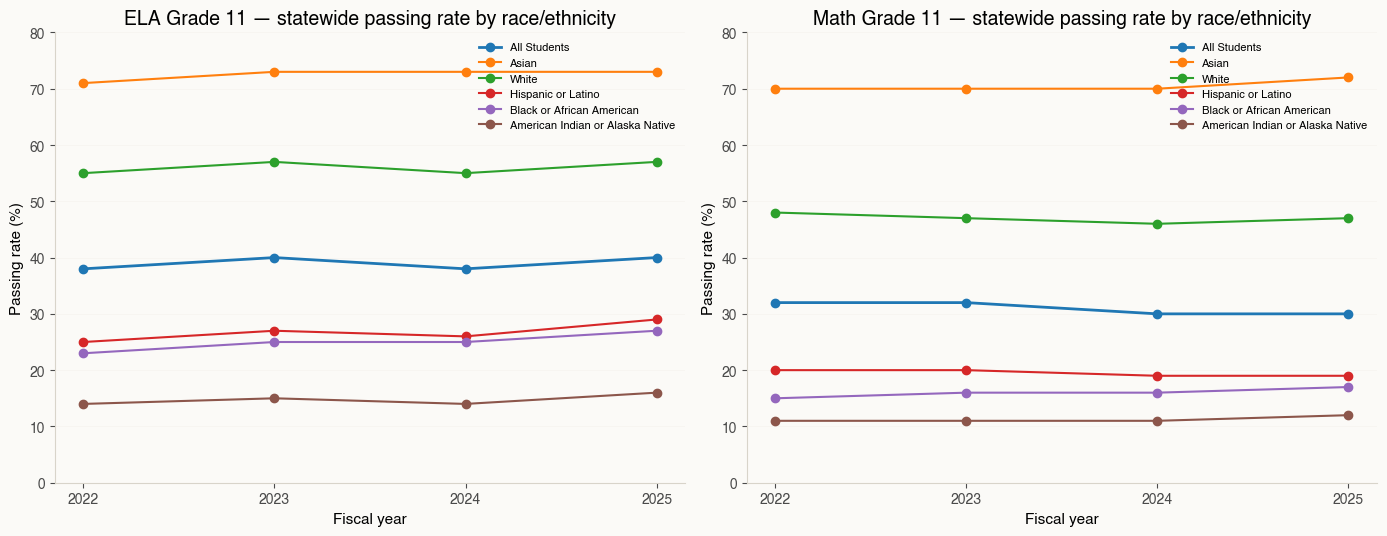

Saved chart 3


In [51]:
import matplotlib.pyplot as plt
from pathlib import Path

ARTICLE1_DIR = Path('findings/article-1-diploma-vs-skills')

# Chart 1: Statewide grad rate by race/ethnicity, 2010-2025
race_subgroups = [
    'All Students', 'Asian', 'White', 
    'Hispanic or Latino', 'Black or African American', 
    'American Indian or Alaska Native',
]

fig, ax = plt.subplots(figsize=(11, 6))
for sg in race_subgroups:
    if sg in state_grad_pivot.columns:
        series = state_grad_pivot[sg]
        ax.plot(series.index, series.values, marker='o', label=sg, 
                linewidth=2 if sg == 'All Students' else 1.5)

ax.set_title('Arizona statewide 4-year graduation rate by race/ethnicity, 2010–2025')
ax.set_xlabel('Cohort year')
ax.set_ylabel('Graduation rate (%)')
ax.set_ylim(50, 100)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTICLE1_DIR / 'chart-1-statewide-grad-by-race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart 1")

# Chart 2: Statewide grad rate, vulnerable populations
vulnerable_subgroups = ['All Students', 'Students with Disabilities', 'Homeless', 'Foster Care']

fig, ax = plt.subplots(figsize=(11, 6))
for sg in vulnerable_subgroups:
    if sg in state_grad_pivot.columns:
        series = state_grad_pivot[sg].dropna()
        ax.plot(series.index, series.values, marker='o', label=sg, 
                linewidth=2 if sg == 'All Students' else 1.5)

ax.set_title('Arizona statewide 4-year graduation rate, vulnerable populations, 2010–2025')
ax.set_xlabel('Cohort year')
ax.set_ylabel('Graduation rate (%)')
ax.set_ylim(30, 90)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTICLE1_DIR / 'chart-2-statewide-grad-vulnerable.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart 2")

# Chart 3: Statewide test scores by race, ELA + Math side by side
race_test_subgroups = ['All Students', 'Asian', 'White', 'Hispanic or Latino', 
                        'Black or African American', 'American Indian or Alaska Native']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, pivot, title in [(axes[0], ela_pivot, 'ELA Grade 11'), (axes[1], math_pivot, 'Math Grade 11')]:
    for sg in race_test_subgroups:
        if sg in pivot.columns:
            series = pivot[sg].dropna()
            ax.plot(series.index, series.values, marker='o', label=sg, 
                    linewidth=2 if sg == 'All Students' else 1.5)
    ax.set_title(f'{title} — statewide passing rate by race/ethnicity')
    ax.set_xlabel('Fiscal year')
    ax.set_ylabel('Passing rate (%)')
    ax.set_ylim(0, 80)
    ax.set_xticks([2022, 2023, 2024, 2025])
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(ARTICLE1_DIR / 'chart-3-statewide-tests-by-race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart 3")

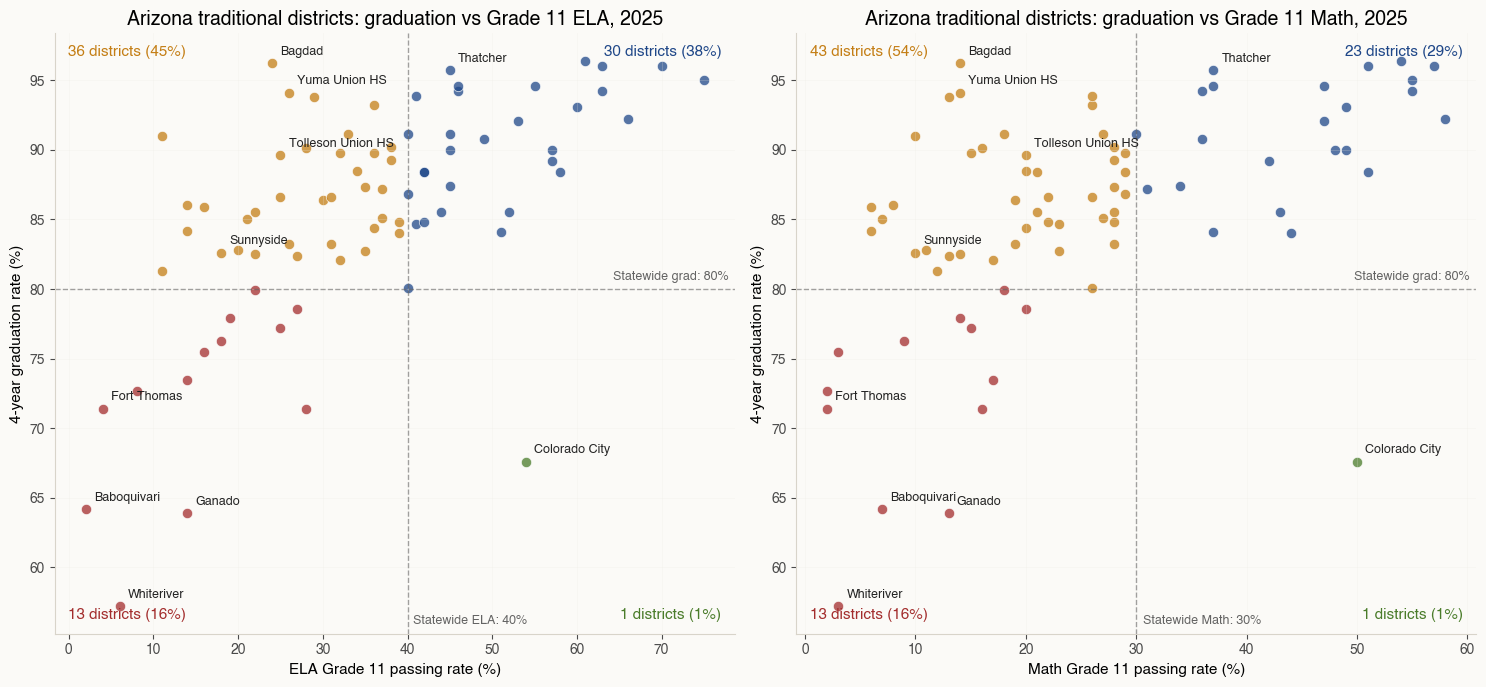

Saved chart 4


In [53]:
# Chart 4: The headline scatter — graduation rate vs test passing rate, with quadrant colors

QUAD_COLORS = {
    'high_grad_high_test': '#1f4788',
    'high_grad_low_test':  '#c47e15',
    'low_grad_high_test':  '#4a7c2a',
    'low_grad_low_test':   '#a32d2d',
}

statewide_grad_2025 = 80.0

LABEL_DISTRICTS = {
    'Bagdad Unified District',
    'Colorado City Unified District',
    'Whiteriver Unified District',
    'Baboquivari Unified School District #40',
    'Ganado Unified School District',
    'Fort Thomas Unified District',
    'Thatcher Unified District',
    'Yuma Union High School District',
    'Tolleson Union High School District',
    'Sunnyside Unified District',
}

def classify(grad, test, test_ref):
    high_grad = grad >= statewide_grad_2025
    high_test = test >= test_ref
    if high_grad and high_test: return 'high_grad_high_test'
    if high_grad and not high_test: return 'high_grad_low_test'
    if not high_grad and high_test: return 'low_grad_high_test'
    return 'low_grad_low_test'

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, x_col, x_ref, x_label, subject_short in [
    (axes[0], 'ela_passing', 40, 'ELA Grade 11 passing rate (%)', 'ELA'),
    (axes[1], 'math_passing', 30, 'Math Grade 11 passing rate (%)', 'Math'),
]:
    df = scatter_2025.copy()
    df['quad'] = df.apply(lambda r: classify(r['grad_rate'], r[x_col], x_ref), axis=1)
    
    for quad, color in QUAD_COLORS.items():
        sub = df[df['quad'] == quad]
        ax.scatter(sub[x_col], sub['grad_rate'], s=55, alpha=0.75,
                   color=color, edgecolor='white', linewidth=0.6)
    
    ax.axvline(x_ref, color='#4a4a4a', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(statewide_grad_2025, color='#4a4a4a', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.text(x_ref + 0.6, ax.get_ylim()[0] + 0.5, f'Statewide {subject_short}: {x_ref}%',
            fontsize=9, color='#4a4a4a', alpha=0.85, va='bottom', ha='left')
    ax.text(ax.get_xlim()[1] * 0.99, statewide_grad_2025 + 0.4, 'Statewide grad: 80%',
            fontsize=9, color='#4a4a4a', alpha=0.85, ha='right', va='bottom')
    
    for _, row in df.iterrows():
        if row['lea_name'] in LABEL_DISTRICTS:
            x = row[x_col]
            y = row['grad_rate']
            label = row['lea_name'].replace(' Unified School District', '').replace(' Unified District', '').replace(' #40', '').replace(' High School District', ' HS')
            ax.annotate(label, (x, y), xytext=(6, 6), textcoords='offset points',
                       fontsize=9, color='#1a1a1a', alpha=0.95)
    
    counts = df['quad'].value_counts()
    n_total = len(df)
    quad_count_text = {
        'high_grad_high_test': (0.98, 0.98, 'right', 'top'),
        'high_grad_low_test':  (0.02, 0.98, 'left', 'top'),
        'low_grad_high_test':  (0.98, 0.02, 'right', 'bottom'),
        'low_grad_low_test':   (0.02, 0.02, 'left', 'bottom'),
    }
    for quad, (xpos, ypos, ha, va) in quad_count_text.items():
        n = counts.get(quad, 0)
        pct = 100 * n / n_total
        ax.text(xpos, ypos, f'{n} districts ({pct:.0f}%)', transform=ax.transAxes,
                ha=ha, va=va, fontsize=11, color=QUAD_COLORS[quad], fontweight=600)
    
    ax.set_xlabel(x_label)
    ax.set_ylabel('4-year graduation rate (%)')
    ax.set_title(f'Arizona traditional districts: graduation vs Grade 11 {subject_short}, 2025')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(ARTICLE1_DIR / 'chart-4-quadrant-scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart 4")

Yuma Union, 2025 — subgroup breakdown:
                        subgroup  grad  cohort  ela  math
                    All Students  94.1  2693.0 26.0  14.0
                           White  87.2   281.0 41.0  23.0
              Hispanic or Latino  95.1  2314.0 24.0  13.0
       Black or African American  96.3     NaN 23.0   4.0
American Indian or Alaska Native  80.0     NaN 12.0   6.0
                           Asian   NaN     NaN 57.0  40.0


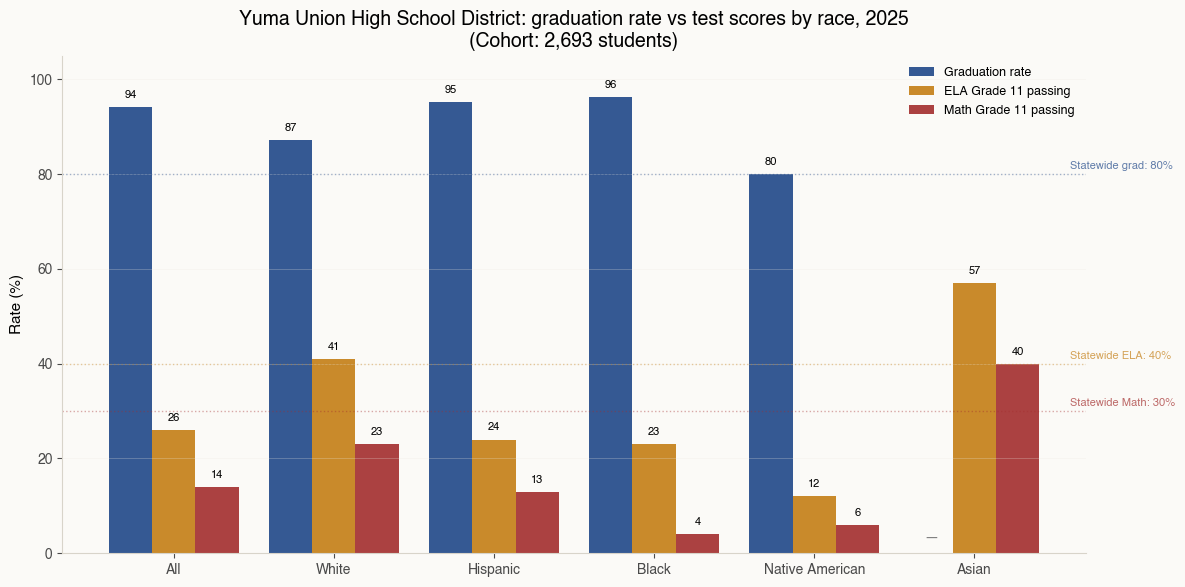

Saved chart 5


In [54]:
# Chart 5: Yuma Union deep-dive — graduation rate vs test scores by racial subgroup
# Shows how the diploma-vs-skills gap plays out within ONE outlier district across racial lines

YUMA_LEA_ID = 4507

# Pull subgroup data for Yuma Union, 2025
yuma_grad = districts_grad[
    (districts_grad['lea_id'] == YUMA_LEA_ID) 
    & (districts_grad['cohort_year'] == 2025)
    & (districts_grad['subgroup'].isin(['All Students', 'White', 'Hispanic or Latino', 
                                          'Black or African American', 'American Indian or Alaska Native', 'Asian']))
][['subgroup', 'grad_rate', 'n_cohort']]

yuma_test = test_districts[
    (test_districts['lea_id'] == YUMA_LEA_ID)
    & (test_districts['fiscal_year'] == 2025)
    & (test_districts['test_level'].isin(['ELA Grade 11', 'Math Grade 11']))
    & (test_districts['subgroup'].isin(['All Students', 'White', 'Hispanic or Latino',
                                          'Black or African American', 'American Indian or Alaska Native', 'Asian']))
][['subgroup', 'subject', 'pct_passing']]

# Build a combined view
yuma_data = []
for sg in ['All Students', 'White', 'Hispanic or Latino', 'Black or African American', 
           'American Indian or Alaska Native', 'Asian']:
    grad = yuma_grad[yuma_grad['subgroup'] == sg]['grad_rate'].iloc[0] if len(yuma_grad[yuma_grad['subgroup'] == sg]) > 0 else None
    cohort = yuma_grad[yuma_grad['subgroup'] == sg]['n_cohort'].iloc[0] if len(yuma_grad[yuma_grad['subgroup'] == sg]) > 0 else None
    ela_match = yuma_test[(yuma_test['subgroup'] == sg) & (yuma_test['subject'] == 'English Language Arts')]
    math_match = yuma_test[(yuma_test['subgroup'] == sg) & (yuma_test['subject'] == 'Mathematics')]
    ela = ela_match['pct_passing'].iloc[0] if len(ela_match) > 0 else None
    math = math_match['pct_passing'].iloc[0] if len(math_match) > 0 else None
    yuma_data.append({'subgroup': sg, 'grad': grad, 'cohort': cohort, 'ela': ela, 'math': math})

yuma_df = pd.DataFrame(yuma_data)
print("Yuma Union, 2025 — subgroup breakdown:")
print(yuma_df.to_string(index=False))

# Build the chart: grouped bar chart, three bars per subgroup (grad, ela, math)
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

subgroups = yuma_df['subgroup'].tolist()
n = len(subgroups)
x = np.arange(n)
width = 0.27

# Plot bars (where data exists)
grad_vals = yuma_df['grad'].fillna(0).tolist()
ela_vals = yuma_df['ela'].fillna(0).tolist()
math_vals = yuma_df['math'].fillna(0).tolist()

bars1 = ax.bar(x - width, grad_vals, width, label='Graduation rate', color='#1f4788', alpha=0.9)
bars2 = ax.bar(x, ela_vals, width, label='ELA Grade 11 passing', color='#c47e15', alpha=0.9)
bars3 = ax.bar(x + width, math_vals, width, label='Math Grade 11 passing', color='#a32d2d', alpha=0.9)

# Annotate values on top of bars
for bars, vals in [(bars1, grad_vals), (bars2, ela_vals), (bars3, math_vals)]:
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f'{val:.0f}', 
                    ha='center', va='bottom', fontsize=8)

# Suppression labels (where the bars are zero / NaN)
for i, row in yuma_df.iterrows():
    for offset, val in [(- width, row['grad']), (0, row['ela']), (width, row['math'])]:
        if pd.isna(val):
            ax.text(i + offset, 1.5, '—', ha='center', va='bottom', fontsize=10, color='gray')

# Statewide reference lines
ax.axhline(80.0, color='#1f4788', linestyle=':', linewidth=1, alpha=0.4)
ax.axhline(40.0, color='#c47e15', linestyle=':', linewidth=1, alpha=0.4)
ax.axhline(30.0, color='#a32d2d', linestyle=':', linewidth=1, alpha=0.4)

ax.text(n - 0.4, 81, 'Statewide grad: 80%', fontsize=8, color='#1f4788', alpha=0.7)
ax.text(n - 0.4, 41, 'Statewide ELA: 40%', fontsize=8, color='#c47e15', alpha=0.7)
ax.text(n - 0.4, 31, 'Statewide Math: 30%', fontsize=8, color='#a32d2d', alpha=0.7)

# Labels
short_labels = [s.replace('American Indian or Alaska Native', 'Native American')
                 .replace('Black or African American', 'Black')
                 .replace('Hispanic or Latino', 'Hispanic')
                 .replace('All Students', 'All') for s in subgroups]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylabel('Rate (%)')
ax.set_ylim(0, 105)
ax.set_title('Yuma Union High School District: graduation rate vs test scores by race, 2025\n(Cohort: 2,693 students)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ARTICLE1_DIR / 'chart-5-outlier-deep-dive.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart 5")

Inverse-grad districts (12):
                               district_name  cohort_size_2025  white_grad_2025  hispanic_grad_2025  white_hisp_grad_gap
Santa Cruz Valley Union High School District             101.0             44.4                88.9                -44.5
                  Sunnyside Unified District            1117.0             66.7                84.9                -18.2
                    Safford Unified District             266.0             71.3                85.3                -14.0
                      Globe Unified District             133.0             79.2                92.3                -13.1
                 Wickenburg Unified District             125.0             77.9                90.0                -12.1
                   Coolidge Unified District             257.0             69.8                80.4                -10.6
              Parker Unified School District             134.0             84.0                94.6                -10.6
   

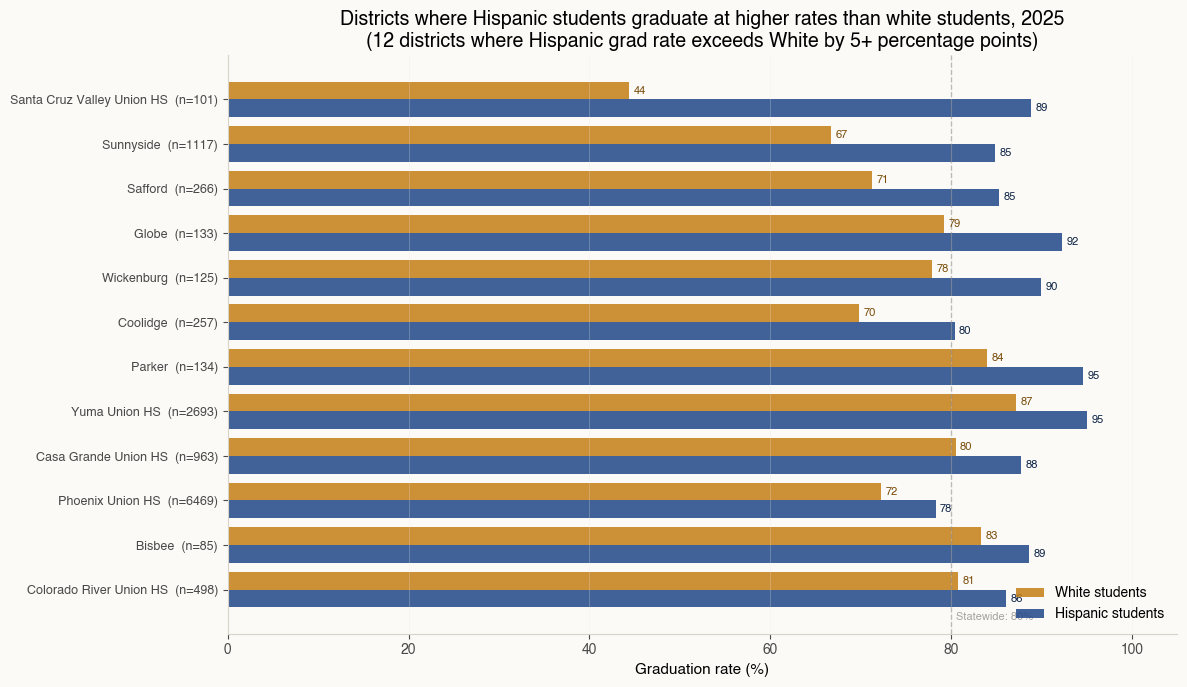

Saved chart 6


In [55]:
# Chart 6: The 12 inverse-grad-pattern districts — white grad rate vs Hispanic grad rate

# Pull from the master spreadsheet
inverse_districts = full_df[full_df['inverse_grad_strong']].sort_values('white_hisp_grad_gap')

print(f"Inverse-grad districts ({len(inverse_districts)}):")
print(inverse_districts[['district_name', 'cohort_size_2025', 'white_grad_2025', 'hispanic_grad_2025', 'white_hisp_grad_gap']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))

# Sort: most extreme gap first (most negative number)
y_pos = np.arange(len(inverse_districts))
short_names = [n.replace(' Unified School District', '')
                .replace(' Unified District', '')
                .replace(' High School District', ' HS')
                .replace(' #40', '') for n in inverse_districts['district_name']]

# Plot two bars per district: white grad, hispanic grad
bar_height = 0.4
ax.barh(y_pos - bar_height/2, inverse_districts['white_grad_2025'], bar_height, 
        label='White students', color='#c47e15', alpha=0.85)
ax.barh(y_pos + bar_height/2, inverse_districts['hispanic_grad_2025'], bar_height, 
        label='Hispanic students', color='#1f4788', alpha=0.85)

# Annotate bar values
for i, (_, row) in enumerate(inverse_districts.iterrows()):
    ax.text(row['white_grad_2025'] + 0.5, i - bar_height/2, f"{row['white_grad_2025']:.0f}", 
            va='center', fontsize=8, color='#7a4d0a')
    ax.text(row['hispanic_grad_2025'] + 0.5, i + bar_height/2, f"{row['hispanic_grad_2025']:.0f}", 
            va='center', fontsize=8, color='#0f2547')
    # Show cohort size on y-axis
    cohort = row['cohort_size_2025']
    cohort_str = f"  (n={cohort:.0f})" if pd.notna(cohort) else "  (n=?)"
    short_names[i] = short_names[i] + cohort_str

ax.set_yticks(y_pos)
ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel('Graduation rate (%)')
ax.set_xlim(0, 105)
ax.invert_yaxis()  # most extreme at top
ax.axvline(80.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text(80.5, len(inverse_districts) - 0.5, 'Statewide: 80%', fontsize=8, color='gray', alpha=0.7, va='top')
ax.set_title('Districts where Hispanic students graduate at higher rates than white students, 2025\n(12 districts where Hispanic grad rate exceeds White by 5+ percentage points)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(ARTICLE1_DIR / 'chart-6-inverse-grad-pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart 6")

In [56]:
# Generate data-with-tests.json for the new comparison tool
# Universe: 113 traditional districts; metrics: grad rate, ELA Grade 11, Math Grade 11
# Time window: 2022-2025

import json

OUT_DIR = Path('../docs-compare')
OUT_DIR.mkdir(exist_ok=True)

YEARS = [2022, 2023, 2024, 2025]

# Build statewide series
def build_statewide():
    stw_grad = {}
    stw_ela = {}
    stw_math = {}
    
    for y in YEARS:
        # Grad rate (from state grad subgroups)
        g = state_grad_subgroups[
            (state_grad_subgroups['cohort_year'] == y)
            & (state_grad_subgroups['subgroup'] == 'All Students')
        ]
        stw_grad[str(y)] = round(float(g.iloc[0]['grad_rate']), 1) if len(g) > 0 else None
        
        # Test scores (from state_test, school_type='All', All Students)
        ela = state_test[
            (state_test['fiscal_year'] == y)
            & (state_test['subgroup'] == 'All Students')
            & (state_test['school_type'] == 'All')
            & (state_test['test_level'] == 'ELA Grade 11')
        ]
        stw_ela[str(y)] = round(float(ela.iloc[0]['pct_passing']), 1) if len(ela) > 0 else None
        
        math = state_test[
            (state_test['fiscal_year'] == y)
            & (state_test['subgroup'] == 'All Students')
            & (state_test['school_type'] == 'All')
            & (state_test['test_level'] == 'Math Grade 11')
        ]
        stw_math[str(y)] = round(float(math.iloc[0]['pct_passing']), 1) if len(math) > 0 else None
    
    return {
        'grad_rate': stw_grad,
        'ela_passing': stw_ela,
        'math_passing': stw_math,
    }

# Build per-district series — only traditional districts
def build_districts():
    districts_out = []
    
    for lid in sorted(trad_ids):
        # Get district name and county from grad data (most authoritative)
        name_row = districts_grad[
            (districts_grad['lea_id'] == lid)
            & (districts_grad['subgroup'] == 'All Students')
        ]
        if len(name_row) == 0:
            continue  # No data at all for this LEA
        
        name = name_row.iloc[0]['lea_name']
        county_match = trad[trad['lea_id'] == lid]
        county = county_match.iloc[0]['county'] if len(county_match) > 0 and 'county' in county_match.columns else None
        if isinstance(county, str):
            county = county.replace(' County', '')
        
        # Build per-year metrics
        grad_rate = {}
        ela_passing = {}
        math_passing = {}
        
        for y in YEARS:
            g = districts_grad[
                (districts_grad['lea_id'] == lid)
                & (districts_grad['cohort_year'] == y)
                & (districts_grad['subgroup'] == 'All Students')
            ]
            grad_rate[str(y)] = round(float(g.iloc[0]['grad_rate']), 1) if len(g) > 0 and pd.notna(g.iloc[0]['grad_rate']) else None
            
            ela = test_districts[
                (test_districts['lea_id'] == lid)
                & (test_districts['fiscal_year'] == y)
                & (test_districts['subgroup'] == 'All Students')
                & (test_districts['test_level'] == 'ELA Grade 11')
            ]
            ela_passing[str(y)] = round(float(ela.iloc[0]['pct_passing']), 1) if len(ela) > 0 and pd.notna(ela.iloc[0]['pct_passing']) else None
            
            math = test_districts[
                (test_districts['lea_id'] == lid)
                & (test_districts['fiscal_year'] == y)
                & (test_districts['subgroup'] == 'All Students')
                & (test_districts['test_level'] == 'Math Grade 11')
            ]
            math_passing[str(y)] = round(float(math.iloc[0]['pct_passing']), 1) if len(math) > 0 and pd.notna(math.iloc[0]['pct_passing']) else None
        
        # Skip districts where ALL three metrics are entirely null
        has_any_data = any(v is not None for d in [grad_rate, ela_passing, math_passing] for v in d.values())
        if not has_any_data:
            continue
        
        districts_out.append({
            'id': int(lid),
            'name': name,
            'county': county,
            'grad_rate': grad_rate,
            'ela_passing': ela_passing,
            'math_passing': math_passing,
        })
    
    return districts_out

statewide_data = build_statewide()
districts_data = build_districts()

# Sort districts alphabetically for the search dropdown
districts_data.sort(key=lambda d: d['name'].lower())

output = {
    'years': YEARS,
    'statewide': statewide_data,
    'districts': districts_data,
    'metadata': {
        'time_window': '2022-2025',
        'analytical_universe': 'Arizona traditional school districts (NCES classification)',
        'metrics': {
            'grad_rate': '4-year cohort graduation rate, All Students',
            'ela_passing': 'AASA ELA Grade 11 passing rate, All Students',
            'math_passing': 'AASA Math Grade 11 passing rate, All Students',
        },
        'sources': 'Arizona Department of Education',
    }
}

# Write to disk
output_path = OUT_DIR / 'data-with-tests.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f"Wrote {output_path}")
print(f"  {len(districts_data)} districts")
print(f"  {sum(1 for d in districts_data if any(d['grad_rate'].values()))} have grad data")
print(f"  {sum(1 for d in districts_data if any(d['ela_passing'].values()))} have ELA data")
print(f"  {sum(1 for d in districts_data if any(d['math_passing'].values()))} have Math data")

# Sanity check the statewide data
print(f"\nStatewide data:")
print(f"  Grad rate: {statewide_data['grad_rate']}")
print(f"  ELA passing: {statewide_data['ela_passing']}")
print(f"  Math passing: {statewide_data['math_passing']}")

# File size
size_kb = output_path.stat().st_size / 1024
print(f"\nFile size: {size_kb:.1f} KB")

Wrote ../docs-compare/data-with-tests.json
  113 districts
  108 have grad data
  111 have ELA data
  110 have Math data

Statewide data:
  Grad rate: {'2022': 76.6, '2023': 77.5, '2024': 78.4, '2025': 80.0}
  ELA passing: {'2022': 38.0, '2023': 40.0, '2024': 38.0, '2025': 40.0}
  Math passing: {'2022': 32.0, '2023': 32.0, '2024': 30.0, '2025': 30.0}

File size: 51.4 KB


In [57]:
INDEX_HTML = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Arizona schools: graduation rate vs. test scores</title>
  <meta name="description" content="Compare each Arizona district's 4-year graduation rate against its Grade 11 ELA and Math passing rates, 2022–2025.">
  <link rel="preconnect" href="https://fonts.googleapis.com">
  <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
  <link href="https://fonts.googleapis.com/css2?family=Fraunces:opsz,wght,SOFT@9..144,400..700,0..100&family=Space+Grotesk:wght@400;500;600;700&display=swap" rel="stylesheet">
  <link rel="stylesheet" href="styles.css">
</head>
<body>
  <header class="site-header">
    <div class="header-inner">
      <h1>Diplomas vs. demonstrated skills</h1>
      <p class="deck">For each Arizona school district, compare the 4-year high school graduation rate against the share of 11th graders passing the state's English and Math assessments. Statewide averages shown as dashed reference lines.</p>
      <p class="nav-link"><a href="../">← Back to district graduation comparison tool</a></p>
    </div>
  </header>

  <main class="tool">
    <section class="controls">
      <div class="control-group">
        <label for="district-search" class="control-label">Pick a district</label>
        <div class="search-wrap">
          <input
            type="text"
            id="district-search"
            placeholder="Start typing a district name…"
            autocomplete="off"
            spellcheck="false"
          >
          <ul id="search-results" class="search-results" hidden></ul>
        </div>
      </div>

      <div class="control-group">
        <div class="control-label">Now showing</div>
        <div id="selected-info" class="selected-info">
          <p class="selected-empty">No district selected — search above to compare a district to the statewide average.</p>
        </div>
      </div>
    </section>

    <section class="legend-section">
      <div class="legend-grid">
        <div class="legend-row">
          <div class="legend-label">Graduation rate</div>
          <div class="legend-line legend-line-solid" style="--c:#1f4788"></div>
          <span class="legend-text">District</span>
          <div class="legend-line legend-line-dashed" style="--c:#1f4788"></div>
          <span class="legend-text">Statewide</span>
        </div>
        <div class="legend-row">
          <div class="legend-label">ELA Grade 11 passing</div>
          <div class="legend-line legend-line-solid" style="--c:#c47e15"></div>
          <span class="legend-text">District</span>
          <div class="legend-line legend-line-dashed" style="--c:#c47e15"></div>
          <span class="legend-text">Statewide</span>
        </div>
        <div class="legend-row">
          <div class="legend-label">Math Grade 11 passing</div>
          <div class="legend-line legend-line-solid" style="--c:#a32d2d"></div>
          <span class="legend-text">District</span>
          <div class="legend-line legend-line-dashed" style="--c:#a32d2d"></div>
          <span class="legend-text">Statewide</span>
        </div>
      </div>
    </section>

    <section class="chart-section">
      <div class="chart-wrap">
        <canvas id="chart" aria-label="Line chart of graduation and test scores over time"></canvas>
      </div>
      <p class="chart-note">Suppressed values (small populations) appear as gaps. Source: Arizona Department of Education, 4-Year Cohort Graduation Rate data and AASA Grade 11 assessment results.</p>
    </section>

    <section class="table-section">
      <div class="table-header">
        <h2>Data table</h2>
        <button id="download-csv" class="download-btn" type="button">Download CSV</button>
      </div>
      <div class="table-wrap">
        <table id="data-table">
          <!-- Populated by JS -->
        </table>
      </div>
    </section>
  </main>

  <footer class="site-footer">
    <div class="footer-inner">
      <p>Data from the <a href="https://www.azed.gov/accountability-research/data/">Arizona Department of Education Accountability Research office</a>. Graduation rate is the percentage of students in a four-year cohort who earned a high school diploma by August 31 of their fourth year. ELA and Math passing rates reflect the share of Grade 11 students scoring at or above the proficient level on the AASA assessment. Tool covers 113 traditional Arizona school districts. Methodology and source files available in the <a href="https://github.com/ewyloge-asu/az-grad-rates">project repository</a>.</p>
    </div>
  </footer>

  <script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>
  <script src="app.js"></script>
</body>
</html>
"""

(OUT_DIR / 'index.html').write_text(INDEX_HTML)
print(f"Wrote {OUT_DIR / 'index.html'}")

Wrote ../docs-compare/index.html


In [58]:
STYLES_CSS = """:root {
  --ink: #1a1a1a;
  --ink-soft: #4a4a4a;
  --ink-faded: #8a8a8a;
  --paper: #fbfaf7;
  --paper-alt: #f3f0ea;
  --rule: #d8d4ca;
  --accent: #a32d2d;

  /* Three metric colors — match Chart.js dataset colors in app.js */
  --c-grad: #1f4788;
  --c-ela:  #c47e15;
  --c-math: #a32d2d;

  --font-display: "Fraunces", Georgia, serif;
  --font-body: "Space Grotesk", -apple-system, system-ui, sans-serif;

  --max-w: 1100px;
}

* { box-sizing: border-box; }

html, body {
  margin: 0;
  padding: 0;
  background: var(--paper);
  color: var(--ink);
  font-family: var(--font-body);
  font-size: 16px;
  line-height: 1.55;
  -webkit-font-smoothing: antialiased;
}

a {
  color: var(--ink);
  text-decoration: underline;
  text-decoration-color: var(--rule);
  text-decoration-thickness: 1px;
  text-underline-offset: 3px;
  transition: text-decoration-color 120ms ease;
}
a:hover { text-decoration-color: var(--accent); }

/* ---------- Header ---------- */
.site-header {
  border-bottom: 1px solid var(--rule);
  background: var(--paper);
}
.header-inner {
  max-width: var(--max-w);
  margin: 0 auto;
  padding: 48px 24px 36px;
}
.site-header h1 {
  font-family: var(--font-display);
  font-weight: 500;
  font-size: clamp(30px, 4.5vw, 48px);
  line-height: 1.08;
  letter-spacing: -0.015em;
  margin: 0 0 16px;
  max-width: 22ch;
  font-variation-settings: "opsz" 96, "SOFT" 50;
}
.deck {
  font-family: var(--font-body);
  font-weight: 400;
  font-size: clamp(16px, 1.7vw, 19px);
  line-height: 1.55;
  color: var(--ink-soft);
  max-width: 62ch;
  margin: 0 0 16px;
  letter-spacing: -0.005em;
}
.nav-link {
  font-size: 13px;
  margin: 0;
  color: var(--ink-faded);
}
.nav-link a {
  color: var(--ink-soft);
}

/* ---------- Main / Controls ---------- */
.tool {
  max-width: var(--max-w);
  margin: 0 auto;
  padding: 32px 24px 64px;
}

.controls {
  display: grid;
  grid-template-columns: minmax(280px, 420px) 1fr;
  gap: 32px;
  margin-bottom: 28px;
  padding-bottom: 28px;
  border-bottom: 1px solid var(--rule);
}
@media (max-width: 700px) {
  .controls { grid-template-columns: 1fr; gap: 20px; }
}

.control-label {
  font-family: var(--font-body);
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.12em;
  text-transform: uppercase;
  color: var(--ink-faded);
  margin-bottom: 10px;
  display: block;
}

/* Search input — same as v1 */
.search-wrap {
  position: relative;
}
#district-search {
  width: 100%;
  font-family: var(--font-body);
  font-size: 16px;
  padding: 12px 14px;
  border: 1px solid var(--rule);
  border-radius: 2px;
  background: #fff;
  color: var(--ink);
  transition: border-color 120ms ease;
}
#district-search:focus {
  outline: none;
  border-color: var(--ink);
}
#district-search::placeholder {
  color: var(--ink-faded);
}

.search-results {
  position: absolute;
  top: calc(100% - 1px);
  left: 0;
  right: 0;
  max-height: 280px;
  overflow-y: auto;
  margin: 0;
  padding: 0;
  list-style: none;
  background: #fff;
  border: 1px solid var(--ink);
  border-top: none;
  z-index: 10;
  box-shadow: 0 12px 24px rgba(0,0,0,0.08);
}
.search-results li {
  padding: 10px 14px;
  cursor: pointer;
  font-size: 14px;
  border-bottom: 1px solid var(--paper-alt);
  line-height: 1.35;
}
.search-results li:last-child { border-bottom: none; }
.search-results li:hover,
.search-results li.highlighted {
  background: var(--paper-alt);
}
.search-results .result-sub {
  display: block;
  font-size: 12px;
  color: var(--ink-faded);
  margin-top: 2px;
}
.search-results .no-results {
  color: var(--ink-faded);
  font-style: italic;
  cursor: default;
}

/* Selected district info card */
.selected-info {
  min-height: 44px;
}
.selected-empty {
  color: var(--ink-faded);
  font-size: 13px;
  font-style: italic;
  margin: 0;
}
.selected-card {
  display: flex;
  align-items: center;
  justify-content: space-between;
  gap: 16px;
  padding: 14px 16px;
  background: #fff;
  border: 1px solid var(--ink);
  border-radius: 2px;
}
.selected-name {
  font-family: var(--font-display);
  font-weight: 500;
  font-size: 18px;
  letter-spacing: -0.01em;
  font-variation-settings: "opsz" 36, "SOFT" 50;
  margin: 0;
}
.selected-meta {
  font-size: 12px;
  color: var(--ink-faded);
  margin: 2px 0 0;
}
.selected-clear {
  font-family: var(--font-body);
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.1em;
  text-transform: uppercase;
  background: none;
  border: 1px solid var(--rule);
  color: var(--ink-soft);
  padding: 6px 12px;
  cursor: pointer;
  border-radius: 2px;
  transition: border-color 120ms ease, color 120ms ease;
  flex-shrink: 0;
}
.selected-clear:hover {
  border-color: var(--accent);
  color: var(--accent);
}

/* ---------- Legend ---------- */
.legend-section {
  margin-bottom: 24px;
  padding: 16px 18px;
  background: var(--paper-alt);
  border: 1px solid var(--rule);
  border-radius: 2px;
}
.legend-grid {
  display: grid;
  gap: 8px;
}
.legend-row {
  display: flex;
  align-items: center;
  gap: 12px;
  flex-wrap: wrap;
  font-size: 13px;
}
.legend-label {
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.1em;
  text-transform: uppercase;
  color: var(--ink-soft);
  width: 200px;
  flex-shrink: 0;
}
@media (max-width: 700px) {
  .legend-label { width: 100%; }
}
.legend-line {
  width: 32px;
  height: 2.5px;
  background: var(--c);
  flex-shrink: 0;
}
.legend-line-dashed {
  background: none;
  border-top: 2.5px dashed var(--c);
  height: 0;
}
.legend-text {
  font-size: 13px;
  color: var(--ink-soft);
  margin-right: 8px;
}

/* ---------- Chart ---------- */
.chart-section {
  margin-bottom: 40px;
}
.chart-wrap {
  position: relative;
  height: 480px;
  background: #fff;
  border: 1px solid var(--rule);
  padding: 20px 16px 16px;
}
@media (max-width: 700px) {
  .chart-wrap { height: 380px; padding: 12px 8px; }
}
.chart-note {
  font-size: 12px;
  color: var(--ink-faded);
  margin: 12px 0 0;
  line-height: 1.5;
  max-width: 72ch;
}

/* ---------- Table ---------- */
.table-section {
  padding-top: 32px;
  border-top: 1px solid var(--rule);
}
.table-header {
  display: flex;
  justify-content: space-between;
  align-items: baseline;
  margin-bottom: 16px;
  gap: 16px;
  flex-wrap: wrap;
}
.table-header h2 {
  font-family: var(--font-display);
  font-weight: 500;
  font-size: 24px;
  margin: 0;
  letter-spacing: -0.01em;
  font-variation-settings: "opsz" 48, "SOFT" 50;
}
.download-btn {
  font-family: var(--font-body);
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.12em;
  text-transform: uppercase;
  padding: 8px 14px;
  border: 1px solid var(--ink);
  background: transparent;
  color: var(--ink);
  cursor: pointer;
  transition: background 120ms ease, color 120ms ease;
}
.download-btn:hover {
  background: var(--ink);
  color: var(--paper);
}
.download-btn:disabled {
  opacity: 0.4;
  cursor: not-allowed;
}

.table-wrap {
  overflow-x: auto;
  border: 1px solid var(--rule);
  background: #fff;
}
#data-table {
  width: 100%;
  border-collapse: collapse;
  font-size: 14px;
  font-variant-numeric: tabular-nums;
}
#data-table thead th {
  background: var(--paper-alt);
  text-align: right;
  padding: 10px 12px;
  font-weight: 500;
  color: var(--ink-soft);
  border-bottom: 1px solid var(--rule);
  white-space: nowrap;
  font-size: 13px;
}
#data-table thead th:first-child {
  text-align: left;
  min-width: 180px;
}
#data-table tbody td {
  padding: 10px 12px;
  text-align: right;
  border-bottom: 1px solid var(--paper-alt);
}
#data-table tbody td:first-child {
  text-align: left;
  font-weight: 500;
}
#data-table tbody tr:last-child td { border-bottom: none; }
#data-table td.suppressed {
  color: var(--ink-faded);
}
#data-table tr.row-section {
  background: var(--paper-alt);
}
#data-table tr.row-section td {
  font-family: var(--font-body);
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.1em;
  text-transform: uppercase;
  color: var(--ink-faded);
  padding: 8px 12px;
  border-bottom: 1px solid var(--rule);
}
.row-swatch {
  display: inline-block;
  width: 8px;
  height: 8px;
  border-radius: 50%;
  margin-right: 10px;
  vertical-align: baseline;
  transform: translateY(-1px);
}
.row-swatch.dashed {
  background: none !important;
  border: 1.5px dashed currentColor;
  border-radius: 0;
  width: 12px;
  height: 0;
  vertical-align: middle;
  transform: translateY(-3px);
}
.table-empty {
  padding: 32px;
  text-align: center;
  color: var(--ink-faded);
  font-style: italic;
}

/* ---------- Footer ---------- */
.site-footer {
  border-top: 1px solid var(--rule);
  background: var(--paper-alt);
  margin-top: 64px;
}
.footer-inner {
  max-width: var(--max-w);
  margin: 0 auto;
  padding: 32px 24px;
  font-size: 13px;
  color: var(--ink-soft);
  line-height: 1.6;
}
.footer-inner p { margin: 0; max-width: 72ch; }
"""

(OUT_DIR / 'styles.css').write_text(STYLES_CSS)
print(f"Wrote {OUT_DIR / 'styles.css'}: {len(STYLES_CSS):,} chars")

Wrote ../docs-compare/styles.css: 8,793 chars


In [59]:
APP_JS = """// Arizona Schools: Diplomas vs. Demonstrated Skills (Comparison Tool)
// Vanilla JS — loads data-with-tests.json, renders Chart.js with 6 lines, single-district selection

(function () {
  'use strict';

  const COLORS = {
    grad: '#1f4788',
    ela:  '#c47e15',
    math: '#a32d2d',
  };

  const METRIC_LABELS = {
    grad_rate:    'Graduation rate',
    ela_passing:  'ELA Grade 11 passing',
    math_passing: 'Math Grade 11 passing',
  };

  const state = {
    data: null,
    years: [],
    selectedDistrictId: null,
    searchHighlightIdx: -1,
  };

  let chart = null;

  // ---------- Bootstrapping ----------
  async function init() {
    try {
      const resp = await fetch('data-with-tests.json');
      if (!resp.ok) throw new Error(`HTTP ${resp.status}`);
      state.data = await resp.json();
      state.years = state.data.years;
    } catch (err) {
      document.querySelector('.tool').innerHTML =
        `<p style="color: #a32d2d;">Could not load data: ${err.message}</p>`;
      return;
    }

    buildChart();
    renderSelected();
    renderTable();
    wireSearch();
    wireDownload();
  }

  // ---------- Chart ----------
  function buildChart() {
    const ctx = document.getElementById('chart').getContext('2d');
    chart = new Chart(ctx, {
      type: 'line',
      data: { labels: state.years, datasets: [] },
      options: {
        responsive: true,
        maintainAspectRatio: false,
        interaction: { mode: 'index', intersect: false },
        plugins: {
          legend: { display: false },
          tooltip: {
            backgroundColor: '#1a1a1a',
            titleFont: { family: "'Space Grotesk', sans-serif", size: 12, weight: '600' },
            bodyFont: { family: "'Space Grotesk', sans-serif", size: 13 },
            padding: 12,
            displayColors: true,
            boxWidth: 10,
            boxHeight: 10,
            callbacks: {
              title: (items) => items[0].label,
              label: (ctx) => {
                const v = ctx.parsed.y;
                return `  ${ctx.dataset.label}: ${v == null ? '—' : v.toFixed(1) + '%'}`;
              },
            },
          },
        },
        scales: {
          x: {
            grid: { display: false, color: '#d8d4ca' },
            ticks: {
              font: { family: "'Space Grotesk', sans-serif", size: 12 },
              color: '#4a4a4a',
              maxRotation: 0,
            },
          },
          y: {
            beginAtZero: true,
            suggestedMax: 100,
            grid: { color: '#ece9e1' },
            ticks: {
              font: { family: "'Space Grotesk', sans-serif", size: 12 },
              color: '#4a4a4a',
              callback: (v) => v + '%',
            },
          },
        },
        elements: {
          line: { tension: 0.15, borderWidth: 2 },
          point: { radius: 3, hoverRadius: 5, borderWidth: 1.5, backgroundColor: '#fff' },
        },
      },
    });
    updateChart();
  }

  function buildDataset(metricKey, color, isStatewide) {
    const series = isStatewide
      ? state.data.statewide[metricKey]
      : (findDistrict(state.selectedDistrictId) || {})[metricKey];
    if (!series) return null;
    const data = state.years.map((y) => {
      const v = series[String(y)];
      return v == null ? null : v;
    });
    const districtName = !isStatewide && state.selectedDistrictId
      ? findDistrict(state.selectedDistrictId).name
      : null;
    const label = isStatewide
      ? `Statewide ${METRIC_LABELS[metricKey].toLowerCase()}`
      : `${districtName} — ${METRIC_LABELS[metricKey].toLowerCase()}`;
    return {
      label,
      data,
      borderColor: color,
      pointBackgroundColor: '#fff',
      pointBorderColor: color,
      borderDash: isStatewide ? [6, 4] : [],
      borderWidth: isStatewide ? 2 : 2.5,
      pointRadius: isStatewide ? 2.5 : 4,
      spanGaps: false,
    };
  }

  function updateChart() {
    if (!chart) return;
    const datasets = [];
    // Statewide reference lines (dashed) — always shown
    for (const [metricKey, color] of [['grad_rate', COLORS.grad], ['ela_passing', COLORS.ela], ['math_passing', COLORS.math]]) {
      const ds = buildDataset(metricKey, color, true);
      if (ds) datasets.push(ds);
    }
    // District lines (solid) — only if a district is selected
    if (state.selectedDistrictId) {
      for (const [metricKey, color] of [['grad_rate', COLORS.grad], ['ela_passing', COLORS.ela], ['math_passing', COLORS.math]]) {
        const ds = buildDataset(metricKey, color, false);
        if (ds) datasets.push(ds);
      }
    }
    chart.data.datasets = datasets;
    chart.update();
  }

  // ---------- Search ----------
  function wireSearch() {
    const input = document.getElementById('district-search');
    const results = document.getElementById('search-results');

    input.addEventListener('input', () => {
      const q = input.value.trim().toLowerCase();
      if (q.length < 1) { results.hidden = true; return; }
      const matches = state.data.districts
        .filter((d) => d.name.toLowerCase().includes(q))
        .slice(0, 50);
      renderSearchResults(matches);
    });

    input.addEventListener('keydown', (e) => {
      const items = Array.from(results.querySelectorAll('li[data-id]'));
      if (e.key === 'ArrowDown') {
        e.preventDefault();
        state.searchHighlightIdx = Math.min(state.searchHighlightIdx + 1, items.length - 1);
        highlightSearchItem(items);
      } else if (e.key === 'ArrowUp') {
        e.preventDefault();
        state.searchHighlightIdx = Math.max(state.searchHighlightIdx - 1, 0);
        highlightSearchItem(items);
      } else if (e.key === 'Enter') {
        e.preventDefault();
        const el = items[state.searchHighlightIdx];
        if (el) selectDistrict(parseInt(el.dataset.id, 10));
      } else if (e.key === 'Escape') {
        results.hidden = true;
        input.blur();
      }
    });

    document.addEventListener('click', (e) => {
      if (!e.target.closest('.search-wrap')) results.hidden = true;
    });
  }

  function renderSearchResults(matches) {
    const results = document.getElementById('search-results');
    state.searchHighlightIdx = -1;
    if (matches.length === 0) {
      results.innerHTML = '<li class="no-results">No districts match</li>';
      results.hidden = false;
      return;
    }
    const nameCounts = new Map();
    state.data.districts.forEach(d => {
      nameCounts.set(d.name, (nameCounts.get(d.name) || 0) + 1);
    });
    results.innerHTML = matches.map((d) => {
      const isDupe = nameCounts.get(d.name) > 1;
      const subtitle = isDupe || d.county
        ? `<span class="result-sub">${escapeHtml(d.county || '—')} County · ID ${d.id}</span>`
        : '';
      return `<li data-id="${d.id}">
        <span>${escapeHtml(d.name)}</span>
        ${subtitle}
      </li>`;
    }).join('');
    results.querySelectorAll('li[data-id]').forEach((li) => {
      li.addEventListener('click', () => selectDistrict(parseInt(li.dataset.id, 10)));
    });
    results.hidden = false;
  }

  function highlightSearchItem(items) {
    items.forEach((el, i) => el.classList.toggle('highlighted', i === state.searchHighlightIdx));
    const el = items[state.searchHighlightIdx];
    if (el) el.scrollIntoView({ block: 'nearest' });
  }

  // ---------- Selection ----------
  function selectDistrict(id) {
    state.selectedDistrictId = id;
    document.getElementById('district-search').value = '';
    document.getElementById('search-results').hidden = true;
    renderAll();
  }

  function clearSelection() {
    state.selectedDistrictId = null;
    renderAll();
  }

  // ---------- Selected info card ----------
  function renderSelected() {
    const container = document.getElementById('selected-info');
    if (!state.selectedDistrictId) {
      container.innerHTML = '<p class="selected-empty">No district selected — search above to compare a district to the statewide average.</p>';
      return;
    }
    const d = findDistrict(state.selectedDistrictId);
    if (!d) return;
    const meta = [d.county ? `${d.county} County` : null, `LEA ${d.id}`].filter(Boolean).join(' · ');
    container.innerHTML = `
      <div class="selected-card">
        <div>
          <h3 class="selected-name">${escapeHtml(d.name)}</h3>
          <p class="selected-meta">${escapeHtml(meta)}</p>
        </div>
        <button type="button" class="selected-clear" onclick="window.__clearSelection()">Clear</button>
      </div>
    `;
  }
  // Expose to global for the inline onclick — keeping the handler simple
  window.__clearSelection = clearSelection;

  // ---------- Table ----------
  function renderTable() {
    const table = document.getElementById('data-table');
    const downloadBtn = document.getElementById('download-csv');

    const yearHeaders = state.years.map((y) => `<th>${y}</th>`).join('');
    let rows = '';

    // Build rows in metric-grouped sections: Graduation rate, ELA, Math
    for (const [metricKey, color] of [['grad_rate', COLORS.grad], ['ela_passing', COLORS.ela], ['math_passing', COLORS.math]]) {
      rows += `<tr class="row-section"><td colspan="${state.years.length + 1}">${METRIC_LABELS[metricKey]}</td></tr>`;
      // Statewide row (dashed)
      const stwSeries = state.data.statewide[metricKey];
      const stwCells = state.years.map((y) => {
        const v = stwSeries[String(y)];
        return v == null ? '<td class="suppressed">—</td>' : `<td>${v.toFixed(1)}</td>`;
      }).join('');
      rows += `<tr>
        <td><span class="row-swatch dashed" style="color:${color}"></span>Statewide average</td>
        ${stwCells}
      </tr>`;
      // District row (if selected)
      if (state.selectedDistrictId) {
        const d = findDistrict(state.selectedDistrictId);
        if (d) {
          const dSeries = d[metricKey];
          const dCells = state.years.map((y) => {
            const v = dSeries[String(y)];
            return v == null ? '<td class="suppressed">—</td>' : `<td>${v.toFixed(1)}</td>`;
          }).join('');
          rows += `<tr>
            <td><span class="row-swatch" style="background:${color}"></span>${escapeHtml(d.name)}</td>
            ${dCells}
          </tr>`;
        }
      }
    }

    table.innerHTML = `
      <thead><tr><th>Series</th>${yearHeaders}</tr></thead>
      <tbody>${rows}</tbody>
    `;
    downloadBtn.disabled = false;
  }

  // ---------- CSV Download ----------
  function wireDownload() {
    document.getElementById('download-csv').addEventListener('click', () => {
      const header = ['Series', ...state.years].join(',');
      const lines = [header];
      for (const [metricKey] of [['grad_rate'], ['ela_passing'], ['math_passing']]) {
        const stwLabel = `Statewide ${METRIC_LABELS[metricKey].toLowerCase()}`;
        const stwCells = state.years.map((y) => {
          const v = state.data.statewide[metricKey][String(y)];
          return v == null ? '' : v.toFixed(1);
        });
        lines.push([csvField(stwLabel), ...stwCells].join(','));
        if (state.selectedDistrictId) {
          const d = findDistrict(state.selectedDistrictId);
          if (d) {
            const dLabel = `${d.name} — ${METRIC_LABELS[metricKey].toLowerCase()}`;
            const dCells = state.years.map((y) => {
              const v = d[metricKey][String(y)];
              return v == null ? '' : v.toFixed(1);
            });
            lines.push([csvField(dLabel), ...dCells].join(','));
          }
        }
      }
      const csv = lines.join('\\n');
      const blob = new Blob([csv], { type: 'text/csv;charset=utf-8;' });
      const url = URL.createObjectURL(blob);
      const a = document.createElement('a');
      a.href = url;
      const districtName = state.selectedDistrictId ? findDistrict(state.selectedDistrictId).name : 'statewide';
      a.download = `az-grad-vs-tests_${slugify(districtName)}.csv`;
      document.body.appendChild(a);
      a.click();
      document.body.removeChild(a);
      URL.revokeObjectURL(url);
    });
  }

  function csvField(s) {
    if (s.includes(',') || s.includes('"')) return `"${s.replace(/"/g, '""')}"`;
    return s;
  }

  function slugify(s) {
    return String(s).toLowerCase().replace(/[^a-z0-9]+/g, '-').replace(/^-|-$/g, '');
  }

  // ---------- Utilities ----------
  function findDistrict(id) {
    return state.data.districts.find((d) => d.id === id);
  }

  function renderAll() {
    updateChart();
    renderSelected();
    renderTable();
  }

  function escapeHtml(s) {
    return String(s)
      .replace(/&/g, '&amp;')
      .replace(/</g, '&lt;')
      .replace(/>/g, '&gt;')
      .replace(/"/g, '&quot;')
      .replace(/'/g, '&#39;');
  }

  // ---------- Go ----------
  if (document.readyState === 'loading') {
    document.addEventListener('DOMContentLoaded', init);
  } else {
    init();
  }
})();
"""

(OUT_DIR / 'app.js').write_text(APP_JS)
print(f"Wrote {OUT_DIR / 'app.js'}: {len(APP_JS):,} chars")

# Confirm all four files exist
print(f"\nFiles in {OUT_DIR}:")
for f in sorted(OUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:30s} {size_kb:>6.1f} KB")

Wrote ../docs-compare/app.js: 12,903 chars

Files in ../docs-compare:
  app.js                           12.6 KB
  data-with-tests.json             51.4 KB
  index.html                        4.7 KB
  styles.css                        8.6 KB


In [1]:
# Update docs-compare/styles.css and app.js + docs/styles.css and app.js
# Changes: Space Grotesk → system-ui; statewide lines lighter/thinner/dotted; legend tweaks

import re
from pathlib import Path

# Use absolute paths from the notebook's perspective
COMPARE_DIR = Path('../docs-compare')
ORIG_DIR = Path('../docs')

# ============================================================
# 1. docs-compare/styles.css — full rewrite
# ============================================================
COMPARE_CSS = """:root {
  --ink: #1a1a1a;
  --ink-soft: #4a4a4a;
  --ink-faded: #8a8a8a;
  --paper: #fbfaf7;
  --paper-alt: #f3f0ea;
  --rule: #d8d4ca;
  --accent: #a32d2d;

  --c-grad: #1f4788;
  --c-ela:  #c47e15;
  --c-math: #a32d2d;
  --c-grad-faded: rgba(31, 71, 136, 0.55);
  --c-ela-faded:  rgba(196, 126, 21, 0.55);
  --c-math-faded: rgba(163, 45, 45, 0.55);

  --font-display: "Fraunces", Georgia, serif;
  --font-body: -apple-system, BlinkMacSystemFont, "Helvetica Neue", Helvetica, Arial, sans-serif;

  --max-w: 1100px;
}

* { box-sizing: border-box; }

html, body {
  margin: 0;
  padding: 0;
  background: var(--paper);
  color: var(--ink);
  font-family: var(--font-body);
  font-size: 16px;
  line-height: 1.55;
  -webkit-font-smoothing: antialiased;
}

a {
  color: var(--ink);
  text-decoration: underline;
  text-decoration-color: var(--rule);
  text-decoration-thickness: 1px;
  text-underline-offset: 3px;
  transition: text-decoration-color 120ms ease;
}
a:hover { text-decoration-color: var(--accent); }

/* ---------- Header ---------- */
.site-header {
  border-bottom: 1px solid var(--rule);
  background: var(--paper);
}
.header-inner {
  max-width: var(--max-w);
  margin: 0 auto;
  padding: 48px 24px 36px;
}
.site-header h1 {
  font-family: var(--font-display);
  font-weight: 500;
  font-size: clamp(30px, 4.5vw, 48px);
  line-height: 1.08;
  letter-spacing: -0.015em;
  margin: 0 0 16px;
  max-width: 22ch;
  font-variation-settings: "opsz" 96, "SOFT" 50;
}
.deck {
  font-family: var(--font-body);
  font-weight: 400;
  font-size: clamp(16px, 1.7vw, 19px);
  line-height: 1.55;
  color: var(--ink-soft);
  max-width: 62ch;
  margin: 0 0 16px;
  letter-spacing: -0.005em;
}
.nav-link {
  font-size: 13px;
  margin: 0;
  color: var(--ink-faded);
}
.nav-link a { color: var(--ink-soft); }

/* ---------- Main / Controls ---------- */
.tool {
  max-width: var(--max-w);
  margin: 0 auto;
  padding: 32px 24px 64px;
}

.controls {
  display: grid;
  grid-template-columns: minmax(280px, 420px) 1fr;
  gap: 32px;
  margin-bottom: 28px;
  padding-bottom: 28px;
  border-bottom: 1px solid var(--rule);
}
@media (max-width: 700px) {
  .controls { grid-template-columns: 1fr; gap: 20px; }
}

.control-label {
  font-family: var(--font-body);
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.12em;
  text-transform: uppercase;
  color: var(--ink-faded);
  margin-bottom: 10px;
  display: block;
}

/* Search input */
.search-wrap { position: relative; }
#district-search {
  width: 100%;
  font-family: var(--font-body);
  font-size: 16px;
  padding: 12px 14px;
  border: 1px solid var(--rule);
  border-radius: 2px;
  background: #fff;
  color: var(--ink);
  transition: border-color 120ms ease;
}
#district-search:focus { outline: none; border-color: var(--ink); }
#district-search::placeholder { color: var(--ink-faded); }

.search-results {
  position: absolute;
  top: calc(100% - 1px);
  left: 0;
  right: 0;
  max-height: 280px;
  overflow-y: auto;
  margin: 0;
  padding: 0;
  list-style: none;
  background: #fff;
  border: 1px solid var(--ink);
  border-top: none;
  z-index: 10;
  box-shadow: 0 12px 24px rgba(0,0,0,0.08);
}
.search-results li {
  padding: 10px 14px;
  cursor: pointer;
  font-size: 14px;
  border-bottom: 1px solid var(--paper-alt);
  line-height: 1.35;
}
.search-results li:last-child { border-bottom: none; }
.search-results li:hover,
.search-results li.highlighted { background: var(--paper-alt); }
.search-results .result-sub {
  display: block;
  font-size: 12px;
  color: var(--ink-faded);
  margin-top: 2px;
}
.search-results .no-results {
  color: var(--ink-faded);
  font-style: italic;
  cursor: default;
}

/* Selected card */
.selected-info { min-height: 44px; }
.selected-empty {
  color: var(--ink-faded);
  font-size: 13px;
  font-style: italic;
  margin: 0;
}
.selected-card {
  display: flex;
  align-items: center;
  justify-content: space-between;
  gap: 16px;
  padding: 14px 16px;
  background: #fff;
  border: 1px solid var(--ink);
  border-radius: 2px;
}
.selected-name {
  font-family: var(--font-display);
  font-weight: 500;
  font-size: 18px;
  letter-spacing: -0.01em;
  font-variation-settings: "opsz" 36, "SOFT" 50;
  margin: 0;
}
.selected-meta {
  font-size: 12px;
  color: var(--ink-faded);
  margin: 2px 0 0;
}
.selected-clear {
  font-family: var(--font-body);
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.1em;
  text-transform: uppercase;
  background: none;
  border: 1px solid var(--rule);
  color: var(--ink-soft);
  padding: 6px 12px;
  cursor: pointer;
  border-radius: 2px;
  transition: border-color 120ms ease, color 120ms ease;
  flex-shrink: 0;
}
.selected-clear:hover { border-color: var(--accent); color: var(--accent); }

/* ---------- Legend ---------- */
.legend-section {
  margin-bottom: 24px;
  padding: 16px 18px;
  background: var(--paper-alt);
  border: 1px solid var(--rule);
  border-radius: 2px;
}
.legend-grid {
  display: grid;
  gap: 10px;
}
.legend-row {
  display: flex;
  align-items: center;
  gap: 14px;
  flex-wrap: wrap;
  font-size: 14px;
}
.legend-label {
  font-family: var(--font-body);
  font-weight: 500;
  font-size: 14px;
  color: var(--ink);
  width: 200px;
  flex-shrink: 0;
}
@media (max-width: 700px) {
  .legend-label { width: 100%; }
}
.legend-line {
  width: 32px;
  height: 2.5px;
  background: var(--c);
  flex-shrink: 0;
}
.legend-line-dotted {
  background: none;
  border-top: 1.5px dotted var(--c);
  height: 0;
  opacity: 0.55;
}
.legend-text {
  font-size: 13px;
  color: var(--ink-soft);
  margin-right: 8px;
}

/* ---------- Chart ---------- */
.chart-section { margin-bottom: 40px; }
.chart-wrap {
  position: relative;
  height: 480px;
  background: #fff;
  border: 1px solid var(--rule);
  padding: 20px 16px 16px;
}
@media (max-width: 700px) {
  .chart-wrap { height: 380px; padding: 12px 8px; }
}
.chart-note {
  font-size: 12px;
  color: var(--ink-faded);
  margin: 12px 0 0;
  line-height: 1.5;
  max-width: 72ch;
}

/* ---------- Table ---------- */
.table-section {
  padding-top: 32px;
  border-top: 1px solid var(--rule);
}
.table-header {
  display: flex;
  justify-content: space-between;
  align-items: baseline;
  margin-bottom: 16px;
  gap: 16px;
  flex-wrap: wrap;
}
.table-header h2 {
  font-family: var(--font-display);
  font-weight: 500;
  font-size: 24px;
  margin: 0;
  letter-spacing: -0.01em;
  font-variation-settings: "opsz" 48, "SOFT" 50;
}
.download-btn {
  font-family: var(--font-body);
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.12em;
  text-transform: uppercase;
  padding: 8px 14px;
  border: 1px solid var(--ink);
  background: transparent;
  color: var(--ink);
  cursor: pointer;
  transition: background 120ms ease, color 120ms ease;
}
.download-btn:hover { background: var(--ink); color: var(--paper); }
.download-btn:disabled { opacity: 0.4; cursor: not-allowed; }

.table-wrap {
  overflow-x: auto;
  border: 1px solid var(--rule);
  background: #fff;
}
#data-table {
  width: 100%;
  border-collapse: collapse;
  font-size: 14px;
  font-variant-numeric: tabular-nums;
}
#data-table thead th {
  background: var(--paper-alt);
  text-align: right;
  padding: 10px 12px;
  font-weight: 500;
  color: var(--ink-soft);
  border-bottom: 1px solid var(--rule);
  white-space: nowrap;
  font-size: 13px;
}
#data-table thead th:first-child {
  text-align: left;
  min-width: 180px;
}
#data-table tbody td {
  padding: 10px 12px;
  text-align: right;
  border-bottom: 1px solid var(--paper-alt);
}
#data-table tbody td:first-child {
  text-align: left;
  font-weight: 500;
}
#data-table tbody tr:last-child td { border-bottom: none; }
#data-table td.suppressed { color: var(--ink-faded); }
#data-table tr.row-section { background: var(--paper-alt); }
#data-table tr.row-section td {
  font-family: var(--font-body);
  font-weight: 600;
  font-size: 11px;
  letter-spacing: 0.1em;
  text-transform: uppercase;
  color: var(--ink-faded);
  padding: 8px 12px;
  border-bottom: 1px solid var(--rule);
}
.row-swatch {
  display: inline-block;
  width: 8px;
  height: 8px;
  border-radius: 50%;
  margin-right: 10px;
  vertical-align: baseline;
  transform: translateY(-1px);
}
.row-swatch.dotted {
  background: none !important;
  border: 1.5px dotted currentColor;
  border-radius: 0;
  width: 12px;
  height: 0;
  vertical-align: middle;
  transform: translateY(-3px);
  opacity: 0.55;
}
.table-empty {
  padding: 32px;
  text-align: center;
  color: var(--ink-faded);
  font-style: italic;
}

/* ---------- Footer ---------- */
.site-footer {
  border-top: 1px solid var(--rule);
  background: var(--paper-alt);
  margin-top: 64px;
}
.footer-inner {
  max-width: var(--max-w);
  margin: 0 auto;
  padding: 32px 24px;
  font-size: 13px;
  color: var(--ink-soft);
  line-height: 1.6;
}
.footer-inner p { margin: 0; max-width: 72ch; }
"""

(COMPARE_DIR / 'styles.css').write_text(COMPARE_CSS)
print(f"Wrote {COMPARE_DIR / 'styles.css'}: {len(COMPARE_CSS):,} chars")

# ============================================================
# 2. docs-compare/index.html — change "legend-line-dashed" → "legend-line-dotted"
# ============================================================
index_path = COMPARE_DIR / 'index.html'
index_html = index_path.read_text()
index_html = index_html.replace('legend-line-dashed', 'legend-line-dotted')
index_path.write_text(index_html)
print(f"Updated {index_path} (dashed → dotted)")

# ============================================================
# 3. docs-compare/app.js — patch font reference + line styling
# ============================================================
app_js_path = COMPARE_DIR / 'app.js'
app_js = app_js_path.read_text()

# Replace Space Grotesk references in chart font config
app_js = app_js.replace(
    "{ family: \"'Space Grotesk', sans-serif\", size: 12, weight: '600' }",
    "{ family: '-apple-system, BlinkMacSystemFont, Helvetica Neue, Arial, sans-serif', size: 12, weight: '600' }"
)
app_js = app_js.replace(
    "{ family: \"'Space Grotesk', sans-serif\", size: 13 }",
    "{ family: '-apple-system, BlinkMacSystemFont, Helvetica Neue, Arial, sans-serif', size: 13 }"
)
app_js = app_js.replace(
    "{ family: \"'Space Grotesk', sans-serif\", size: 12 }",
    "{ family: '-apple-system, BlinkMacSystemFont, Helvetica Neue, Arial, sans-serif', size: 12 }"
)

# Replace borderDash for statewide: dashed [6,4] → dotted [2,4]
# And update the buildDataset function so statewide lines are: lighter color, thinner, dotted, no markers
old_build_dataset = """    return {
      label,
      data,
      borderColor: color,
      pointBackgroundColor: '#fff',
      pointBorderColor: color,
      borderDash: isStatewide ? [6, 4] : [],
      borderWidth: isStatewide ? 2 : 2.5,
      pointRadius: isStatewide ? 2.5 : 4,
      spanGaps: false,
    };"""

new_build_dataset = """    // For statewide reference lines: lighter color, thinner, dotted, no markers
    const fadedColor = isStatewide ? hexToRgba(color, 0.55) : color;
    return {
      label,
      data,
      borderColor: fadedColor,
      pointBackgroundColor: '#fff',
      pointBorderColor: fadedColor,
      borderDash: isStatewide ? [2, 4] : [],
      borderWidth: isStatewide ? 1.5 : 2.5,
      pointRadius: isStatewide ? 0 : 4,
      pointHoverRadius: isStatewide ? 4 : 5,
      spanGaps: false,
    };"""

app_js = app_js.replace(old_build_dataset, new_build_dataset)

# Add a hexToRgba helper function (insert before the IIFE close)
helper_function = """
  // Convert hex color to rgba with given alpha
  function hexToRgba(hex, alpha) {
    const r = parseInt(hex.slice(1, 3), 16);
    const g = parseInt(hex.slice(3, 5), 16);
    const b = parseInt(hex.slice(5, 7), 16);
    return `rgba(${r}, ${g}, ${b}, ${alpha})`;
  }
"""

# Insert before the "// ---------- Go ----------" comment
app_js = app_js.replace(
    "  // ---------- Go ----------",
    helper_function + "\n  // ---------- Go ----------"
)

app_js_path.write_text(app_js)
print(f"Updated {app_js_path}")

# ============================================================
# 4. docs/styles.css — patch font for the original tool
# ============================================================
orig_css_path = ORIG_DIR / 'styles.css'
if orig_css_path.exists():
    orig_css = orig_css_path.read_text()
    
    # Replace the body font definition
    orig_css = orig_css.replace(
        '--font-body: "Space Grotesk", -apple-system, system-ui, sans-serif;',
        '--font-body: -apple-system, BlinkMacSystemFont, "Helvetica Neue", Helvetica, Arial, sans-serif;'
    )
    
    # Remove the Google Fonts preconnect / link references for Space Grotesk
    # (We'll handle this in HTML separately)
    
    orig_css_path.write_text(orig_css)
    print(f"Updated {orig_css_path}")
else:
    print(f"⚠ {orig_css_path} not found (skipped)")

# ============================================================
# 5. docs/app.js — patch font references in chart config
# ============================================================
orig_js_path = ORIG_DIR / 'app.js'
if orig_js_path.exists():
    orig_js = orig_js_path.read_text()
    orig_js = orig_js.replace(
        "{ family: \"'Space Grotesk', sans-serif\", size: 12, weight: '600' }",
        "{ family: '-apple-system, BlinkMacSystemFont, Helvetica Neue, Arial, sans-serif', size: 12, weight: '600' }"
    )
    orig_js = orig_js.replace(
        "{ family: \"'Space Grotesk', sans-serif\", size: 13 }",
        "{ family: '-apple-system, BlinkMacSystemFont, Helvetica Neue, Arial, sans-serif', size: 13 }"
    )
    orig_js = orig_js.replace(
        "{ family: \"'Space Grotesk', sans-serif\", size: 12 }",
        "{ family: '-apple-system, BlinkMacSystemFont, Helvetica Neue, Arial, sans-serif', size: 12 }"
    )
    orig_js_path.write_text(orig_js)
    print(f"Updated {orig_js_path}")

# ============================================================
# 6. docs/index.html — remove the Space Grotesk Google Fonts request
# ============================================================
orig_html_path = ORIG_DIR / 'index.html'
if orig_html_path.exists():
    orig_html = orig_html_path.read_text()
    # Update the Google Fonts URL — keep Fraunces, remove Space+Grotesk
    orig_html = re.sub(
        r'family=Space\+Grotesk:wght@[\d;]+&',
        '',
        orig_html
    )
    orig_html_path.write_text(orig_html)
    print(f"Updated {orig_html_path}")

# Also do the compare tool's index
compare_html_path = COMPARE_DIR / 'index.html'
compare_html = compare_html_path.read_text()
compare_html = re.sub(
    r'family=Space\+Grotesk:wght@[\d;]+&',
    '',
    compare_html
)
compare_html_path.write_text(compare_html)
print(f"Updated {compare_html_path}")

print("\n✓ All changes applied. Reload both tools to see updates.")

Wrote ../docs-compare/styles.css: 8,831 chars
Updated ../docs-compare/index.html (dashed → dotted)
Updated ../docs-compare/app.js
Updated ../docs/styles.css
Updated ../docs/app.js
Updated ../docs/index.html
Updated ../docs-compare/index.html

✓ All changes applied. Reload both tools to see updates.


In [2]:
# Adjust statewide lines: nudge alpha up, thicken slightly, tighter dot pattern
app_js_path = COMPARE_DIR / 'app.js'
app_js = app_js_path.read_text()

# Alpha 0.55 → 0.75 (more visible)
app_js = app_js.replace(
    'const fadedColor = isStatewide ? hexToRgba(color, 0.55) : color;',
    'const fadedColor = isStatewide ? hexToRgba(color, 0.75) : color;'
)

# borderDash [2, 4] → [3, 3] (denser dots, more legible at small sizes)
app_js = app_js.replace(
    'borderDash: isStatewide ? [2, 4] : [],',
    'borderDash: isStatewide ? [3, 3] : [],'
)

# borderWidth statewide 1.5 → 2 (closer to district's 2.5)
app_js = app_js.replace(
    'borderWidth: isStatewide ? 1.5 : 2.5,',
    'borderWidth: isStatewide ? 2 : 2.5,'
)

app_js_path.write_text(app_js)
print(f"Updated {app_js_path}")

# Match the legend swatch in CSS so the key matches the chart
styles_path = COMPARE_DIR / 'styles.css'
styles = styles_path.read_text()

# legend dotted line: opacity 0.55 → 0.75
styles = styles.replace(
    """.legend-line-dotted {
  background: none;
  border-top: 1.5px dotted var(--c);
  height: 0;
  opacity: 0.55;
}""",
    """.legend-line-dotted {
  background: none;
  border-top: 2px dotted var(--c);
  height: 0;
  opacity: 0.75;
}"""
)

# table swatch: matching opacity bump
styles = styles.replace(
    """.row-swatch.dotted {
  background: none !important;
  border: 1.5px dotted currentColor;
  border-radius: 0;
  width: 12px;
  height: 0;
  vertical-align: middle;
  transform: translateY(-3px);
  opacity: 0.55;
}""",
    """.row-swatch.dotted {
  background: none !important;
  border: 2px dotted currentColor;
  border-radius: 0;
  width: 12px;
  height: 0;
  vertical-align: middle;
  transform: translateY(-3px);
  opacity: 0.75;
}"""
)

styles_path.write_text(styles)
print(f"Updated {styles_path}")

print("\n✓ Statewide lines: 75% opacity, 2px width, [3,3] dot pattern. Reload to see.")

Updated ../docs-compare/app.js
Updated ../docs-compare/styles.css

✓ Statewide lines: 75% opacity, 2px width, [3,3] dot pattern. Reload to see.
